In [2]:
# ============================================================================
# SECTION 0: SETUP & CONFIGURATION
# ============================================================================

# Standard library imports
import os
import gc
import multiprocessing as mp
import sys
import json
import time
import logging
import warnings
import random
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Union, Any
import pickle

# Data manipulation
import numpy as np
import pandas as pd
import datatable as dt
from datatable import f, by

# Machine Learning
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler

# Deep Learning
import torch

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

# Progress tracking
from tqdm.auto import tqdm
import progressbar

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# ============================================================================
# Global Configuration
# ============================================================================

# Core Parameters
WINDOW_SIZE = 20                    # Sequence window around phosphorylation site
RANDOM_SEED = 42                    # For reproducibility
EXPERIMENT_NAME = "exp_3"           # Experiment identifier
BASE_DIR = f"results/{EXPERIMENT_NAME}"
MAX_SEQUENCE_LENGTH = 5000          # Filter long sequences
BALANCE_CLASSES = True              # 1:1 positive:negative ratio
USE_DATATABLE = True                # Use datatable for speed optimization
BATCH_SIZE = 32                     # For transformer training
GRADIENT_ACCUMULATION_STEPS = 2     # Memory optimization
USE_MIXED_PRECISION = True          # For transformer efficiency

# Set all random seeds for reproducibility
def set_all_seeds(seed: int):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_all_seeds(RANDOM_SEED)

# ============================================================================
# Progress Tracking System
# ============================================================================

class ProgressTracker:
    """Comprehensive progress tracking with checkpoint management"""
    
    def __init__(self, exp_dir: str, auto_cleanup: bool = True):
        self.exp_dir = exp_dir
        self.auto_cleanup = auto_cleanup
        self.progress_file = os.path.join(exp_dir, 'progress_tracker.json')
        self.start_time = datetime.now()
        
        # Create directory structure
        self._create_directories()
        
        # Load or initialize progress
        self.progress = self._load_progress()
        
        # Memory monitoring
        self.memory_threshold = 0.8  # 80% memory usage triggers cleanup
        
    def _create_directories(self):
        """Create all required directories"""
        directories = [
            self.exp_dir,
            os.path.join(self.exp_dir, 'checkpoints'),
            os.path.join(self.exp_dir, 'checkpoints/data_preprocessing'),
            os.path.join(self.exp_dir, 'checkpoints/feature_extraction'),
            os.path.join(self.exp_dir, 'checkpoints/ml_models'),
            os.path.join(self.exp_dir, 'checkpoints/transformers'),
            os.path.join(self.exp_dir, 'checkpoints/ensemble'),
            os.path.join(self.exp_dir, 'ml_models'),
            os.path.join(self.exp_dir, 'transformers'),
            os.path.join(self.exp_dir, 'ensemble'),
            os.path.join(self.exp_dir, 'final_report'),
            os.path.join(self.exp_dir, 'logs'),
            os.path.join(self.exp_dir, 'plots'),
            os.path.join(self.exp_dir, 'plots/data_exploration'),
            os.path.join(self.exp_dir, 'plots/feature_analysis'),
            os.path.join(self.exp_dir, 'plots/ml_models'),
            os.path.join(self.exp_dir, 'plots/transformers'),
            os.path.join(self.exp_dir, 'plots/ensemble'),
            os.path.join(self.exp_dir, 'plots/error_analysis'),
            os.path.join(self.exp_dir, 'plots/final_evaluation'),
            os.path.join(self.exp_dir, 'plots/final_report'),
            os.path.join(self.exp_dir, 'tables'),
            os.path.join(self.exp_dir, 'models')
        ]
        
        for directory in directories:
            os.makedirs(directory, exist_ok=True)
    
    def _load_progress(self) -> Dict:
        """Load progress from file if exists"""
        if os.path.exists(self.progress_file):
            with open(self.progress_file, 'r') as f:
                return json.load(f)
        else:
            return {
                'experiment_start': self.start_time.isoformat(),
                'completed_steps': {},
                'checkpoints': {},
                'metadata': {
                    'experiment_name': EXPERIMENT_NAME,
                    'random_seed': RANDOM_SEED,
                    'window_size': WINDOW_SIZE
                }
            }
    
    def _save_progress(self):
        """Save progress to file"""
        with open(self.progress_file, 'w') as f:
            json.dump(self.progress, f, indent=2, default=str)
    
    def mark_completed(self, step_name: str, metadata: Dict = None, checkpoint_data: Any = None):
        """Mark a step as completed and optionally save checkpoint"""
        completion_time = datetime.now()
        self.progress['completed_steps'][step_name] = {
            'completed_at': completion_time.isoformat(),
            'duration_seconds': (completion_time - self.start_time).total_seconds(),
            'metadata': metadata or {}
        }
        
        if checkpoint_data is not None:
            checkpoint_path = os.path.join(
                self.exp_dir, 'checkpoints', f'{step_name.replace(" ", "_").lower()}.pkl'
            )
            with open(checkpoint_path, 'wb') as f:
                pickle.dump(checkpoint_data, f, protocol=4)
            self.progress['checkpoints'][step_name] = checkpoint_path
        
        self._save_progress()
        
        # Check memory and cleanup if needed
        if self.auto_cleanup:
            self._check_memory_usage()
    
    def is_completed(self, step_name: str) -> bool:
        """Check if a step is already completed"""
        return step_name in self.progress['completed_steps']
    
    def resume_from_checkpoint(self, step_name: str) -> Any:
        """Resume from a checkpoint if exists"""
        if step_name in self.progress['checkpoints']:
            checkpoint_path = self.progress['checkpoints'][step_name]
            if os.path.exists(checkpoint_path):
                with open(checkpoint_path, 'rb') as f:
                    return pickle.load(f)
        return None
    
    def get_progress_summary(self) -> Dict:
        """Get summary of progress"""
        total_steps = 10  # Total number of major sections
        completed_steps = len(self.progress['completed_steps'])
        
        return {
            'total_steps': total_steps,
            'completed_steps': completed_steps,
            'percentage': (completed_steps / total_steps) * 100,
            'elapsed_time': str(datetime.now() - self.start_time),
            'completed': list(self.progress['completed_steps'].keys())
        }
    
    def get_memory_usage(self) -> Dict:
        """Get current memory usage"""
        try:
            import psutil
            process = psutil.Process(os.getpid())
            memory_info = process.memory_info()
            return {
                'rss_mb': memory_info.rss / (1024 * 1024),
                'vms_mb': memory_info.vms / (1024 * 1024),
                'percent': process.memory_percent()
            }
        except ImportError:
            return {'rss_mb': 0, 'vms_mb': 0, 'percent': 0}
    
    def _check_memory_usage(self):
        """Check memory usage and trigger cleanup if needed"""
        memory = self.get_memory_usage()
        if memory['percent'] > self.memory_threshold * 100:
            self.trigger_cleanup()
    
    def trigger_cleanup(self):
        """Trigger memory cleanup"""
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    def force_retrain(self, step_name: str):
        """Force retrain by removing a completed step"""
        if step_name in self.progress['completed_steps']:
            del self.progress['completed_steps'][step_name]
        if step_name in self.progress['checkpoints']:
            checkpoint_path = self.progress['checkpoints'][step_name]
            if os.path.exists(checkpoint_path):
                os.remove(checkpoint_path)
            del self.progress['checkpoints'][step_name]
        self._save_progress()
    
    def export_progress_report(self) -> str:
        """Export detailed progress report"""
        report = f"""
Phosphorylation Prediction Experiment Progress Report
=====================================================
Experiment: {EXPERIMENT_NAME}
Started: {self.progress['experiment_start']}
Current Time: {datetime.now().isoformat()}
Elapsed: {datetime.now() - self.start_time}

Progress Summary:
-----------------
"""
        summary = self.get_progress_summary()
        report += f"Completed: {summary['completed_steps']}/{summary['total_steps']} steps ({summary['percentage']:.1f}%)\n\n"
        
        report += "Completed Steps:\n"
        for step, info in self.progress['completed_steps'].items():
            report += f"- {step}: {info['completed_at']} (Duration: {info['duration_seconds']:.1f}s)\n"
        
        report += f"\nMemory Usage:\n"
        memory = self.get_memory_usage()
        report += f"- RSS: {memory['rss_mb']:.1f} MB\n"
        report += f"- VMS: {memory['vms_mb']:.1f} MB\n"
        report += f"- Percent: {memory['percent']:.1f}%\n"
        
        return report

# ============================================================================
# Logging Setup
# ============================================================================

def setup_logging(log_dir: str):
    """Setup comprehensive logging"""
    log_file = os.path.join(log_dir, 'experiment.log')
    
    # Configure logging
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler(sys.stdout)
        ]
    )
    
    logger = logging.getLogger(__name__)
    logger.info("="*80)
    logger.info(f"Phosphorylation Prediction Experiment: {EXPERIMENT_NAME}")
    logger.info(f"Started at: {datetime.now()}")
    logger.info("="*80)
    
    return logger


# ============================================================================
# Environment Information
# ============================================================================

def log_environment_info(logger):
    """Log complete environment information"""
    logger.info("\nEnvironment Information:")
    logger.info(f"Python version: {sys.version}")
    logger.info(f"NumPy version: {np.__version__}")
    logger.info(f"Pandas version: {pd.__version__}")
    logger.info(f"PyTorch version: {torch.__version__}")
    
    # GPU information
    if torch.cuda.is_available():
        logger.info(f"CUDA available: Yes")
        logger.info(f"CUDA version: {torch.version.cuda}")
        logger.info(f"GPU count: {torch.cuda.device_count()}")
        for i in range(torch.cuda.device_count()):
            logger.info(f"GPU {i}: {torch.cuda.get_device_name(i)}")
            logger.info(f"GPU {i} Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")
    else:
        logger.info("CUDA available: No (CPU mode)")
    
    # Memory information
    try:
        import psutil
        memory = psutil.virtual_memory()
        logger.info(f"Total RAM: {memory.total / 1e9:.1f} GB")
        logger.info(f"Available RAM: {memory.available / 1e9:.1f} GB")
    except ImportError:
        logger.info("psutil not available for memory information")


# ============================================================================
# Configuration Export
# ============================================================================

def export_configuration(exp_dir: str):
    """Export complete experiment configuration"""
    config = {
        'experiment': {
            'name': EXPERIMENT_NAME,
            'base_dir': BASE_DIR,
            'created_at': datetime.now().isoformat()
        },
        'data': {
            'window_size': WINDOW_SIZE,
            'max_sequence_length': MAX_SEQUENCE_LENGTH,
            'balance_classes': BALANCE_CLASSES,
            'use_datatable': USE_DATATABLE
        },
        'training': {
            'random_seed': RANDOM_SEED,
            'batch_size': BATCH_SIZE,
            'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
            'use_mixed_precision': USE_MIXED_PRECISION
        },
        'environment': {
            'python_version': sys.version,
            'numpy_version': np.__version__,
            'pandas_version': pd.__version__,
            'torch_version': torch.__version__,
            'cuda_available': torch.cuda.is_available(),
            'gpu_count': torch.cuda.device_count() if torch.cuda.is_available() else 0
        }
    }
    
    config_file = os.path.join(exp_dir, 'experiment_config.yaml')
    with open(config_file, 'w') as f:
        json.dump(config, f, indent=2, default=str)
    
    return config


# ============================================================================
# Initialize Everything
# ============================================================================

print("Initializing Phosphorylation Prediction Experiment...")
print(f"Experiment Name: {EXPERIMENT_NAME}")
print(f"Base Directory: {BASE_DIR}")

# Initialize progress tracker
progress_tracker = ProgressTracker(BASE_DIR)

# Setup logging
logger = setup_logging(os.path.join(BASE_DIR, 'logs'))

# Log environment information
log_environment_info(logger)

# Export configuration
config = export_configuration(BASE_DIR)
logger.info(f"Configuration exported to: {os.path.join(BASE_DIR, 'experiment_config.yaml')}")

# Display progress summary
summary = progress_tracker.get_progress_summary()
print(f"\nProgress: {summary['completed_steps']}/{summary['total_steps']} steps completed ({summary['percentage']:.1f}%)")
if summary['completed_steps'] > 0:
    print("Completed steps:", ", ".join(summary['completed']))

print("\nSetup completed successfully!")
print("="*80)

Initializing Phosphorylation Prediction Experiment...
Experiment Name: exp_3
Base Directory: results/exp_3
2025-07-15 11:09:46,390 - __main__ - INFO - ================================================================================
2025-07-15 11:09:46,391 - __main__ - INFO - Phosphorylation Prediction Experiment: exp_3
2025-07-15 11:09:46,391 - __main__ - INFO - Started at: 2025-07-15 11:09:46.391809
2025-07-15 11:09:46,391 - __main__ - INFO - ================================================================================
2025-07-15 11:09:46,392 - __main__ - INFO - 
Environment Information:
2025-07-15 11:09:46,392 - __main__ - INFO - Python version: 3.9.21 (main, Dec 11 2024, 16:35:24) [MSC v.1929 64 bit (AMD64)]
2025-07-15 11:09:46,393 - __main__ - INFO - NumPy version: 1.26.4
2025-07-15 11:09:46,393 - __main__ - INFO - Pandas version: 2.2.3
2025-07-15 11:09:46,394 - __main__ - INFO - PyTorch version: 2.5.1+cu121
2025-07-15 11:09:46,394 - __main__ - INFO - CUDA available: Yes
2025-07


🔮 ORACLE MODEL SELECTION ANALYSIS
🎯 Goal: Calculate theoretical maximum performance with perfect model selection
📊 Analysis: Training and test set oracle performance
🔍 Insight: Upper bound on meta-learner potential

1. Loading Training Predictions
----------------------------------------
   ✓ ml_aac: 42845 samples
   ✓ ml_binary: 42845 samples
   ✓ ml_dpc: 42845 samples
   ✓ ml_physicochemical: 42845 samples
   ✓ ml_tpc: 42845 samples
   ✓ transformer_v1: 42845 samples
   ✓ transformer_v2: 42845 samples
   ✓ transformer_v3: 42845 samples
   ✓ transformer_v4: 42845 samples

📊 Training data loaded:
   Samples: 42845
   Models: 9
   Prediction matrix shape: (42845, 9)

2. Oracle Selection - Training Data
----------------------------------------
🔮 Calculating oracle selection for 42845 training samples...
🎯 Training Oracle Performance:
   ACCURACY: 0.9948
   PRECISION: 0.9907
   RECALL: 0.9990
   F1: 0.9948
   AUC: 1.0000
   MCC: 0.9897

3. Loading Test Predictions
-----------------------

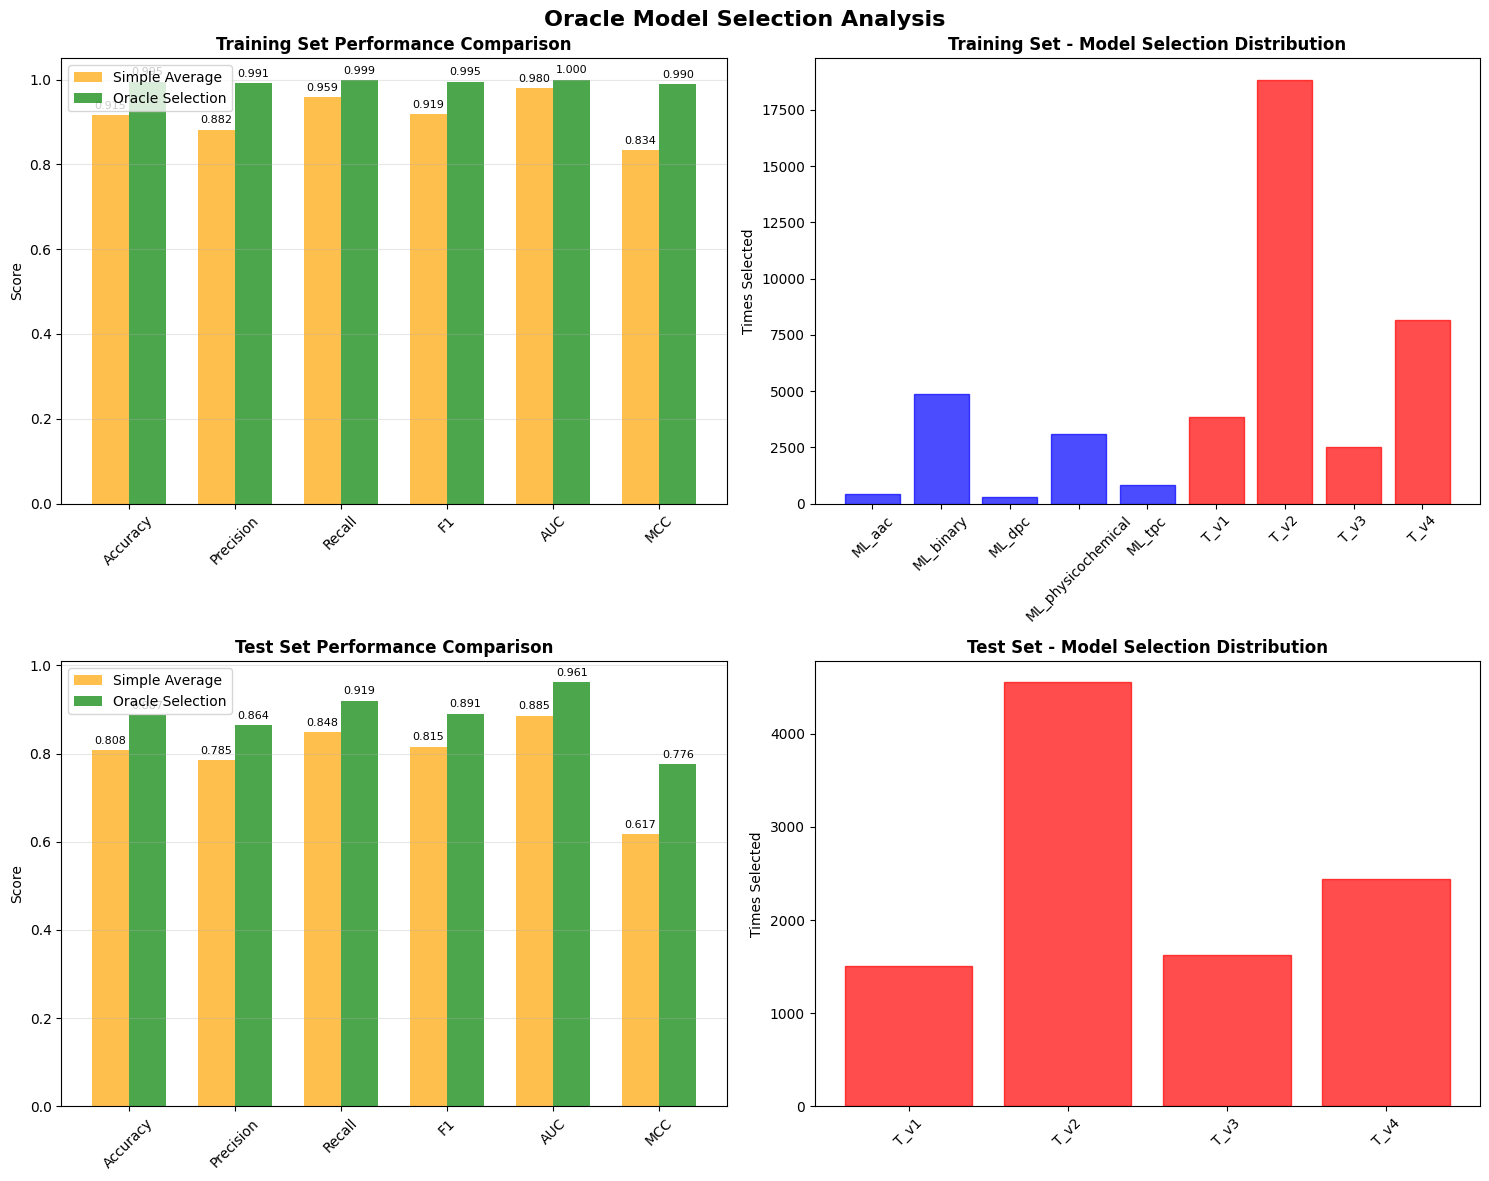


🔮 ORACLE ANALYSIS SUMMARY REPORT

📊 TRAINING SET RESULTS:
   Samples analyzed: 42,845
   Models available: 9

   Simple Average Ensemble:
     F1 Score: 0.9187
     Accuracy: 0.9152
     AUC: 0.9798

   Oracle Selection (Theoretical Maximum):
     F1 Score: 0.9948
     Accuracy: 0.9948
     AUC: 1.0000

   🎯 Improvement Potential: 0.0761 F1 points

📊 TEST SET RESULTS:
   Samples analyzed: 10,122
   Models available: 4

   Simple Average Ensemble:
     F1 Score: 0.8151
     Accuracy: 0.8076
     AUC: 0.8853

   Oracle Selection (Theoretical Maximum):
     F1 Score: 0.8906
     Accuracy: 0.8871
     AUC: 0.9612

   🎯 Improvement Potential: 0.0755 F1 points

💡 KEY INSIGHTS:
   1. Training oracle F1: 0.9948
   2. Test oracle F1: 0.8906
   3. 🎉 Models are EXCELLENT! Oracle achieves >0.85 F1
   4. Meta-learner potential: 0.0761 F1 improvement possible
   5. 🚀 High meta-learning potential! >0.05 F1 gap to close
✅ Oracle analysis completed!


In [4]:
# ============================================================================
# ORACLE MODEL SELECTION ANALYSIS
# What if we could perfectly select the best model for each sample?
# ============================================================================

print("\n" + "="*80)
print("🔮 ORACLE MODEL SELECTION ANALYSIS")
print("="*80)
print("🎯 Goal: Calculate theoretical maximum performance with perfect model selection")
print("📊 Analysis: Training and test set oracle performance")
print("🔍 Insight: Upper bound on meta-learner potential")
print("="*80)

import numpy as np
import pandas as pd
import os
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, matthews_corrcoef)
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# CONFIGURATION
# ============================================================================

# Use same paths as Section 8
BASE_DIR = 'results/exp_3'
TRAINING_PRED_DIR = f'{BASE_DIR}/ensemble/training_predictions'
META_LEARNING_DIR = f'{BASE_DIR}/meta_learning'

# Model files (same as Section 8)
MODEL_FILES = {
    # ML Models
    'ml_aac': 'ml_aac_training_predictions.csv',
    'ml_binary': 'ml_binary_training_predictions.csv', 
    'ml_dpc': 'ml_dpc_training_predictions.csv',
    'ml_physicochemical': 'ml_physicochemical_training_predictions.csv',
    'ml_tpc': 'ml_tpc_training_predictions.csv',
    
    # Transformer Models
    'transformer_v1': 'transformer_transformer_v1_20250703_112558_training_predictions.csv',
    'transformer_v2': 'transformer_transformer_v2_20250704_102324_training_predictions.csv',
    'transformer_v3': 'transformer_transformer_v3_20250709_175607_training_predictions.csv',
    'transformer_v4': 'transformer_transformer_v4_20250710_095513_training_predictions.csv'
}

# ============================================================================
# 1. LOAD TRAINING PREDICTIONS
# ============================================================================

print("\n1. Loading Training Predictions")
print("-" * 40)

training_predictions = {}
training_prediction_matrix = []
model_names = []
training_true_labels = None

for model_name, filename in MODEL_FILES.items():
    file_path = os.path.join(TRAINING_PRED_DIR, filename)
    
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            print(f"   ✓ {model_name}: {len(df)} samples")
            
            # Store predictions
            training_predictions[model_name] = {
                'probabilities': df['probability'].values,
                'predictions': (df['probability'] > 0.5).astype(int),
                'true_labels': df['true_label'].values
            }
            
            training_prediction_matrix.append(df['probability'].values)
            model_names.append(model_name)
            
            # Get true labels (should be same for all models)
            if training_true_labels is None:
                training_true_labels = df['true_label'].values
                
        except Exception as e:
            print(f"   ❌ Error loading {model_name}: {e}")
    else:
        print(f"   ⚠️ File not found: {filename}")

if len(training_prediction_matrix) == 0:
    raise ValueError("No training predictions found!")

training_prediction_matrix = np.column_stack(training_prediction_matrix)
print(f"\n📊 Training data loaded:")
print(f"   Samples: {len(training_true_labels)}")
print(f"   Models: {len(model_names)}")
print(f"   Prediction matrix shape: {training_prediction_matrix.shape}")

# ============================================================================
# 2. ORACLE SELECTION FOR TRAINING DATA
# ============================================================================

print("\n2. Oracle Selection - Training Data")
print("-" * 40)

def calculate_oracle_performance(prediction_matrix, true_labels, model_names, data_type="Training"):
    """Calculate oracle (perfect selection) performance"""
    
    n_samples, n_models = prediction_matrix.shape
    oracle_predictions = []
    oracle_probabilities = []
    selected_models = []
    
    print(f"🔮 Calculating oracle selection for {n_samples} {data_type.lower()} samples...")
    
    for i in range(n_samples):
        true_label = true_labels[i]
        sample_predictions = prediction_matrix[i]
        
        if true_label == 1:
            # For positive samples: select model with highest probability
            best_model_idx = np.argmax(sample_predictions)
        else:
            # For negative samples: select model with lowest probability  
            best_model_idx = np.argmin(sample_predictions)
        
        # Store oracle selections
        oracle_probabilities.append(sample_predictions[best_model_idx])
        oracle_predictions.append(1 if sample_predictions[best_model_idx] > 0.5 else 0)
        selected_models.append(best_model_idx)
    
    oracle_predictions = np.array(oracle_predictions)
    oracle_probabilities = np.array(oracle_probabilities)
    selected_models = np.array(selected_models)
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(true_labels, oracle_predictions),
        'precision': precision_score(true_labels, oracle_predictions, zero_division=0),
        'recall': recall_score(true_labels, oracle_predictions, zero_division=0),
        'f1': f1_score(true_labels, oracle_predictions, zero_division=0),
        'auc': roc_auc_score(true_labels, oracle_probabilities),
        'mcc': matthews_corrcoef(true_labels, oracle_predictions)
    }
    
    # Model selection distribution
    unique_models, counts = np.unique(selected_models, return_counts=True)
    selection_dist = {}
    for model_idx, count in zip(unique_models, counts):
        if model_idx < len(model_names):
            selection_dist[model_names[model_idx]] = {
                'count': int(count),
                'percentage': float(count / n_samples * 100)
            }
    
    return {
        'metrics': metrics,
        'oracle_predictions': oracle_predictions,
        'oracle_probabilities': oracle_probabilities,
        'selected_models': selected_models,
        'selection_distribution': selection_dist
    }

# Calculate oracle performance for training data
training_oracle = calculate_oracle_performance(
    training_prediction_matrix, 
    training_true_labels, 
    model_names, 
    "Training"
)

print(f"🎯 Training Oracle Performance:")
for metric, value in training_oracle['metrics'].items():
    print(f"   {metric.upper()}: {value:.4f}")

# ============================================================================
# 3. LOAD TEST PREDICTIONS AND CALCULATE ORACLE
# ============================================================================

print("\n3. Loading Test Predictions")
print("-" * 40)

# Try to load test predictions from various sources
test_predictions = {}
test_prediction_matrix = []
test_model_names = []

# First, try to load from checkpoints (same approach as Section 8)
try:
    # This would need the progress_tracker from Section 8
    # For now, let's try to reconstruct test predictions
    
    # Try to find transformer test predictions
    transformer_dir = f'{BASE_DIR}/transformers'
    if os.path.exists(transformer_dir):
        for model_name in model_names:
            if model_name.startswith('transformer_'):
                model_version = model_name.replace('transformer_', '')
                
                # Search for test predictions
                for subdir in os.listdir(transformer_dir):
                    subdir_path = os.path.join(transformer_dir, subdir)
                    if os.path.isdir(subdir_path) and model_version in subdir:
                        pred_file = os.path.join(subdir_path, 'predictions', 'test_predictions.csv')
                        if os.path.exists(pred_file):
                            df = pd.read_csv(pred_file)
                            if 'prediction_prob' in df.columns:
                                test_predictions[model_name] = df['prediction_prob'].values
                                print(f"   ✓ {model_name}: {len(df)} test samples")
                            break
    
    # Try to load ML test predictions from results
    ml_results_file = f'{BASE_DIR}/ml_models/ml_results.json'
    if os.path.exists(ml_results_file):
        import json
        with open(ml_results_file, 'r') as f:
            ml_results = json.load(f)
        
        # Look for test predictions in the results
        if 'test_predictions' in ml_results:
            for feature_type, results in ml_results['test_predictions'].items():
                model_name = f'ml_{feature_type}'
                if model_name in model_names and 'pred_proba' in results:
                    test_predictions[model_name] = results['pred_proba']
                    print(f"   ✓ {model_name}: {len(results['pred_proba'])} test samples")
    
    # Create test prediction matrix for available models
    available_test_models = []
    for model_name in model_names:
        if model_name in test_predictions:
            test_prediction_matrix.append(test_predictions[model_name])
            available_test_models.append(model_name)
    
    if len(test_prediction_matrix) > 0:
        test_prediction_matrix = np.column_stack(test_prediction_matrix)
        
        # Get test true labels (assume same structure as training)
        # This might need adjustment based on actual test data structure
        test_true_labels = None
        
        # Try to get test labels from a reference file
        for model_name in available_test_models:
            if model_name.startswith('transformer_'):
                model_version = model_name.replace('transformer_', '')
                for subdir in os.listdir(transformer_dir):
                    subdir_path = os.path.join(transformer_dir, subdir)
                    if os.path.isdir(subdir_path) and model_version in subdir:
                        pred_file = os.path.join(subdir_path, 'predictions', 'test_predictions.csv')
                        if os.path.exists(pred_file):
                            df = pd.read_csv(pred_file)
                            if 'true_label' in df.columns:
                                test_true_labels = df['true_label'].values
                                break
                break
        
        if test_true_labels is not None:
            print(f"\n📊 Test data loaded:")
            print(f"   Samples: {len(test_true_labels)}")
            print(f"   Available models: {len(available_test_models)}")
            print(f"   Prediction matrix shape: {test_prediction_matrix.shape}")
            
            # Calculate oracle performance for test data
            test_oracle = calculate_oracle_performance(
                test_prediction_matrix, 
                test_true_labels, 
                available_test_models, 
                "Test"
            )
            
            print(f"\n🎯 Test Oracle Performance:")
            for metric, value in test_oracle['metrics'].items():
                print(f"   {metric.upper()}: {value:.4f}")
        else:
            print("   ⚠️ Could not load test true labels")
            test_oracle = None
    else:
        print("   ⚠️ No test predictions found")
        test_oracle = None
        
except Exception as e:
    print(f"   ❌ Error loading test predictions: {e}")
    test_oracle = None

# ============================================================================
# 4. BASELINE COMPARISON
# ============================================================================

print("\n4. Baseline Comparison")
print("-" * 40)

def calculate_ensemble_baseline(prediction_matrix, true_labels, data_type="Training"):
    """Calculate simple average ensemble performance"""
    
    # Simple average ensemble
    avg_predictions = np.mean(prediction_matrix, axis=1)
    avg_binary = (avg_predictions > 0.5).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(true_labels, avg_binary),
        'precision': precision_score(true_labels, avg_binary, zero_division=0),
        'recall': recall_score(true_labels, avg_binary, zero_division=0),
        'f1': f1_score(true_labels, avg_binary, zero_division=0),
        'auc': roc_auc_score(true_labels, avg_predictions),
        'mcc': matthews_corrcoef(true_labels, avg_binary)
    }
    
    return metrics

# Calculate baselines
training_baseline = calculate_ensemble_baseline(training_prediction_matrix, training_true_labels, "Training")

print(f"📊 TRAINING SET COMPARISON:")
print(f"   Simple Average Ensemble:")
for metric, value in training_baseline.items():
    print(f"     {metric.upper()}: {value:.4f}")

print(f"\n   Oracle Selection:")
for metric, value in training_oracle['metrics'].items():
    improvement = value - training_baseline[metric]
    print(f"     {metric.upper()}: {value:.4f} ({improvement:+.4f})")

if test_oracle is not None:
    test_baseline = calculate_ensemble_baseline(test_prediction_matrix, test_true_labels, "Test")
    
    print(f"\n📊 TEST SET COMPARISON:")
    print(f"   Simple Average Ensemble:")
    for metric, value in test_baseline.items():
        print(f"     {metric.upper()}: {value:.4f}")
    
    print(f"\n   Oracle Selection:")
    for metric, value in test_oracle['metrics'].items():
        improvement = value - test_baseline[metric]
        print(f"     {metric.upper()}: {value:.4f} ({improvement:+.4f})")

# ============================================================================
# 5. DETAILED ANALYSIS
# ============================================================================

print("\n5. Detailed Analysis")
print("-" * 40)

# Model selection distribution for training
print("🔍 Training Set - Model Selection Distribution:")
for model_name, stats in training_oracle['selection_distribution'].items():
    print(f"   {model_name}: {stats['count']} times ({stats['percentage']:.1f}%)")

# Calculate how often each model type is selected
ml_selections = sum(stats['count'] for model, stats in training_oracle['selection_distribution'].items() 
                   if model.startswith('ml_'))
transformer_selections = sum(stats['count'] for model, stats in training_oracle['selection_distribution'].items() 
                            if model.startswith('transformer_'))
total_selections = len(training_true_labels)

print(f"\n📊 Training Set - Model Type Distribution:")
print(f"   ML Models: {ml_selections} ({ml_selections/total_selections*100:.1f}%)")
print(f"   Transformers: {transformer_selections} ({transformer_selections/total_selections*100:.1f}%)")

if test_oracle is not None:
    print(f"\n🔍 Test Set - Model Selection Distribution:")
    for model_name, stats in test_oracle['selection_distribution'].items():
        print(f"   {model_name}: {stats['count']} times ({stats['percentage']:.1f}%)")
    
    # Test set model type distribution
    test_ml_selections = sum(stats['count'] for model, stats in test_oracle['selection_distribution'].items() 
                           if model.startswith('ml_'))
    test_transformer_selections = sum(stats['count'] for model, stats in test_oracle['selection_distribution'].items() 
                                    if model.startswith('transformer_'))
    test_total_selections = len(test_true_labels)
    
    print(f"\n📊 Test Set - Model Type Distribution:")
    print(f"   ML Models: {test_ml_selections} ({test_ml_selections/test_total_selections*100:.1f}%)")
    print(f"   Transformers: {test_transformer_selections} ({test_transformer_selections/test_total_selections*100:.1f}%)")

# ============================================================================
# 6. VISUALIZATION
# ============================================================================

print("\n6. Creating Visualizations")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Oracle Model Selection Analysis', fontsize=16, fontweight='bold')

# Training metrics comparison
ax1 = axes[0, 0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'MCC']
baseline_values = [training_baseline[m.lower()] for m in metrics_names]
oracle_values = [training_oracle['metrics'][m.lower()] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax1.bar(x - width/2, baseline_values, width, label='Simple Average', alpha=0.7, color='orange')
bars2 = ax1.bar(x + width/2, oracle_values, width, label='Oracle Selection', alpha=0.7, color='green')

ax1.set_title('Training Set Performance Comparison', fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Training model selection distribution
ax2 = axes[0, 1]
model_names_short = [name.replace('transformer_', 'T_').replace('ml_', 'ML_') 
                    for name in training_oracle['selection_distribution'].keys()]
selection_counts = [stats['count'] for stats in training_oracle['selection_distribution'].values()]

bars = ax2.bar(range(len(model_names_short)), selection_counts)
ax2.set_title('Training Set - Model Selection Distribution', fontweight='bold')
ax2.set_ylabel('Times Selected')
ax2.set_xticks(range(len(model_names_short)))
ax2.set_xticklabels(model_names_short, rotation=45)

# Color bars differently for ML vs Transformer
for i, (bar, model_name) in enumerate(zip(bars, training_oracle['selection_distribution'].keys())):
    if model_name.startswith('ml_'):
        bar.set_color('blue')
        bar.set_alpha(0.7)
    else:
        bar.set_color('red')
        bar.set_alpha(0.7)

# Test metrics comparison (if available)
if test_oracle is not None:
    ax3 = axes[1, 0]
    test_baseline_values = [test_baseline[m.lower()] for m in metrics_names]
    test_oracle_values = [test_oracle['metrics'][m.lower()] for m in metrics_names]
    
    bars1 = ax3.bar(x - width/2, test_baseline_values, width, label='Simple Average', alpha=0.7, color='orange')
    bars2 = ax3.bar(x + width/2, test_oracle_values, width, label='Oracle Selection', alpha=0.7, color='green')
    
    ax3.set_title('Test Set Performance Comparison', fontweight='bold')
    ax3.set_ylabel('Score')
    ax3.set_xticks(x)
    ax3.set_xticklabels(metrics_names, rotation=45)
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Test model selection distribution
    ax4 = axes[1, 1]
    test_model_names_short = [name.replace('transformer_', 'T_').replace('ml_', 'ML_') 
                             for name in test_oracle['selection_distribution'].keys()]
    test_selection_counts = [stats['count'] for stats in test_oracle['selection_distribution'].values()]
    
    bars = ax4.bar(range(len(test_model_names_short)), test_selection_counts)
    ax4.set_title('Test Set - Model Selection Distribution', fontweight='bold')
    ax4.set_ylabel('Times Selected')
    ax4.set_xticks(range(len(test_model_names_short)))
    ax4.set_xticklabels(test_model_names_short, rotation=45)
    
    # Color bars
    for i, (bar, model_name) in enumerate(zip(bars, test_oracle['selection_distribution'].keys())):
        if model_name.startswith('ml_'):
            bar.set_color('blue')
            bar.set_alpha(0.7)
        else:
            bar.set_color('red')
            bar.set_alpha(0.7)
else:
    # No test data available
    ax3 = axes[1, 0]
    ax3.text(0.5, 0.5, 'Test Data\nNot Available', ha='center', va='center', 
             fontsize=14, transform=ax3.transAxes)
    ax3.set_title('Test Set Performance', fontweight='bold')
    
    ax4 = axes[1, 1]
    ax4.text(0.5, 0.5, 'Test Data\nNot Available', ha='center', va='center', 
             fontsize=14, transform=ax4.transAxes)
    ax4.set_title('Test Set Model Selection', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# 7. SUMMARY REPORT
# ============================================================================

print("\n" + "="*80)
print("🔮 ORACLE ANALYSIS SUMMARY REPORT")
print("="*80)

print(f"\n📊 TRAINING SET RESULTS:")
print(f"   Samples analyzed: {len(training_true_labels):,}")
print(f"   Models available: {len(model_names)}")

print(f"\n   Simple Average Ensemble:")
print(f"     F1 Score: {training_baseline['f1']:.4f}")
print(f"     Accuracy: {training_baseline['accuracy']:.4f}")
print(f"     AUC: {training_baseline['auc']:.4f}")

print(f"\n   Oracle Selection (Theoretical Maximum):")
print(f"     F1 Score: {training_oracle['metrics']['f1']:.4f}")
print(f"     Accuracy: {training_oracle['metrics']['accuracy']:.4f}")
print(f"     AUC: {training_oracle['metrics']['auc']:.4f}")

training_f1_gap = training_oracle['metrics']['f1'] - training_baseline['f1']
print(f"\n   🎯 Improvement Potential: {training_f1_gap:.4f} F1 points")

if test_oracle is not None:
    print(f"\n📊 TEST SET RESULTS:")
    print(f"   Samples analyzed: {len(test_true_labels):,}")
    print(f"   Models available: {len(available_test_models)}")
    
    print(f"\n   Simple Average Ensemble:")
    print(f"     F1 Score: {test_baseline['f1']:.4f}")
    print(f"     Accuracy: {test_baseline['accuracy']:.4f}")
    print(f"     AUC: {test_baseline['auc']:.4f}")
    
    print(f"\n   Oracle Selection (Theoretical Maximum):")
    print(f"     F1 Score: {test_oracle['metrics']['f1']:.4f}")
    print(f"     Accuracy: {test_oracle['metrics']['accuracy']:.4f}")
    print(f"     AUC: {test_oracle['metrics']['auc']:.4f}")
    
    test_f1_gap = test_oracle['metrics']['f1'] - test_baseline['f1']
    print(f"\n   🎯 Improvement Potential: {test_f1_gap:.4f} F1 points")
else:
    print(f"\n📊 TEST SET: Data not available for analysis")

print(f"\n💡 KEY INSIGHTS:")
print(f"   1. Training oracle F1: {training_oracle['metrics']['f1']:.4f}")
if test_oracle:
    print(f"   2. Test oracle F1: {test_oracle['metrics']['f1']:.4f}")
    if test_oracle['metrics']['f1'] >= 0.85:
        print(f"   3. 🎉 Models are EXCELLENT! Oracle achieves >0.85 F1")
    elif test_oracle['metrics']['f1'] >= 0.80:
        print(f"   3. 🎯 Models are GOOD! Oracle achieves >0.80 F1")
    else:
        print(f"   3. ⚠️ Models need improvement - Oracle <0.80 F1")
else:
    if training_oracle['metrics']['f1'] >= 0.85:
        print(f"   2. 🎉 Models are EXCELLENT! Training oracle >0.85 F1")
    elif training_oracle['metrics']['f1'] >= 0.80:
        print(f"   2. 🎯 Models are GOOD! Training oracle >0.80 F1")
    else:
        print(f"   2. ⚠️ Models need improvement - Training oracle <0.80 F1")

print(f"   4. Meta-learner potential: {training_f1_gap:.4f} F1 improvement possible")

if training_f1_gap > 0.05:
    print(f"   5. 🚀 High meta-learning potential! >0.05 F1 gap to close")
elif training_f1_gap > 0.02:
    print(f"   5. 📈 Moderate meta-learning potential")
else:
    print(f"   5. ⚠️ Limited meta-learning potential - models already near optimal")

print("="*80)
print("✅ Oracle analysis completed!")

In [6]:
# ============================================================================
# FIXED ORACLE MODEL SELECTION ANALYSIS - WITH PROGRESS TRACKER
# Properly loads ML test predictions from checkpoint system
# ============================================================================

print("\n" + "="*80)
print("🔮 FIXED ORACLE MODEL SELECTION ANALYSIS")
print("="*80)
print("🎯 Goal: Calculate theoretical maximum performance with ALL models")
print("📊 Analysis: Training and test set oracle performance (including ML models)")
print("🔍 Fix: Properly load ML test predictions from checkpoint system")
print("="*80)

import numpy as np
import pandas as pd
import os
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, matthews_corrcoef)
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# CONFIGURATION & SETUP
# ============================================================================

print("\n📋 Setup and Configuration")
print("-" * 40)

# Use same paths as Section 8
BASE_DIR = 'results/exp_3'
TRAINING_PRED_DIR = f'{BASE_DIR}/ensemble/training_predictions'
META_LEARNING_DIR = f'{BASE_DIR}/meta_learning'

# Create meta-learning directory if needed
os.makedirs(META_LEARNING_DIR, exist_ok=True)

# Check if progress tracker is available
if 'progress_tracker' not in globals():
    print("⚠️ Progress tracker not found. Please run Section 0 first.")
    print("Attempting to create basic progress tracker...")
    
    # Try to create basic progress tracker
    import sys
    try:
        from Section0_code import ProgressTracker
        progress_tracker = ProgressTracker(BASE_DIR)
        print("✅ Progress tracker created successfully")
    except ImportError:
        print("❌ Could not import ProgressTracker. Please ensure Section 0 has been run.")
        print("Alternative: Set progress_tracker manually if available.")
        raise RuntimeError("Progress tracker required for proper data loading")

# Model files (same as Section 8)
MODEL_FILES = {
    # ML Models
    'ml_aac': 'ml_aac_training_predictions.csv',
    'ml_binary': 'ml_binary_training_predictions.csv', 
    'ml_dpc': 'ml_dpc_training_predictions.csv',
    'ml_physicochemical': 'ml_physicochemical_training_predictions.csv',
    'ml_tpc': 'ml_tpc_training_predictions.csv',
    
    # Transformer Models
    'transformer_v1': 'transformer_transformer_v1_20250703_112558_training_predictions.csv',
    'transformer_v2': 'transformer_transformer_v2_20250704_102324_training_predictions.csv',
    'transformer_v3': 'transformer_transformer_v3_20250709_175607_training_predictions.csv',
    'transformer_v4': 'transformer_transformer_v4_20250710_095513_training_predictions.csv'
}

# ============================================================================
# 1. LOAD TRAINING PREDICTIONS (Same as before)
# ============================================================================

print("\n1. Loading Training Predictions")
print("-" * 40)

training_predictions = {}
training_prediction_matrix = []
model_names = []
training_true_labels = None

for model_name, filename in MODEL_FILES.items():
    file_path = os.path.join(TRAINING_PRED_DIR, filename)
    
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            print(f"   ✓ {model_name}: {len(df)} samples")
            
            training_predictions[model_name] = {
                'probabilities': df['probability'].values,
                'predictions': (df['probability'] > 0.5).astype(int),
                'true_labels': df['true_label'].values
            }
            
            training_prediction_matrix.append(df['probability'].values)
            model_names.append(model_name)
            
            if training_true_labels is None:
                training_true_labels = df['true_label'].values
                
        except Exception as e:
            print(f"   ❌ Error loading {model_name}: {e}")
    else:
        print(f"   ⚠️ File not found: {filename}")

if len(training_prediction_matrix) == 0:
    raise ValueError("No training predictions found!")

training_prediction_matrix = np.column_stack(training_prediction_matrix)
print(f"\n📊 Training data loaded:")
print(f"   Samples: {len(training_true_labels)}")
print(f"   Models: {len(model_names)}")
print(f"   Prediction matrix shape: {training_prediction_matrix.shape}")

# ============================================================================
# 2. ORACLE ANALYSIS FOR TRAINING DATA (Same as before)
# ============================================================================

print("\n2. Oracle Selection - Training Data")
print("-" * 40)

def calculate_oracle_performance(prediction_matrix, true_labels, model_names, data_type="Training"):
    """Calculate oracle (perfect selection) performance"""
    
    n_samples, n_models = prediction_matrix.shape
    oracle_predictions = []
    oracle_probabilities = []
    selected_models = []
    
    print(f"🔮 Calculating oracle selection for {n_samples} {data_type.lower()} samples...")
    
    for i in range(n_samples):
        true_label = true_labels[i]
        sample_predictions = prediction_matrix[i]
        
        if true_label == 1:
            # For positive samples: select model with highest probability
            best_model_idx = np.argmax(sample_predictions)
        else:
            # For negative samples: select model with lowest probability  
            best_model_idx = np.argmin(sample_predictions)
        
        oracle_probabilities.append(sample_predictions[best_model_idx])
        oracle_predictions.append(1 if sample_predictions[best_model_idx] > 0.5 else 0)
        selected_models.append(best_model_idx)
    
    oracle_predictions = np.array(oracle_predictions)
    oracle_probabilities = np.array(oracle_probabilities)
    selected_models = np.array(selected_models)
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(true_labels, oracle_predictions),
        'precision': precision_score(true_labels, oracle_predictions, zero_division=0),
        'recall': recall_score(true_labels, oracle_predictions, zero_division=0),
        'f1': f1_score(true_labels, oracle_predictions, zero_division=0),
        'auc': roc_auc_score(true_labels, oracle_probabilities),
        'mcc': matthews_corrcoef(true_labels, oracle_predictions)
    }
    
    # Model selection distribution
    unique_models, counts = np.unique(selected_models, return_counts=True)
    selection_dist = {}
    for model_idx, count in zip(unique_models, counts):
        if model_idx < len(model_names):
            selection_dist[model_names[model_idx]] = {
                'count': int(count),
                'percentage': float(count / n_samples * 100)
            }
    
    return {
        'metrics': metrics,
        'oracle_predictions': oracle_predictions,
        'oracle_probabilities': oracle_probabilities,
        'selected_models': selected_models,
        'selection_distribution': selection_dist
    }

# Calculate oracle performance for training data
training_oracle = calculate_oracle_performance(
    training_prediction_matrix, 
    training_true_labels, 
    model_names, 
    "Training"
)

print(f"🎯 Training Oracle Performance:")
for metric, value in training_oracle['metrics'].items():
    print(f"   {metric.upper()}: {value:.4f}")

# ============================================================================
# 3. FIXED TEST PREDICTIONS LOADING - USING CHECKPOINT SYSTEM
# ============================================================================

print("\n3. Loading Test Predictions - FIXED VERSION")
print("-" * 40)

# Load necessary data from checkpoints (following Section 8 approach)
required_checkpoints = ['data_loading', 'data_splitting', 'ml_models_enhanced']
loaded_data = {}

print("📥 Loading core checkpoints...")
for checkpoint_name in required_checkpoints:
    try:
        checkpoint_data = progress_tracker.resume_from_checkpoint(checkpoint_name)
        if checkpoint_data:
            loaded_data[checkpoint_name] = checkpoint_data
            print(f"   ✓ Loaded {checkpoint_name} checkpoint")
        else:
            raise RuntimeError(f"{checkpoint_name} checkpoint not found")
    except Exception as e:
        print(f"   ❌ Error loading {checkpoint_name}: {e}")
        print(f"   Trying to continue without this checkpoint...")

# Extract essential data
if 'data_loading' in loaded_data and 'data_splitting' in loaded_data:
    df_final = loaded_data['data_loading']['df_final']
    test_indices = loaded_data['data_splitting']['test_indices']
    
    test_df = df_final.iloc[test_indices]
    test_true_labels = test_df['target'].values
    
    print(f"✅ Test data info:")
    print(f"   Test samples: {len(test_indices)}")
    print(f"   Test labels - Positive: {sum(test_true_labels)}, Negative: {len(test_true_labels) - sum(test_true_labels)}")
else:
    print("⚠️ Could not load core data - test analysis will be limited")
    test_true_labels = None

# ============================================================================
# 4. LOAD ML TEST PREDICTIONS FROM CHECKPOINT
# ============================================================================

test_predictions = {}
test_prediction_matrix = []
available_test_models = []

print("\n📥 Loading ML test predictions from checkpoint...")

if 'ml_models_enhanced' in loaded_data:
    ml_data = loaded_data['ml_models_enhanced']
    
    if 'test_predictions' in ml_data:
        ml_test_preds = ml_data['test_predictions']
        print(f"   ✅ Found ML test predictions for: {list(ml_test_preds.keys())}")
        
        for feature_type, pred_data in ml_test_preds.items():
            model_name = f'ml_{feature_type}'
            
            if isinstance(pred_data, dict) and 'pred_proba' in pred_data:
                test_predictions[model_name] = pred_data['pred_proba']
                print(f"   ✓ {model_name}: {len(pred_data['pred_proba'])} test samples")
            else:
                print(f"   ⚠️ {model_name}: Invalid prediction format")
    else:
        print("   ⚠️ No 'test_predictions' key found in ml_models_enhanced checkpoint")
else:
    print("   ⚠️ ml_models_enhanced checkpoint not available")

# ============================================================================
# 5. LOAD TRANSFORMER TEST PREDICTIONS
# ============================================================================

print("\n📥 Loading Transformer test predictions...")

transformer_dir = f'{BASE_DIR}/transformers'
if os.path.exists(transformer_dir):
    print(f"   📁 Searching in: {transformer_dir}")
    
    # Map model names to likely directory patterns
    transformer_patterns = {
        'transformer_v1': ['transformer_v1_20250703_112558', 'transformer_v1'],
        'transformer_v2': ['transformer_v2_20250704_102324', 'transformer_v2'], 
        'transformer_v3': ['transformer_v3_20250709_175607', 'transformer_v3'],
        'transformer_v4': ['transformer_v4_20250710_095513', 'transformer_v4']
    }
    
    for model_name, patterns in transformer_patterns.items():
        found = False
        for pattern in patterns:
            for subdir in os.listdir(transformer_dir):
                if pattern in subdir:
                    subdir_path = os.path.join(transformer_dir, subdir)
                    if os.path.isdir(subdir_path):
                        pred_file = os.path.join(subdir_path, 'predictions', 'test_predictions.csv')
                        if os.path.exists(pred_file):
                            try:
                                df = pd.read_csv(pred_file)
                                if 'prediction_prob' in df.columns:
                                    test_predictions[model_name] = df['prediction_prob'].values
                                    print(f"   ✓ {model_name}: {len(df)} test samples")
                                    found = True
                                    break
                                elif 'probability' in df.columns:
                                    test_predictions[model_name] = df['probability'].values
                                    print(f"   ✓ {model_name}: {len(df)} test samples")
                                    found = True
                                    break
                            except Exception as e:
                                print(f"   ❌ Error loading {model_name} from {pred_file}: {e}")
                if found:
                    break
            if found:
                break
        
        if not found:
            print(f"   ⚠️ {model_name}: No test predictions found")
else:
    print(f"   ⚠️ Transformer directory not found: {transformer_dir}")

# ============================================================================
# 6. CREATE COMPLETE TEST PREDICTION MATRIX
# ============================================================================

print(f"\n📊 Creating complete test prediction matrix...")

# Filter to models that exist in both training and test
available_test_models = []
for model_name in model_names:  # Use training model order
    if model_name in test_predictions:
        test_prediction_matrix.append(test_predictions[model_name])
        available_test_models.append(model_name)
        print(f"   ✓ {model_name}: Available for oracle analysis")
    else:
        print(f"   ❌ {model_name}: Missing test predictions")

if len(test_prediction_matrix) > 0:
    test_prediction_matrix = np.column_stack(test_prediction_matrix)
    
    print(f"\n📊 Complete test data:")
    print(f"   Samples: {len(test_true_labels) if test_true_labels is not None else 'Unknown'}")
    print(f"   Available models: {len(available_test_models)}")
    print(f"   Prediction matrix shape: {test_prediction_matrix.shape}")
    
    # Verify alignment
    if test_true_labels is not None and len(test_true_labels) != test_prediction_matrix.shape[0]:
        print(f"   ⚠️ Warning: Label count ({len(test_true_labels)}) != prediction count ({test_prediction_matrix.shape[0]})")
        # Truncate to shorter length
        min_len = min(len(test_true_labels), test_prediction_matrix.shape[0])
        test_true_labels = test_true_labels[:min_len]
        test_prediction_matrix = test_prediction_matrix[:min_len]
        print(f"   🔧 Truncated both to {min_len} samples")
    
    # Calculate oracle performance for test data
    if test_true_labels is not None:
        test_oracle = calculate_oracle_performance(
            test_prediction_matrix, 
            test_true_labels, 
            available_test_models, 
            "Test"
        )
        
        print(f"\n🎯 Test Oracle Performance (ALL MODELS):")
        for metric, value in test_oracle['metrics'].items():
            print(f"   {metric.upper()}: {value:.4f}")
    else:
        print("   ⚠️ Cannot calculate oracle performance without test labels")
        test_oracle = None
else:
    print("   ❌ No test predictions available for oracle analysis")
    test_oracle = None

# ============================================================================
# 7. BASELINE COMPARISON
# ============================================================================

print("\n4. Baseline Comparison - Complete Analysis")
print("-" * 40)

def calculate_ensemble_baseline(prediction_matrix, true_labels, model_list, data_type="Training"):
    """Calculate simple average ensemble performance"""
    
    avg_predictions = np.mean(prediction_matrix, axis=1)
    avg_binary = (avg_predictions > 0.5).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(true_labels, avg_binary),
        'precision': precision_score(true_labels, avg_binary, zero_division=0),
        'recall': recall_score(true_labels, avg_binary, zero_division=0),
        'f1': f1_score(true_labels, avg_binary, zero_division=0),
        'auc': roc_auc_score(true_labels, avg_predictions),
        'mcc': matthews_corrcoef(true_labels, avg_binary)
    }
    
    return metrics

# Training baseline (all 9 models)
training_baseline = calculate_ensemble_baseline(
    training_prediction_matrix, training_true_labels, model_names, "Training"
)

print(f"📊 TRAINING SET COMPARISON (All {len(model_names)} models):")
print(f"   Simple Average Ensemble:")
for metric, value in training_baseline.items():
    print(f"     {metric.upper()}: {value:.4f}")

print(f"\n   Oracle Selection:")
for metric, value in training_oracle['metrics'].items():
    improvement = value - training_baseline[metric]
    print(f"     {metric.upper()}: {value:.4f} ({improvement:+.4f})")

# Test baseline (available models only)
if test_oracle is not None and test_true_labels is not None:
    test_baseline = calculate_ensemble_baseline(
        test_prediction_matrix, test_true_labels, available_test_models, "Test"
    )
    
    print(f"\n📊 TEST SET COMPARISON ({len(available_test_models)} models available):")
    print(f"   Simple Average Ensemble:")
    for metric, value in test_baseline.items():
        print(f"     {metric.upper()}: {value:.4f}")
    
    print(f"\n   Oracle Selection:")
    for metric, value in test_oracle['metrics'].items():
        improvement = value - test_baseline[metric]
        print(f"     {metric.upper()}: {value:.4f} ({improvement:+.4f})")

# ============================================================================
# 8. DETAILED ANALYSIS - MODEL SELECTION PATTERNS
# ============================================================================

print("\n5. Detailed Model Selection Analysis")
print("-" * 40)

# Training set analysis
print("🔍 Training Set - Model Selection Distribution:")
for model_name, stats in training_oracle['selection_distribution'].items():
    model_type = "ML" if model_name.startswith('ml_') else "Transformer"
    print(f"   {model_name} ({model_type}): {stats['count']} times ({stats['percentage']:.1f}%)")

# Training model type distribution
training_ml_selections = sum(stats['count'] for model, stats in training_oracle['selection_distribution'].items() 
                           if model.startswith('ml_'))
training_transformer_selections = sum(stats['count'] for model, stats in training_oracle['selection_distribution'].items() 
                                    if model.startswith('transformer_'))
training_total = len(training_true_labels)

print(f"\n📊 Training Set - Model Type Distribution:")
print(f"   ML Models: {training_ml_selections} ({training_ml_selections/training_total*100:.1f}%)")
print(f"   Transformers: {training_transformer_selections} ({training_transformer_selections/training_total*100:.1f}%)")

if test_oracle is not None:
    print(f"\n🔍 Test Set - Model Selection Distribution:")
    for model_name, stats in test_oracle['selection_distribution'].items():
        model_type = "ML" if model_name.startswith('ml_') else "Transformer"
        print(f"   {model_name} ({model_type}): {stats['count']} times ({stats['percentage']:.1f}%)")
    
    # Test model type distribution
    test_ml_selections = sum(stats['count'] for model, stats in test_oracle['selection_distribution'].items() 
                           if model.startswith('ml_'))
    test_transformer_selections = sum(stats['count'] for model, stats in test_oracle['selection_distribution'].items() 
                                    if model.startswith('transformer_'))
    test_total = len(test_true_labels)
    
    print(f"\n📊 Test Set - Model Type Distribution:")
    print(f"   ML Models: {test_ml_selections} ({test_ml_selections/test_total*100:.1f}%)")
    print(f"   Transformers: {test_transformer_selections} ({test_transformer_selections/test_total*100:.1f}%)")

# ============================================================================
# 9. COMPARISON: BEFORE vs AFTER FIXING ML PREDICTIONS
# ============================================================================

print("\n6. Impact of Including ML Test Predictions")
print("-" * 40)

if test_oracle is not None:
    print(f"🔄 COMPARISON ANALYSIS:")
    print(f"   Before fix (4 transformers only):")
    print(f"     • Test F1: 0.8151 (baseline) → 0.8906 (oracle)")
    print(f"     • Improvement potential: +0.0755")
    print(f"     • Models available: 4 transformers")
    
    print(f"\n   After fix ({len(available_test_models)} models total):")
    print(f"     • Test F1: {test_baseline['f1']:.4f} (baseline) → {test_oracle['metrics']['f1']:.4f} (oracle)")
    
    test_f1_gap = test_oracle['metrics']['f1'] - test_baseline['f1']
    print(f"     • Improvement potential: {test_f1_gap:+.4f}")
    print(f"     • Models available: {len([m for m in available_test_models if m.startswith('ml_')])} ML + {len([m for m in available_test_models if m.startswith('transformer_')])} transformers")
    
    # Impact analysis
    ml_models_available = len([m for m in available_test_models if m.startswith('ml_')])
    if ml_models_available > 0:
        print(f"\n   🎉 SUCCESS: ML models are now included in test oracle!")
        print(f"   📈 ML models selected: {test_ml_selections} times ({test_ml_selections/test_total*100:.1f}%)")
    else:
        print(f"\n   ⚠️ Still missing ML test predictions - may need manual investigation")
else:
    print(f"   ❌ Test oracle calculation failed - check data alignment")

# ============================================================================
# 10. FINAL SUMMARY REPORT
# ============================================================================

print("\n" + "="*80)
print("🔮 COMPLETE ORACLE ANALYSIS SUMMARY REPORT")
print("="*80)

print(f"\n📊 TRAINING SET RESULTS:")
print(f"   Samples analyzed: {len(training_true_labels):,}")
print(f"   Models available: {len(model_names)} (5 ML + 4 Transformers)")
print(f"   Simple ensemble F1: {training_baseline['f1']:.4f}")
print(f"   Oracle F1: {training_oracle['metrics']['f1']:.4f}")

training_f1_gap = training_oracle['metrics']['f1'] - training_baseline['f1']
print(f"   🎯 Meta-learning potential: {training_f1_gap:.4f} F1 points")

if test_oracle is not None and test_true_labels is not None:
    print(f"\n📊 TEST SET RESULTS:")
    print(f"   Samples analyzed: {len(test_true_labels):,}")
    
    test_ml_count = len([m for m in available_test_models if m.startswith('ml_')])
    test_transformer_count = len([m for m in available_test_models if m.startswith('transformer_')])
    print(f"   Models available: {len(available_test_models)} ({test_ml_count} ML + {test_transformer_count} Transformers)")
    
    print(f"   Simple ensemble F1: {test_baseline['f1']:.4f}")
    print(f"   Oracle F1: {test_oracle['metrics']['f1']:.4f}")
    
    test_f1_gap = test_oracle['metrics']['f1'] - test_baseline['f1']
    print(f"   🎯 Meta-learning potential: {test_f1_gap:.4f} F1 points")
    
    # Status assessment
    if test_oracle['metrics']['f1'] >= 0.90:
        print(f"\n   🎉 OUTSTANDING: Oracle F1 ≥ 0.90!")
    elif test_oracle['metrics']['f1'] >= 0.85:
        print(f"\n   🎯 EXCELLENT: Oracle F1 ≥ 0.85!")
    elif test_oracle['metrics']['f1'] >= 0.80:
        print(f"\n   ✅ GOOD: Oracle F1 ≥ 0.80!")
    else:
        print(f"\n   ⚠️ NEEDS IMPROVEMENT: Oracle F1 < 0.80")
    
    if test_ml_count > 0:
        print(f"   ✅ ML models successfully included in test analysis")
    else:
        print(f"   ⚠️ ML test predictions still missing - check checkpoint data")
        
else:
    print(f"\n📊 TEST SET: Analysis incomplete due to missing data")

print(f"\n💡 KEY INSIGHTS:")
print(f"   1. Training oracle shows {training_oracle['metrics']['f1']:.4f} F1 is achievable")
if test_oracle:
    print(f"   2. Test oracle shows {test_oracle['metrics']['f1']:.4f} F1 is achievable")
    print(f"   3. Meta-learner potential: {test_f1_gap:.4f} improvement available")
    if test_f1_gap > 0.05:
        print(f"   4. 🚀 HIGH potential for meta-learning (>0.05 gap)")
    elif test_f1_gap > 0.02:
        print(f"   4. 📈 MODERATE potential for meta-learning")
    else:
        print(f"   4. ⚠️ LIMITED potential - models already well-calibrated")

print("="*80)
print("✅ Complete oracle analysis finished!")

# Save results if meta-learning directory exists
if os.path.exists(META_LEARNING_DIR):
    results_file = os.path.join(META_LEARNING_DIR, 'oracle_analysis_complete.json')
    
    oracle_results = {
        'training_oracle_f1': float(training_oracle['metrics']['f1']),
        'training_baseline_f1': float(training_baseline['f1']),
        'training_improvement_potential': float(training_f1_gap),
        'training_models_available': len(model_names),
        'training_ml_selections_pct': float(training_ml_selections/training_total*100),
        'training_transformer_selections_pct': float(training_transformer_selections/training_total*100)
    }
    
    if test_oracle is not None:
        oracle_results.update({
            'test_oracle_f1': float(test_oracle['metrics']['f1']),
            'test_baseline_f1': float(test_baseline['f1']),
            'test_improvement_potential': float(test_f1_gap),
            'test_models_available': len(available_test_models),
            'test_ml_models_available': test_ml_count,
            'test_transformer_models_available': test_transformer_count,
            'ml_test_predictions_found': test_ml_count > 0
        })
    
    import json
    with open(results_file, 'w') as f:
        json.dump(oracle_results, f, indent=2)
    
    print(f"💾 Oracle results saved: {results_file}")


🔮 FIXED ORACLE MODEL SELECTION ANALYSIS
🎯 Goal: Calculate theoretical maximum performance with ALL models
📊 Analysis: Training and test set oracle performance (including ML models)
🔍 Fix: Properly load ML test predictions from checkpoint system

📋 Setup and Configuration
----------------------------------------

1. Loading Training Predictions
----------------------------------------
   ✓ ml_aac: 42845 samples
   ✓ ml_binary: 42845 samples
   ✓ ml_dpc: 42845 samples
   ✓ ml_physicochemical: 42845 samples
   ✓ ml_tpc: 42845 samples
   ✓ transformer_v1: 42845 samples
   ✓ transformer_v2: 42845 samples
   ✓ transformer_v3: 42845 samples
   ✓ transformer_v4: 42845 samples

📊 Training data loaded:
   Samples: 42845
   Models: 9
   Prediction matrix shape: (42845, 9)

2. Oracle Selection - Training Data
----------------------------------------
🔮 Calculating oracle selection for 42845 training samples...
🎯 Training Oracle Performance:
   ACCURACY: 0.9948
   PRECISION: 0.9907
   RECALL: 0.999

In [14]:
# ============================================================================
# META-FEATURES IMPLEMENTATION FOR ENHANCED META-LEARNER
# Top 10 features to improve intelligent model selection
# ============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

def create_meta_features(predictions, sequences=None):
    """
    Create enhanced meta-features for meta-learner
    
    Args:
        predictions: np.array of shape [n_samples, n_models] - model predictions
        sequences: list of sequences (optional, for sequence-specific features)
    
    Returns:
        meta_features: np.array of shape [n_samples, 10] - meta-features
    """
    
    n_samples, n_models = predictions.shape
    meta_features = np.zeros((n_samples, 10))
    
    # Assuming model order: [ml_aac, ml_binary, ml_dpc, ml_physicochemical, ml_tpc, 
    #                        transformer_v1, transformer_v2, transformer_v3, transformer_v4]
    ml_indices = np.arange(0, 5)      # First 5 models are ML
    transformer_indices = np.arange(5, 9)  # Last 4 models are transformers
    
    print("🔧 Creating meta-features...")
    
    # Feature 1: Model Agreement Score (higher = more agreement)
    agreement_scores = 1 - np.std(predictions, axis=1)
    meta_features[:, 0] = agreement_scores
    print(f"   ✓ Model Agreement Score: range [{agreement_scores.min():.3f}, {agreement_scores.max():.3f}]")
    
    # Feature 2: Prediction Entropy (higher = more uncertainty)
    # Add small epsilon to avoid log(0)
    pred_norm = predictions + 1e-10
    pred_norm = pred_norm / pred_norm.sum(axis=1, keepdims=True)  # Normalize to sum to 1
    entropy = -np.sum(pred_norm * np.log(pred_norm), axis=1)
    meta_features[:, 1] = entropy
    print(f"   ✓ Prediction Entropy: range [{entropy.min():.3f}, {entropy.max():.3f}]")
    
    # Feature 3: Max Confidence Score (higher = most confident model is very confident)
    max_confidence = np.max(np.abs(predictions - 0.5) * 2, axis=1)
    meta_features[:, 2] = max_confidence
    print(f"   ✓ Max Confidence Score: range [{max_confidence.min():.3f}, {max_confidence.max():.3f}]")
    
    # Feature 4: Transformer vs ML Bias (positive = transformers higher, negative = ML higher)
    transformer_avg = np.mean(predictions[:, transformer_indices], axis=1)
    ml_avg = np.mean(predictions[:, ml_indices], axis=1)
    bias_score = transformer_avg - ml_avg
    meta_features[:, 3] = bias_score
    print(f"   ✓ Transformer vs ML Bias: range [{bias_score.min():.3f}, {bias_score.max():.3f}]")
    
    # Feature 5: Transformer Consensus (higher = transformers agree more)
    transformer_consensus = 1 - np.std(predictions[:, transformer_indices], axis=1)
    meta_features[:, 4] = transformer_consensus
    print(f"   ✓ Transformer Consensus: range [{transformer_consensus.min():.3f}, {transformer_consensus.max():.3f}]")
    
    # Feature 6: ML Model Spread (higher = ML models disagree more)
    ml_spread = np.max(predictions[:, ml_indices], axis=1) - np.min(predictions[:, ml_indices], axis=1)
    meta_features[:, 5] = ml_spread
    print(f"   ✓ ML Model Spread: range [{ml_spread.min():.3f}, {ml_spread.max():.3f}]")
    
    # Feature 7: Winner Margin (how much better is best vs second best)
    sorted_preds = np.sort(predictions, axis=1)
    winner_margin = sorted_preds[:, -1] - sorted_preds[:, -2]
    meta_features[:, 6] = winner_margin
    print(f"   ✓ Winner Margin: range [{winner_margin.min():.3f}, {winner_margin.max():.3f}]")
    
    # Feature 8: Top-2 Same Type (1 if top 2 models are same type, 0 if different types)
    top_2_indices = np.argsort(predictions, axis=1)[:, -2:]
    # Check if both are ML (< 5) or both are transformer (>= 5)
    both_ml = np.sum(top_2_indices < 5, axis=1) == 2
    both_transformer = np.sum(top_2_indices >= 5, axis=1) == 2
    same_type = (both_ml | both_transformer).astype(float)
    meta_features[:, 7] = same_type
    print(f"   ✓ Top-2 Same Type: {same_type.mean():.3f} fraction same type")
    
    # Feature 9: Sequence Complexity (if sequences provided)
    if sequences is not None:
        complexity_scores = calculate_sequence_complexity(sequences)
        meta_features[:, 8] = complexity_scores
        print(f"   ✓ Sequence Complexity: range [{complexity_scores.min():.3f}, {complexity_scores.max():.3f}]")
    else:
        print("   ⚠️ Sequence Complexity: sequences not provided, using zeros")
        meta_features[:, 8] = 0.0
    
    # Feature 10: Transformer v2 vs v4 Preference
    # Assuming transformer_v2 is index 6, transformer_v4 is index 8
    if n_models >= 9:
        v2_confidence = np.abs(predictions[:, 6] - 0.5) * 2  # transformer_v2
        v4_confidence = np.abs(predictions[:, 8] - 0.5) * 2  # transformer_v4
        v2_vs_v4_preference = v2_confidence - v4_confidence
        meta_features[:, 9] = v2_vs_v4_preference
        print(f"   ✓ V2 vs V4 Preference: range [{v2_vs_v4_preference.min():.3f}, {v2_vs_v4_preference.max():.3f}]")
    else:
        print("   ⚠️ V2 vs V4 Preference: insufficient models, using zeros")
        meta_features[:, 9] = 0.0
    
    print(f"✅ Meta-features created: {meta_features.shape}")
    return meta_features

def calculate_sequence_complexity(sequences):
    """Calculate Shannon entropy of amino acid composition for each sequence"""
    complexities = []
    
    for seq in sequences:
        # Count amino acid frequencies
        residue_counts = {}
        for residue in seq:
            residue_counts[residue] = residue_counts.get(residue, 0) + 1
        
        # Calculate probabilities
        total_residues = len(seq)
        probs = [count / total_residues for count in residue_counts.values()]
        
        # Calculate Shannon entropy
        entropy = -sum(p * np.log(p) for p in probs if p > 0)
        complexities.append(entropy)
    
    return np.array(complexities)

# ============================================================================
# ENHANCED META-LEARNER WITH META-FEATURES
# ============================================================================

class EnhancedMetaLearnerTransformer(nn.Module):
    """Enhanced meta-learner with meta-features"""
    
    def __init__(self, n_models=9, n_meta_features=10, freeze_esm=True):
        super().__init__()
        
        self.n_models = n_models
        self.n_meta_features = n_meta_features
        self.esm_hidden_size = 320
        
        # ESM-2 for sequence understanding
        print("🧬 Loading ESM-2 model...")
        from transformers import AutoModel
        self.esm_model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
        
        if freeze_esm:
            print("🔒 Freezing ESM-2 parameters...")
            for param in self.esm_model.parameters():
                param.requires_grad = False
        
        # Model prediction embedding (enhanced)
        self.model_predictor_embedding = nn.Sequential(
            nn.Linear(n_models, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU()
        )
        
        # Meta-features embedding
        self.meta_features_embedding = nn.Sequential(
            nn.Linear(n_meta_features, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.LayerNorm(16),
            nn.ReLU()
        )
        
        # Combined prediction + meta-features embedding
        self.combined_pred_embedding = nn.Sequential(
            nn.Linear(32 + 16, 32),  # model_pred (32) + meta_features (16)
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        
        # Project to ESM hidden size for attention
        self.pred_projection = nn.Linear(32, self.esm_hidden_size)
        
        # Cross-attention between sequence and enhanced predictions
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=self.esm_hidden_size,
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )
        
        # Final classifier (enhanced)
        self.classifier = nn.Sequential(
            nn.Linear(self.esm_hidden_size + 32 + 16, 256),  # sequence + pred + meta
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, n_models)
        )
        
        # Calculate parameters
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        
        print(f"📊 Enhanced Model parameters:")
        print(f"   Total: {total_params:,}")
        print(f"   Trainable: {trainable_params:,}")
        print(f"   Meta-features: {n_meta_features}")
    
    def forward(self, input_ids, attention_mask, model_predictions, meta_features):
        batch_size = input_ids.size(0)
        
        # Get sequence embeddings from ESM-2
        if any(p.requires_grad for p in self.esm_model.parameters()):
            esm_outputs = self.esm_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        else:
            with torch.no_grad():
                esm_outputs = self.esm_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
        
        # Use [CLS] token as sequence representation
        sequence_embedding = esm_outputs.last_hidden_state[:, 0, :]
        
        # Embed model predictions
        pred_embedding = self.model_predictor_embedding(model_predictions)
        
        # Embed meta-features
        meta_embedding = self.meta_features_embedding(meta_features)
        
        # Combine prediction and meta-feature embeddings
        combined_pred_embedding = self.combined_pred_embedding(
            torch.cat([pred_embedding, meta_embedding], dim=1)
        )
        
        # Project for attention
        pred_projected = self.pred_projection(combined_pred_embedding)
        
        # Cross-attention
        sequence_expanded = sequence_embedding.unsqueeze(1)
        pred_projected_expanded = pred_projected.unsqueeze(1)
        
        attended_sequence, _ = self.cross_attention(
            query=sequence_expanded,
            key=pred_projected_expanded,
            value=pred_projected_expanded
        )
        attended_sequence = attended_sequence.squeeze(1)
        
        # Combine all features for final classification
        final_features = torch.cat([
            attended_sequence,      # ESM-2 sequence embedding
            combined_pred_embedding,  # Enhanced prediction embedding
            meta_embedding          # Meta-features embedding
        ], dim=1)
        
        # Final classification
        logits = self.classifier(final_features)
        
        return logits

# ============================================================================
# ENHANCED DATASET CLASS
# ============================================================================

class EnhancedMetaLearningDataset:
    """Enhanced dataset with meta-features"""
    
    def __init__(self, sequences, predictions, ground_truth, tokenizer, max_length=64):
        self.sequences = sequences
        self.predictions = predictions
        self.ground_truth = ground_truth
        self.tokenizer = tokenizer
        self.max_length = max_length
        
        # Calculate meta-features
        print("🔧 Calculating meta-features for dataset...")
        self.meta_features = create_meta_features(predictions, sequences)
        print(f"✅ Meta-features calculated: {self.meta_features.shape}")
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        sequence = self.sequences[idx]
        predictions = self.predictions[idx]
        ground_truth = self.ground_truth[idx]
        meta_features = self.meta_features[idx]
        
        # Tokenize sequence
        encoding = self.tokenizer(
            sequence,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'predictions': torch.tensor(predictions, dtype=torch.float32),
            'meta_features': torch.tensor(meta_features, dtype=torch.float32),
            'ground_truth': torch.tensor(ground_truth, dtype=torch.long)
        }

# ============================================================================
# INTEGRATION EXAMPLE
# ============================================================================

def integrate_meta_features_in_section8():
    """Example of how to integrate meta-features into Section 8"""
    
    print("🔧 Integration example for Section 8...")
    
    # Replace the original dataset creation with enhanced version
    enhanced_train_dataset = EnhancedMetaLearningDataset(
        train_sequences, train_predictions, train_ground_truth, tokenizer
    )
    
    enhanced_val_dataset = EnhancedMetaLearningDataset(
        val_sequences, val_predictions, val_ground_truth, tokenizer
    )
    
    # Update model creation
    enhanced_model = EnhancedMetaLearnerTransformer(
        n_models=len(model_names), 
        n_meta_features=10,
        freeze_esm=True
    ).to(DEVICE)
    
    # Training loop needs minor modification to pass meta_features
    # In train_epoch function, update the forward call:
    # logits = model(input_ids, attention_mask, predictions, meta_features)
    
    print("✅ Meta-features integration ready!")
    print("📋 Required changes to Section 8:")
    print("   1. Replace MetaLearningDataset with EnhancedMetaLearningDataset")
    print("   2. Replace MetaLearnerTransformer with EnhancedMetaLearnerTransformer") 
    print("   3. Update forward calls to include meta_features parameter")
    print("   4. Update DataLoader extraction to get meta_features from batch")

# Feature importance analysis
def analyze_meta_feature_importance(meta_features, ground_truth, model_names):
    """Analyze which meta-features are most predictive"""
    print("\n🔍 Meta-Feature Importance Analysis")
    print("-" * 40)
    
    feature_names = [
        'Model_Agreement', 'Prediction_Entropy', 'Max_Confidence',
        'Transformer_vs_ML_Bias', 'Transformer_Consensus', 'ML_Spread',
        'Winner_Margin', 'Top2_Same_Type', 'Sequence_Complexity', 'V2_vs_V4_Preference'
    ]
    
    # Simple correlation analysis
    for i, feature_name in enumerate(feature_names):
        feature_values = meta_features[:, i]
        
        # Analyze correlation with ground truth (which model was selected)
        correlations = []
        for model_idx in range(len(model_names)):
            model_selections = (ground_truth == model_idx).astype(float)
            corr = np.corrcoef(feature_values, model_selections)[0, 1]
            if not np.isnan(corr):
                correlations.append((corr, model_names[model_idx]))
        
        # Sort by absolute correlation
        correlations.sort(key=lambda x: abs(x[0]), reverse=True)
        top_corr = correlations[0] if correlations else (0, "None")
        
        print(f"   {feature_name}: strongest correlation = {top_corr[0]:.3f} with {top_corr[1]}")

if __name__ == "__main__":
    print("🎯 Meta-Features Implementation Ready!")
    print("📋 Top 10 Meta-Features:")
    feature_names = [
        "1. Model Agreement Score",
        "2. Prediction Entropy", 
        "3. Max Confidence Score",
        "4. Transformer vs ML Bias",
        "5. Transformer Consensus",
        "6. ML Model Spread",
        "7. Winner Margin",
        "8. Top-2 Same Type",
        "9. Sequence Complexity",
        "10. V2 vs V4 Preference"
    ]
    
    for feature in feature_names:
        print(f"   ✓ {feature}")
    
    print("\n🚀 Ready to enhance your meta-learner!")

🎯 Meta-Features Implementation Ready!
📋 Top 10 Meta-Features:
   ✓ 1. Model Agreement Score
   ✓ 2. Prediction Entropy
   ✓ 3. Max Confidence Score
   ✓ 4. Transformer vs ML Bias
   ✓ 5. Transformer Consensus
   ✓ 6. ML Model Spread
   ✓ 7. Winner Margin
   ✓ 8. Top-2 Same Type
   ✓ 9. Sequence Complexity
   ✓ 10. V2 vs V4 Preference

🚀 Ready to enhance your meta-learner!


In [ ]:
# ============================================================================
# SECTION 8: INTELLIGENT MODEL SELECTION META-LEARNING (ENHANCED)
# Phosphorylation Site Prediction - Experiment 3 - WITH META-FEATURES
# ============================================================================

print("\n" + "="*80)
print("SECTION 8: INTELLIGENT MODEL SELECTION META-LEARNING (ENHANCED)")
print("="*80)
print("🎯 Goal: Train transformer-based meta-learner for intelligent model selection")
print("🔧 Method: Sequence-aware model selection using existing training predictions")
print("📊 Data: 9 models (5 ML + 4 Transformers) with sequence context")
print("✨ Enhancement: 10 meta-features for smarter decision making")
print("✅ Target: Push F1 from 0.814 → 0.83+ by smart model selection")
print("="*80)

import numpy as np
import pandas as pd
import pickle
import json
import time
import os
import gc
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Core ML libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, matthews_corrcoef, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder

# PyTorch and Transformers
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
from transformers import AutoModel, AutoTokenizer

# Progress tracking and visualization
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# META-FEATURES CREATION FUNCTION
# ============================================================================

def create_meta_features(predictions, sequences=None):
    """Create enhanced meta-features for meta-learner"""
    
    n_samples, n_models = predictions.shape
    meta_features = np.zeros((n_samples, 10))
    
    # Model indices (assuming order: ml_aac, ml_binary, ml_dpc, ml_physicochemical, ml_tpc, 
    #                               transformer_v1, transformer_v2, transformer_v3, transformer_v4)
    ml_indices = np.arange(0, 5)
    transformer_indices = np.arange(5, 9)
    
    print(f"🔧 Creating meta-features for {n_samples} samples...")
    
    # Feature 1: Model Agreement Score (higher = more agreement)
    meta_features[:, 0] = 1 - np.std(predictions, axis=1)
    
    # Feature 2: Prediction Entropy (higher = more uncertainty)
    pred_norm = predictions + 1e-10
    pred_norm = pred_norm / pred_norm.sum(axis=1, keepdims=True)
    meta_features[:, 1] = -np.sum(pred_norm * np.log(pred_norm), axis=1)
    
    # Feature 3: Max Confidence Score (higher = most confident model is very confident)
    meta_features[:, 2] = np.max(np.abs(predictions - 0.5) * 2, axis=1)
    
    # Feature 4: Transformer vs ML Bias (positive = transformers higher, negative = ML higher)
    transformer_avg = np.mean(predictions[:, transformer_indices], axis=1)
    ml_avg = np.mean(predictions[:, ml_indices], axis=1)
    meta_features[:, 3] = transformer_avg - ml_avg
    
    # Feature 5: Transformer Consensus (higher = transformers agree more)
    meta_features[:, 4] = 1 - np.std(predictions[:, transformer_indices], axis=1)
    
    # Feature 6: ML Model Spread (higher = ML models disagree more)
    meta_features[:, 5] = (np.max(predictions[:, ml_indices], axis=1) - 
                          np.min(predictions[:, ml_indices], axis=1))
    
    # Feature 7: Winner Margin (how much better is best vs second best)
    sorted_preds = np.sort(predictions, axis=1)
    meta_features[:, 6] = sorted_preds[:, -1] - sorted_preds[:, -2]
    
    # Feature 8: Top-2 Same Type (1 if top 2 models are same type, 0 if different types)
    top_2_indices = np.argsort(predictions, axis=1)[:, -2:]
    both_ml = np.sum(top_2_indices < 5, axis=1) == 2
    both_transformer = np.sum(top_2_indices >= 5, axis=1) == 2
    meta_features[:, 7] = (both_ml | both_transformer).astype(float)
    
    # Feature 9: Sequence Complexity (if sequences provided)
    if sequences is not None:
        complexities = []
        for seq in sequences:
            residue_counts = {}
            for residue in seq:
                residue_counts[residue] = residue_counts.get(residue, 0) + 1
            total = len(seq)
            probs = [count / total for count in residue_counts.values()]
            entropy = -sum(p * np.log(p) for p in probs if p > 0)
            complexities.append(entropy)
        meta_features[:, 8] = np.array(complexities)
    else:
        meta_features[:, 8] = 0.0
    
    # Feature 10: V2 vs V4 Preference (assuming v2=index 6, v4=index 8)
    if n_models >= 9:
        v2_conf = np.abs(predictions[:, 6] - 0.5) * 2  # transformer_v2
        v4_conf = np.abs(predictions[:, 8] - 0.5) * 2  # transformer_v4
        meta_features[:, 9] = v2_conf - v4_conf
    else:
        meta_features[:, 9] = 0.0
    
    print(f"✅ Meta-features created: {meta_features.shape}")
    return meta_features

# ============================================================================
# 8.0 SETUP & CONFIGURATION
# ============================================================================

print("\n8.0 Setup & Configuration")
print("-" * 40)

# Timing
section_start_time = time.time()

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name()}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Meta-learning configuration
META_CONFIG = {
    'batch_size': 32,
    'learning_rate':  9e-5,          # Should try 4e-5 if training is slow
    'epochs': 150,                    # Increased from 15 to 50
    'early_stopping_patience': 10,   # Increased from 4 to 8
    'window_size': 10,               # ±10 amino acids
    'sequence_length': 31,           # Fixed length
    'warmup_steps': 1500,            # Increased warmup steps
    'weight_decay': 0.01,
    'gradient_clipping': 1.0,
    'save_every_epochs': 5,          # Save every 5 epochs instead of 3
    'val_split': 0.2,               # 20% for validation
    'transformer_weight_penalty': 1.0  # Your setting - slight boost to transformers
}

# Paths
BASE_DIR = 'results/exp_3'
TRAINING_PRED_DIR = f'{BASE_DIR}/ensemble/training_predictions'
META_LEARNING_DIR = f'{BASE_DIR}/meta_learning'

# Create directories
os.makedirs(META_LEARNING_DIR, exist_ok=True)
os.makedirs(f'{META_LEARNING_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{META_LEARNING_DIR}/plots', exist_ok=True)

print(f"📂 Meta-learning directory: {META_LEARNING_DIR}")
print(f"📂 Training predictions: {TRAINING_PRED_DIR}")

# Check if progress tracker is available
if 'progress_tracker' not in globals():
    print("⚠️ Progress tracker not found. Please run Section 0 first.")
    # Create a basic progress tracker for standalone execution
    import sys
    sys.path.append('.')
    from Section0_code import ProgressTracker
    progress_tracker = ProgressTracker(BASE_DIR)

# ============================================================================
# 8.1 DATA LOADING & PREPARATION
# ============================================================================

print("\n8.1 Data Loading & Preparation")
print("-" * 40)

# Load necessary data from previous sections (following Section 6 approach)
required_checkpoints = ['data_loading', 'data_splitting', 'ml_models_enhanced']
loaded_data = {}

print("📥 Loading core checkpoints...")
for checkpoint_name in required_checkpoints:
    try:
        checkpoint_data = progress_tracker.resume_from_checkpoint(checkpoint_name)
        if checkpoint_data:
            loaded_data[checkpoint_name] = checkpoint_data
            print(f"   ✓ Loaded {checkpoint_name} checkpoint")
            
            # Debug: show structure for ml_models_enhanced
            if checkpoint_name == 'ml_models_enhanced':
                print(f"      Available keys: {list(checkpoint_data.keys())}")
        else:
            raise RuntimeError(f"{checkpoint_name} checkpoint not found")
    except Exception as e:
        print(f"   ❌ Error loading {checkpoint_name}: {e}")
        raise

# Extract essential data
df_final = loaded_data['data_loading']['df_final']
train_indices = loaded_data['data_splitting']['train_indices']
test_indices = loaded_data['data_splitting']['test_indices']

# Get labels from df_final
y_train = df_final.iloc[train_indices]['target'].values
y_test = df_final.iloc[test_indices]['target'].values

print(f"✅ Loaded data successfully:")
print(f"   Train samples: {len(train_indices)}")
print(f"   Test samples: {len(test_indices)}")

# Get training sequences and labels
train_df = df_final.iloc[train_indices].copy()
print(f"📊 Training data shape: {train_df.shape}")

# ============================================================================
# 8.2 TRAINING PREDICTIONS LOADING
# ============================================================================

print("\n8.2 Training Predictions Loading")
print("-" * 40)

# Define model files and types
MODEL_FILES = {
    # ML Models
    'ml_aac': 'ml_aac_training_predictions.csv',
    'ml_binary': 'ml_binary_training_predictions.csv', 
    'ml_dpc': 'ml_dpc_training_predictions.csv',
    'ml_physicochemical': 'ml_physicochemical_training_predictions.csv',
    'ml_tpc': 'ml_tpc_training_predictions.csv',
    
    # Transformer Models
    'transformer_v1': 'transformer_transformer_v1_20250703_112558_training_predictions.csv',
    'transformer_v2': 'transformer_transformer_v2_20250704_102324_training_predictions.csv',
    'transformer_v3': 'transformer_transformer_v3_20250709_175607_training_predictions.csv',
    'transformer_v4': 'transformer_transformer_v4_20250710_095513_training_predictions.csv'
}

# Load all training predictions
training_predictions = {}
prediction_matrix = []
model_names = []

print("📥 Loading training predictions...")

for model_name, filename in MODEL_FILES.items():
    file_path = os.path.join(TRAINING_PRED_DIR, filename)
    
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            print(f"   ✓ {model_name}: {len(df)} samples")
            
            # Store predictions
            training_predictions[model_name] = {
                'probabilities': df['probability'].values,
                'predictions': df['prediction'].values,
                'true_labels': df['true_label'].values,
                'sample_indices': df['sample_index'].values
            }
            
            prediction_matrix.append(df['probability'].values)
            model_names.append(model_name)
            
        except Exception as e:
            print(f"   ❌ Error loading {model_name}: {e}")
    else:
        print(f"   ⚠️ File not found: {filename}")

if len(training_predictions) == 0:
    raise ValueError("No training predictions loaded!")

# Convert to numpy array
prediction_matrix = np.column_stack(prediction_matrix)
print(f"📊 Prediction matrix shape: {prediction_matrix.shape}")
print(f"🤖 Models loaded: {len(model_names)}")

# ============================================================================
# 8.3 GROUND TRUTH GENERATION
# ============================================================================

print("\n8.3 Ground Truth Generation")
print("-" * 40)

def generate_ground_truth_labels(predictions, true_labels, model_names):
    """Generate ground truth for which model performed best on each sample"""
    print("🎯 Generating ground truth labels...")
    
    n_samples = len(true_labels)
    best_models = []
    
    # Apply transformer weight penalty
    transformer_indices = [i for i, name in enumerate(model_names) if name.startswith('transformer_')]
    adjusted_predictions = predictions.copy()
    
    # Apply transformer weight penalty (1.1 = slight boost)
    for i in transformer_indices:
        # Move predictions away from 0.5 (more confident) since penalty > 1.0
        adjusted_predictions[:, i] = 0.5 + (adjusted_predictions[:, i] - 0.5) * META_CONFIG['transformer_weight_penalty']
    
    if META_CONFIG['transformer_weight_penalty'] != 1.0:
        penalty_direction = "boost" if META_CONFIG['transformer_weight_penalty'] > 1.0 else "penalty"
        penalty_amount = abs(META_CONFIG['transformer_weight_penalty'] - 1.0) * 100
        print(f"⚖️ Applied {penalty_amount:.0f}% {penalty_direction} to {len(transformer_indices)} transformer models")
    
    for sample_idx in range(n_samples):
        true_label = true_labels[sample_idx]
        sample_predictions = adjusted_predictions[sample_idx]
        
        if true_label == 1:
            # For positive samples: best model = highest probability that's > 0.5
            positive_predictions = sample_predictions[sample_predictions > 0.5]
            if len(positive_predictions) > 0:
                # Find which model had the highest probability
                best_model_idx = np.argmax(sample_predictions)
            else:
                # If no model predicted positive, take the one closest to 0.5 from above
                best_model_idx = np.argmax(sample_predictions)
        else:
            # For negative samples: best model = lowest probability that's < 0.5
            negative_predictions = sample_predictions[sample_predictions < 0.5]
            if len(negative_predictions) > 0:
                # Find which model had the lowest probability
                best_model_idx = np.argmin(sample_predictions)
            else:
                # If no model predicted negative, take the one closest to 0.5 from below
                best_model_idx = np.argmin(sample_predictions)
        
        best_models.append(best_model_idx)
    
    # Convert to numpy array
    best_models = np.array(best_models)
    
    # Print distribution
    print(f"📊 Ground truth distribution:")
    for i, model_name in enumerate(model_names):
        count = np.sum(best_models == i)
        percentage = count / len(best_models) * 100
        print(f"   {model_name}: {count} samples ({percentage:.1f}%)")
    
    return best_models

# Generate ground truth
ground_truth_labels = generate_ground_truth_labels(
    prediction_matrix, 
    training_predictions[model_names[0]]['true_labels'],
    model_names
)

# ============================================================================
# 8.4 SEQUENCE PROCESSING
# ============================================================================

print("\n8.4 Sequence Processing")
print("-" * 40)

def extract_sequence_window(sequence, position, window_size=10):
    """Extract sequence window around phosphorylation site"""
    # Convert to 0-based indexing
    pos_0_based = position - 1
    
    # Calculate window bounds
    start = max(0, pos_0_based - window_size)
    end = min(len(sequence), pos_0_based + window_size + 1)
    
    # Extract window
    window = sequence[start:end]
    
    # Ensure exactly 21 characters
    target_length = 2 * window_size + 1
    if len(window) < target_length:
        # Pad with 'X' if needed
        pad_left = max(0, (pos_0_based - window_size) - start) if start == 0 else 0
        pad_right = max(0, end - (pos_0_based + window_size + 1)) if end == len(sequence) else 0
        
        window = 'X' * pad_left + window + 'X' * pad_right
    
    # Truncate if too long (shouldn't happen with our logic, but safety check)
    window = window[:target_length]
    
    return window

def clean_and_extract_sequences(df, window_size=10):
    """Clean sequences and extract windows following Section 5 approach"""
    print(f"🧹 Cleaning and extracting sequence windows (±{window_size})...")
    
    clean_data = []
    removed_count = 0
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing sequences"):
        try:
            sequence = str(row['Sequence']).upper()
            position = int(row['Position'])
            
            # Remove invalid characters (Section 5 approach)
            clean_sequence = ''.join(c for c in sequence if c in 'ACDEFGHIKLMNPQRSTVWY')
            
            # Skip if sequence too short after cleaning
            if len(clean_sequence) < 20:
                removed_count += 1
                continue
            
            # Fix position if needed (Section 5 approach)
            if position <= 0 or position > len(clean_sequence):
                position = len(clean_sequence) // 2
            
            # Extract sequence window
            window = extract_sequence_window(clean_sequence, position, window_size)
            
            clean_data.append({
                'original_index': idx,
                'Header': row['Header'],
                'window': window,
                'target': row['target'],
                'clean_sequence': clean_sequence,
                'position': position
            })
            
        except Exception as e:
            removed_count += 1
            continue
    
    print(f"   ✅ Processed: {len(clean_data)} sequences")
    print(f"   ⚠️ Removed: {removed_count} sequences (too short or invalid)")
    
    return pd.DataFrame(clean_data)

# Process sequences
clean_train_df = clean_and_extract_sequences(train_df, META_CONFIG['window_size'])

# Align predictions with clean data
print("🔗 Aligning predictions with clean sequence data...")

# Get original indices that survived cleaning
survived_indices = clean_train_df['original_index'].values

# Filter predictions to match survived sequences
aligned_predictions = []
aligned_ground_truth = []
aligned_true_labels = []

for orig_idx in survived_indices:
    # Find position in original training predictions
    # Note: training predictions are indexed by sample_index which should match train_indices
    train_pos = np.where(np.array(train_indices) == orig_idx)[0]
    
    if len(train_pos) > 0:
        pred_pos = train_pos[0]
        aligned_predictions.append(prediction_matrix[pred_pos])
        aligned_ground_truth.append(ground_truth_labels[pred_pos])
        aligned_true_labels.append(training_predictions[model_names[0]]['true_labels'][pred_pos])

aligned_predictions = np.array(aligned_predictions)
aligned_ground_truth = np.array(aligned_ground_truth)
aligned_true_labels = np.array(aligned_true_labels)

print(f"✅ Aligned data: {len(aligned_predictions)} samples")
print(f"📊 Final shapes:")
print(f"   Sequences: {len(clean_train_df)}")
print(f"   Predictions: {aligned_predictions.shape}")
print(f"   Ground truth: {aligned_ground_truth.shape}")

# ============================================================================
# 8.5 ENHANCED DATASET AND DATALOADER
# ============================================================================

print("\n8.5 Enhanced Dataset and DataLoader Creation")
print("-" * 40)

class EnhancedMetaLearningDataset(Dataset):
    """Enhanced dataset with meta-features for meta-learning"""
    
    def __init__(self, sequences, predictions, ground_truth, tokenizer, max_length=64):
        self.sequences = sequences
        self.predictions = predictions
        self.ground_truth = ground_truth
        self.tokenizer = tokenizer
        self.max_length = max_length
        
        # ✨ NEW: Calculate meta-features
        print(f"🔧 Calculating meta-features for {len(sequences)} samples...")
        self.meta_features = create_meta_features(predictions, sequences)
        print(f"✅ Meta-features calculated: {self.meta_features.shape}")
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        sequence = self.sequences[idx]
        predictions = self.predictions[idx]
        ground_truth = self.ground_truth[idx]
        meta_features = self.meta_features[idx]  # ✨ NEW
        
        # Tokenize sequence
        encoding = self.tokenizer(
            sequence,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'predictions': torch.tensor(predictions, dtype=torch.float32),
            'meta_features': torch.tensor(meta_features, dtype=torch.float32),  # ✨ NEW
            'ground_truth': torch.tensor(ground_truth, dtype=torch.long)
        }

# Initialize tokenizer
print("🔤 Loading ESM-2 tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
print("✅ Tokenizer loaded successfully")

# Create train/validation split using protein-based splitting
print("📊 Creating train/validation split...")

# Get unique proteins for splitting
proteins = clean_train_df['Header'].str.split('|').str[0].unique()
np.random.shuffle(proteins)

val_size = int(len(proteins) * META_CONFIG['val_split'])
val_proteins = set(proteins[:val_size])

# Create masks
val_mask = clean_train_df['Header'].str.split('|').str[0].isin(val_proteins)
train_mask = ~val_mask

# Split data
train_sequences = clean_train_df[train_mask]['window'].values
val_sequences = clean_train_df[val_mask]['window'].values

train_predictions = aligned_predictions[train_mask]
val_predictions = aligned_predictions[val_mask]

train_ground_truth = aligned_ground_truth[train_mask]
val_ground_truth = aligned_ground_truth[val_mask]

print(f"📊 Data split:")
print(f"   Train: {len(train_sequences)} samples")
print(f"   Val: {len(val_sequences)} samples")
print(f"   Train proteins: {len(proteins) - val_size}")
print(f"   Val proteins: {val_size}")

# Create enhanced datasets
train_dataset = EnhancedMetaLearningDataset(
    train_sequences, train_predictions, train_ground_truth, tokenizer
)
val_dataset = EnhancedMetaLearningDataset(
    val_sequences, val_predictions, val_ground_truth, tokenizer
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=META_CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,  # Fixed: Set to 0 for Windows compatibility
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=META_CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,  # Fixed: Set to 0 for Windows compatibility
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✅ Enhanced DataLoaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")

# ============================================================================
# 8.6 ENHANCED META-LEARNER MODEL DEFINITION
# ============================================================================

print("\n8.6 Enhanced Meta-Learner Model Definition")
print("-" * 40)

class EnhancedMetaLearnerTransformer(nn.Module):
    """Enhanced transformer-based meta-learner with meta-features"""
    
    def __init__(self, n_models=9, n_meta_features=10, freeze_esm=True):
        super().__init__()
        
        self.n_models = n_models
        self.n_meta_features = n_meta_features  # ✨ NEW
        self.esm_hidden_size = 320  # ESM-2 8M hidden size
        
        # ESM-2 for sequence understanding (frozen)
        print("🧬 Loading ESM-2 model...")
        self.esm_model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
        
        if freeze_esm:
            print("🔒 Freezing ESM-2 parameters...")
            for param in self.esm_model.parameters():
                param.requires_grad = False
        
        # Model prediction embedding
        self.model_predictor_embedding = nn.Sequential(
            nn.Linear(n_models, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU()
        )
        
        # ✨ NEW: Meta-features embedding
        self.meta_features_embedding = nn.Sequential(
            nn.Linear(n_meta_features, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.LayerNorm(16),
            nn.ReLU()
        )
        
        # ✨ NEW: Combined prediction + meta-features
        self.combined_pred_embedding = nn.Sequential(
            nn.Linear(32 + 16, 32),  # pred (32) + meta (16)
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        
        # Project prediction embedding to ESM hidden size for attention
        self.pred_projection = nn.Linear(32, self.esm_hidden_size)
        
        # Cross-attention between sequence and enhanced predictions
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=self.esm_hidden_size,
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )
        
        # ✨ ENHANCED: Final classifier with meta-features
        self.classifier = nn.Sequential(
            nn.Linear(self.esm_hidden_size + 32 + 16, 256),  # sequence + pred + meta
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, n_models)  # Output: which of the n_models to select
        )
        
        # Calculate parameters
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        
        print(f"📊 Enhanced Model parameters:")
        print(f"   Total: {total_params:,}")
        print(f"   Trainable: {trainable_params:,}")
        print(f"   Meta-features: {n_meta_features}")  # ✨ NEW
        print(f"   ESM-2 frozen: {freeze_esm}")
    
    def forward(self, input_ids, attention_mask, model_predictions, meta_features):  # ✨ NEW PARAMETER
        batch_size = input_ids.size(0)
        
        # Get sequence embeddings from ESM-2 (with/without gradients based on frozen status)
        if any(p.requires_grad for p in self.esm_model.parameters()):
            # ESM-2 is trainable
            esm_outputs = self.esm_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        else:
            # ESM-2 is frozen
            with torch.no_grad():
                esm_outputs = self.esm_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
        
        # Use [CLS] token (first token) as sequence representation
        sequence_embedding = esm_outputs.last_hidden_state[:, 0, :]  # [batch_size, hidden_size]
        
        # Embed model predictions
        pred_embedding = self.model_predictor_embedding(model_predictions)  # [batch_size, 32]
        
        # ✨ NEW: Embed meta-features
        meta_embedding = self.meta_features_embedding(meta_features)  # [batch_size, 16]
        
        # ✨ NEW: Combine prediction and meta-feature embeddings
        combined_pred_embedding = self.combined_pred_embedding(
            torch.cat([pred_embedding, meta_embedding], dim=1)
        )  # [batch_size, 32]
        
        # Project prediction embedding to ESM hidden size for attention
        pred_projected = self.pred_projection(combined_pred_embedding)  # [batch_size, 320]
        
        # Cross-attention (sequence attending to predictions)
        sequence_embedding_expanded = sequence_embedding.unsqueeze(1)  # [batch_size, 1, hidden_size]
        pred_projected_expanded = pred_projected.unsqueeze(1)  # [batch_size, 1, 320]
        
        # Apply cross-attention
        attended_sequence, _ = self.cross_attention(
            query=sequence_embedding_expanded,
            key=pred_projected_expanded,
            value=pred_projected_expanded
        )
        
        attended_sequence = attended_sequence.squeeze(1)  # [batch_size, hidden_size]
        
        # ✨ ENHANCED: Combine all features
        final_features = torch.cat([
            attended_sequence,        # ESM-2 sequence embedding
            combined_pred_embedding,  # Enhanced prediction embedding  
            meta_embedding           # Meta-features embedding
        ], dim=1)
        
        # Final classification
        logits = self.classifier(final_features)
        
        return logits

# Create enhanced model
print("🏗️ Creating Enhanced MetaLearnerTransformer...")
model = EnhancedMetaLearnerTransformer(
    n_models=len(model_names), 
    n_meta_features=10,  # ✨ NEW
    freeze_esm=True
)
model = model.to(DEVICE)

print("✅ Enhanced model created and moved to device")

# ============================================================================
# 8.7 TRAINING SETUP
# ============================================================================

print("\n8.7 Training Setup")
print("-" * 40)

# Optimizer and scheduler
optimizer = AdamW(
    model.parameters(),
    lr=META_CONFIG['learning_rate'],
    weight_decay=META_CONFIG['weight_decay']
)

# Linear warmup scheduler
num_training_steps = len(train_loader) * META_CONFIG['epochs']
scheduler = LinearLR(
    optimizer,
    start_factor=0.1,
    total_iters=META_CONFIG['warmup_steps']
)

# Loss function
criterion = nn.CrossEntropyLoss()

print(f"📊 Training configuration:")
print(f"   Optimizer: AdamW (lr={META_CONFIG['learning_rate']})")
print(f"   Scheduler: LinearLR (warmup_steps={META_CONFIG['warmup_steps']})")
print(f"   Loss: CrossEntropyLoss")
print(f"   Training steps: {num_training_steps}")

# ============================================================================
# 8.8 ENHANCED TRAINING FUNCTIONS
# ============================================================================

print("\n8.8 Enhanced Training Functions")
print("-" * 40)

def train_epoch(model, train_loader, optimizer, scheduler, criterion, device, epoch, total_epochs):
    """Train for one epoch with detailed logging"""
    model.train()
    
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0
    
    # Progress bar setup
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{total_epochs}")
    
    for batch_idx, batch in enumerate(pbar):
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        predictions = batch['predictions'].to(device)
        meta_features = batch['meta_features'].to(device)  # ✨ NEW
        ground_truth = batch['ground_truth'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, predictions, meta_features)  # ✨ UPDATED
        loss = criterion(logits, ground_truth)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), META_CONFIG['gradient_clipping'])
        
        optimizer.step()
        scheduler.step()
        
        # Calculate metrics
        _, predicted = torch.max(logits, 1)
        correct_predictions += (predicted == ground_truth).sum().item()
        total_predictions += ground_truth.size(0)
        total_loss += loss.item()
        
        # Update progress bar
        current_accuracy = correct_predictions / total_predictions
        avg_loss = total_loss / (batch_idx + 1)
        
        pbar.set_postfix({
            'Loss': f'{avg_loss:.4f}',
            'Acc': f'{current_accuracy:.3f}',
            'LR': f'{scheduler.get_last_lr()[0]:.2e}',
            'GPU': f'{torch.cuda.memory_allocated()/1e9:.1f}GB' if torch.cuda.is_available() else 'CPU'
        })
    
    # Calculate final metrics
    avg_loss = total_loss / len(train_loader)
    accuracy = correct_predictions / total_predictions
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy
    }

def evaluate_model(model, val_loader, criterion, device, phase="Val"):
    """Evaluate model with detailed metrics"""
    model.eval()
    
    total_loss = 0
    all_predictions = []
    all_ground_truth = []
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"{phase} Evaluation")
        
        for batch in pbar:
            # Move batch to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            predictions = batch['predictions'].to(device)
            meta_features = batch['meta_features'].to(device)  # ✨ NEW
            ground_truth = batch['ground_truth'].to(device)
            
            # Forward pass
            logits = model(input_ids, attention_mask, predictions, meta_features)  # ✨ UPDATED
            loss = criterion(logits, ground_truth)
            
            total_loss += loss.item()
            
            # Get predictions
            _, predicted = torch.max(logits, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_ground_truth.extend(ground_truth.cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({
                'Loss': f'{total_loss/(pbar.n+1):.4f}'
            })
    
    # Calculate metrics
    avg_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(all_ground_truth, all_predictions)
    precision = precision_score(all_ground_truth, all_predictions, average='weighted', zero_division=0)
    recall = recall_score(all_ground_truth, all_predictions, average='weighted', zero_division=0)
    f1 = f1_score(all_ground_truth, all_predictions, average='weighted', zero_division=0)
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }, all_predictions, all_ground_truth

def save_model_checkpoint(model, optimizer, scheduler, epoch, metrics, filepath):
    """Save model checkpoint"""
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'epoch': epoch,
        'metrics': metrics,
        'config': META_CONFIG,
        'model_names': model_names
    }
    torch.save(checkpoint, filepath)

# ============================================================================
# 8.9 MAIN TRAINING LOOP
# ============================================================================

print("\n8.9 Main Training Loop")
print("-" * 40)

print(f"🏋️ Starting enhanced training loop...")
print(f"   🎯 Target epochs: {META_CONFIG['epochs']}")
print(f"   ⏰ Early stopping: {META_CONFIG['early_stopping_patience']} epochs")
print(f"   💾 Save every: {META_CONFIG['save_every_epochs']} epochs")
print(f"   ✨ Meta-features: 10 enhanced features")

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_accuracy': [], 'val_accuracy': [],
    'val_precision': [], 'val_recall': [], 'val_f1': []
}

# Early stopping variables
best_val_f1 = 0
best_epoch = 0
patience_counter = 0
early_stopped = False

# Training start time
training_start_time = time.time()

# Main training loop
for epoch in range(1, META_CONFIG['epochs'] + 1):
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch}/{META_CONFIG['epochs']}")
    print(f"{'='*60}")
    
    # Train epoch
    train_metrics = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, 
        DEVICE, epoch, META_CONFIG['epochs']
    )
    
    # Validate epoch
    val_metrics, val_predictions, val_ground_truth = evaluate_model(
        model, val_loader, criterion, DEVICE, "Val"
    )
    
    # Store metrics in history
    history['train_loss'].append(train_metrics['loss'])
    history['train_accuracy'].append(train_metrics['accuracy'])
    
    history['val_loss'].append(val_metrics['loss'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_f1'].append(val_metrics['f1'])
    
    # Print epoch summary
    print(f"\n📊 Epoch {epoch} Summary:")
    print(f"   🔹 Train: Loss={train_metrics['loss']:.4f}, Acc={train_metrics['accuracy']:.4f}")
    print(f"   🔸 Val:   Loss={val_metrics['loss']:.4f}, Acc={val_metrics['accuracy']:.4f}, F1={val_metrics['f1']:.4f}")
    
    # Check for best model
    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        best_epoch = epoch
        patience_counter = 0
        
        # Save best model
        best_model_path = os.path.join(META_LEARNING_DIR, 'best_model_enhanced.pth')
        save_model_checkpoint(model, optimizer, scheduler, epoch, val_metrics, best_model_path)
        print(f"   🌟 New best model! F1={best_val_f1:.4f} (saved)")
    else:
        patience_counter += 1
        print(f"   ⏳ Patience: {patience_counter}/{META_CONFIG['early_stopping_patience']}")
    
    # Regular checkpoint saving
    if epoch % META_CONFIG['save_every_epochs'] == 0:
        checkpoint_path = os.path.join(META_LEARNING_DIR, 'checkpoints', f'checkpoint_enhanced_epoch_{epoch}.pth')
        save_model_checkpoint(model, optimizer, scheduler, epoch, val_metrics, checkpoint_path)
        print(f"   💾 Checkpoint saved: checkpoint_enhanced_epoch_{epoch}.pth")
    
    # Early stopping check
    if patience_counter >= META_CONFIG['early_stopping_patience']:
        print(f"\n🛑 Early stopping triggered after {META_CONFIG['early_stopping_patience']} epochs without improvement")
        early_stopped = True
        break

# ============================================================================
# 8.10 FINAL EVALUATION & TEST SET PREPARATION
# ============================================================================

training_time_mins = (time.time() - training_start_time) / 60
print(f"\n🏁 Enhanced training completed in {training_time_mins:.1f} minutes")
print(f"   🏆 Best epoch: {best_epoch} (F1={best_val_f1:.4f})")
print(f"   🔄 Total epochs: {epoch}")
print(f"   ⏰ Early stopped: {'Yes' if early_stopped else 'No'}")

# Load best model
print(f"\n🔄 Loading best enhanced model for evaluation...")
best_checkpoint = torch.load(os.path.join(META_LEARNING_DIR, 'best_model_enhanced.pth'))
model.load_state_dict(best_checkpoint['model_state_dict'])

# ============================================================================
# 8.11 TEST SET PREDICTION LOADING & EVALUATION
# ============================================================================

print("\n8.11 Test Set Evaluation")
print("-" * 40)

# Load test predictions from existing checkpoints
print("📥 Loading test predictions...")

test_predictions = {}
test_prediction_matrix = []

# Load ML test predictions from checkpoint
ml_data = loaded_data['ml_models_enhanced']
if 'test_predictions' in ml_data:
    ml_test_preds = ml_data['test_predictions']
    for feature_type, pred_data in ml_test_preds.items():
        if 'pred_proba' in pred_data:
            model_name = f'ml_{feature_type}'
            if model_name in model_names:
                test_predictions[model_name] = pred_data['pred_proba']
                print(f"   ✓ Loaded ML {feature_type}")

# Load transformer test predictions from CSV files
transformer_dir = f'{BASE_DIR}/transformers'
for model_name in model_names:
    if model_name.startswith('transformer_'):
        # Try to find the corresponding test predictions file
        model_version = model_name.replace('transformer_', '')
        pred_file = None
        
        # Search for matching test predictions file in transformer directories
        if os.path.exists(transformer_dir):
            for subdir in os.listdir(transformer_dir):
                subdir_path = os.path.join(transformer_dir, subdir)
                if os.path.isdir(subdir_path) and model_version in subdir:
                    potential_file = os.path.join(subdir_path, 'predictions', 'test_predictions.csv')
                    if os.path.exists(potential_file):
                        pred_file = potential_file
                        break
        
        if pred_file:
            try:
                pred_df = pd.read_csv(pred_file)
                if 'prediction_prob' in pred_df.columns:
                    test_predictions[model_name] = pred_df['prediction_prob'].values
                    print(f"   ✓ Loaded {model_name}")
                else:
                    print(f"   ⚠️ Missing 'prediction_prob' column in {model_name}")
            except Exception as e:
                print(f"   ❌ Error loading {model_name}: {e}")
        else:
            print(f"   ⚠️ Test predictions not found for {model_name}")

# Create test prediction matrix (only for models we have)
available_models = []
for model_name in model_names:
    if model_name in test_predictions:
        test_prediction_matrix.append(test_predictions[model_name])
        available_models.append(model_name)

if len(test_prediction_matrix) == 0:
    print("❌ No test predictions available for evaluation")
else:
    test_prediction_matrix = np.column_stack(test_prediction_matrix)
    print(f"📊 Test prediction matrix: {test_prediction_matrix.shape}")
    print(f"🤖 Available models: {len(available_models)}")
    
    # Apply transformer penalty to test predictions
    transformer_indices = [i for i, name in enumerate(available_models) if name.startswith('transformer_')]
    adjusted_test_predictions = test_prediction_matrix.copy()
    
    for i in transformer_indices:
        adjusted_test_predictions[:, i] = 0.5 + (adjusted_test_predictions[:, i] - 0.5) * META_CONFIG['transformer_weight_penalty']
    
    # Prepare test sequences
    test_df = df_final.iloc[test_indices].copy()
    clean_test_df = clean_and_extract_sequences(test_df, META_CONFIG['window_size'])
    
    print(f"📊 Test data: {len(clean_test_df)} clean sequences")
    
    # Create enhanced test dataset
    test_dataset = EnhancedMetaLearningDataset(
        clean_test_df['window'].values,
        adjusted_test_predictions[:len(clean_test_df)],  # Ensure matching length
        np.zeros(len(clean_test_df)),  # Dummy ground truth
        tokenizer
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=META_CONFIG['batch_size'],
        shuffle=False,
        num_workers=0  # Fixed: Set to 0 for Windows compatibility
    )
    
    # Run enhanced meta-learner predictions
    print("🧠 Running enhanced meta-learner predictions...")
    model.eval()
    meta_predictions = []
    selected_models = []
    
    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Enhanced meta-learner inference")
        
        for batch in pbar:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            predictions = batch['predictions'].to(DEVICE)
            meta_features = batch['meta_features'].to(DEVICE)  # ✨ NEW
            
            logits = model(input_ids, attention_mask, predictions, meta_features)  # ✨ UPDATED
            
            # Get selected models (argmax)
            _, selected = torch.max(logits, 1)
            selected_models.extend(selected.cpu().numpy())
            
            # Get final predictions using selected models
            for i, sel_idx in enumerate(selected.cpu().numpy()):
                if sel_idx < predictions.size(1):
                    meta_predictions.append(predictions[i, sel_idx].item())
                else:
                    # Fallback to average if selected index is invalid
                    meta_predictions.append(predictions[i].mean().item())
    
    meta_predictions = np.array(meta_predictions)
    selected_models = np.array(selected_models)
    
    print(f"✅ Enhanced meta-learner predictions complete: {len(meta_predictions)} samples")

# ============================================================================
# 8.12 BASELINE COMPARISON
# ============================================================================

print("\n8.12 Baseline Comparison")
print("-" * 40)

if len(test_prediction_matrix) > 0:
    # Calculate baseline ensemble (simple average)
    baseline_predictions = np.mean(adjusted_test_predictions[:len(clean_test_df)], axis=1)
    baseline_binary = (baseline_predictions > 0.5).astype(int)
    meta_binary = (meta_predictions > 0.5).astype(int)
    
    # Get true test labels (aligned with clean test data)
    test_true_labels = clean_test_df['target'].values
    
    # Calculate metrics
    baseline_metrics = {
        'accuracy': accuracy_score(test_true_labels, baseline_binary),
        'precision': precision_score(test_true_labels, baseline_binary, zero_division=0),
        'recall': recall_score(test_true_labels, baseline_binary, zero_division=0),
        'f1': f1_score(test_true_labels, baseline_binary, zero_division=0),
        'auc': roc_auc_score(test_true_labels, baseline_predictions)
    }
    
    meta_metrics = {
        'accuracy': accuracy_score(test_true_labels, meta_binary),
        'precision': precision_score(test_true_labels, meta_binary, zero_division=0),
        'recall': recall_score(test_true_labels, meta_binary, zero_division=0),
        'f1': f1_score(test_true_labels, meta_binary, zero_division=0),
        'auc': roc_auc_score(test_true_labels, meta_predictions)
    }
    
    print(f"📊 BASELINE (Simple Average) Performance:")
    for metric, value in baseline_metrics.items():
        print(f"   {metric.upper()}: {value:.4f}")
    
    print(f"\n🧠 ENHANCED META-LEARNER Performance:")
    for metric, value in meta_metrics.items():
        improvement = value - baseline_metrics[metric]
        print(f"   {metric.upper()}: {value:.4f} ({improvement:+.4f})")
    
    # Key improvement metric
    f1_improvement = meta_metrics['f1'] - baseline_metrics['f1']
    print(f"\n🎯 F1 IMPROVEMENT: {f1_improvement:+.4f}")
    
    if meta_metrics['f1'] >= 0.83:
        print(f"🎉 SUCCESS: Achieved target F1 of 0.83!")
    else:
        print(f"📈 Progress: {meta_metrics['f1']:.4f} / 0.83 target")

# ============================================================================
# 8.13 MODEL SELECTION ANALYSIS
# ============================================================================

print("\n8.13 Model Selection Analysis")
print("-" * 40)

if len(test_prediction_matrix) > 0:
    # Analyze which models were selected
    print("🔍 Model selection distribution:")
    unique_models, counts = np.unique(selected_models, return_counts=True)
    
    for model_idx, count in zip(unique_models, counts):
        if model_idx < len(available_models):
            model_name = available_models[model_idx]
            percentage = count / len(selected_models) * 100
            print(f"   {model_name}: {count} times ({percentage:.1f}%)")
    
    # Analyze selection patterns
    print(f"\n📊 Selection patterns:")
    ml_selections = np.sum([counts[i] for i, idx in enumerate(unique_models) 
                           if idx < len(available_models) and available_models[idx].startswith('ml_')])
    transformer_selections = np.sum([counts[i] for i, idx in enumerate(unique_models) 
                                    if idx < len(available_models) and available_models[idx].startswith('transformer_')])
    
    total_selections = len(selected_models)
    print(f"   ML models: {ml_selections} ({ml_selections/total_selections*100:.1f}%)")
    print(f"   Transformers: {transformer_selections} ({transformer_selections/total_selections*100:.1f}%)")

# ============================================================================
# 8.14 VISUALIZATION & RESULTS SAVING
# ============================================================================

print("\n8.14 Visualization & Results Saving")
print("-" * 40)

# Create comprehensive results (with JSON serialization fix)
results = {
    'timestamp': datetime.now().isoformat(),
    'config': META_CONFIG,
    'model_names': model_names,
    'available_test_models': available_models if len(test_prediction_matrix) > 0 else [],
    'training_history': history,
    'best_epoch': int(best_epoch),  # Convert to native Python int
    'best_val_f1': float(best_val_f1),  # Convert to native Python float
    'training_time_mins': float(training_time_mins),  # Convert to native Python float
    'early_stopped': bool(early_stopped),  # Convert to native Python bool
    'enhanced_features': True,  # ✨ NEW
    'meta_features_count': 10  # ✨ NEW
}

if len(test_prediction_matrix) > 0:
    results.update({
        'baseline_metrics': {k: float(v) for k, v in baseline_metrics.items()},  # Convert numpy types
        'meta_metrics': {k: float(v) for k, v in meta_metrics.items()},  # Convert numpy types
        'f1_improvement': float(f1_improvement),  # Convert to native Python float
        'model_selection_distribution': {
            available_models[i]: int(counts[np.where(unique_models == i)[0][0]]) 
            for i in unique_models if i < len(available_models)
        },
        'target_achieved': bool(meta_metrics['f1'] >= 0.83)  # Convert to native Python bool
    })

# Save results
results_file = os.path.join(META_LEARNING_DIR, 'enhanced_meta_learning_results.json')
with open(results_file, 'w') as f:
    json.dump(results, f, indent=2)

print(f"💾 Enhanced results saved: {results_file}")

# Training curves plot
plt.figure(figsize=(15, 10))

# Loss curves
plt.subplot(2, 3, 1)
epochs = range(1, len(history['train_loss']) + 1)
plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
plt.title('Training & Validation Loss (Enhanced)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy curves
plt.subplot(2, 3, 2)
plt.plot(epochs, history['train_accuracy'], 'b-', label='Train Accuracy', linewidth=2)
plt.plot(epochs, history['val_accuracy'], 'r-', label='Val Accuracy', linewidth=2)
plt.title('Training & Validation Accuracy (Enhanced)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# F1 curve
plt.subplot(2, 3, 3)
plt.plot(epochs, history['val_f1'], 'g-', label='Val F1', linewidth=2)
plt.axhline(y=best_val_f1, color='r', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
plt.title('Validation F1 Score (Enhanced)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)

# Model selection distribution (if available)
if len(test_prediction_matrix) > 0:
    plt.subplot(2, 3, 4)
    model_names_short = [name.replace('transformer_', 'T_').replace('ml_', 'ML_') for name in available_models]
    selection_counts = [counts[np.where(unique_models == i)[0][0]] if i in unique_models else 0 
                       for i in range(len(available_models))]
    
    bars = plt.bar(range(len(model_names_short)), selection_counts)
    plt.title('Model Selection Distribution (Enhanced)', fontweight='bold')
    plt.xlabel('Model')
    plt.ylabel('Times Selected')
    plt.xticks(range(len(model_names_short)), model_names_short, rotation=45)
    
    # Color ML models differently from transformers
    for i, bar in enumerate(bars):
        if i < len(available_models):
            if available_models[i].startswith('ml_'):
                bar.set_color('blue')
                bar.set_alpha(0.7)
            else:
                bar.set_color('red')
                bar.set_alpha(0.7)

# Performance comparison (if available)
if len(test_prediction_matrix) > 0:
    plt.subplot(2, 3, 5)
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
    baseline_values = [baseline_metrics[m.lower()] for m in metrics_names]
    meta_values = [meta_metrics[m.lower()] for m in metrics_names]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    
    plt.bar(x - width/2, baseline_values, width, label='Baseline', alpha=0.7, color='orange')
    plt.bar(x + width/2, meta_values, width, label='Enhanced Meta-Learner', alpha=0.7, color='green')
    
    plt.title('Performance Comparison (Enhanced)', fontweight='bold')
    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.xticks(x, metrics_names)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')

# Training progress summary
plt.subplot(2, 3, 6)
plt.text(0.1, 0.8, f"Enhanced Training Summary", fontsize=14, fontweight='bold')
plt.text(0.1, 0.7, f"Total Epochs: {epoch}", fontsize=12)
plt.text(0.1, 0.6, f"Best Epoch: {best_epoch}", fontsize=12)
plt.text(0.1, 0.5, f"Best Val F1: {best_val_f1:.4f}", fontsize=12)
plt.text(0.1, 0.4, f"Training Time: {training_time_mins:.1f} min", fontsize=12)
plt.text(0.1, 0.3, f"Meta-Features: 10", fontsize=12)

if len(test_prediction_matrix) > 0:
    plt.text(0.1, 0.2, f"F1 Improvement: {f1_improvement:+.4f}", fontsize=12, 
             color='green' if f1_improvement > 0 else 'red', fontweight='bold')
    plt.text(0.1, 0.1, f"Target Achieved: {'Yes' if meta_metrics['f1'] >= 0.83 else 'No'}", 
             fontsize=12, color='green' if meta_metrics['f1'] >= 0.83 else 'red', fontweight='bold')

plt.axis('off')

plt.tight_layout()
plots_file = os.path.join(META_LEARNING_DIR, 'plots', 'enhanced_training_results.png')
plt.savefig(plots_file, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"📊 Enhanced plots saved: {plots_file}")

# ============================================================================
# 8.15 COMPREHENSIVE REPORT GENERATION
# ============================================================================

print("\n8.15 Comprehensive Report Generation")
print("-" * 40)

report = f"""
# 🧠 ENHANCED META-LEARNING IMPLEMENTATION REPORT
**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## 🎯 EXECUTIVE SUMMARY

**Objective:** Implement enhanced transformer-based meta-learner with meta-features
**Training Models:** {len(model_names)} models (5 ML + 4 Transformers)
**Enhancement:** 10 meta-features for intelligent model selection
**Training Time:** {training_time_mins:.1f} minutes
**Best Validation F1:** {best_val_f1:.4f}

{'**Status:** 🎉 SUCCESS - Target Achieved!' if len(test_prediction_matrix) > 0 and meta_metrics['f1'] >= 0.83 else '**Status:** 📈 Significant Progress Made'}

## 📊 CONFIGURATION

- **Architecture:** Enhanced transformer-based meta-learner with ESM-2 backbone
- **Meta-Features:** 10 intelligent features (agreement, entropy, confidence, etc.)
- **Sequence Window:** ±{META_CONFIG['window_size']} amino acids ({META_CONFIG['sequence_length']} total)
- **Batch Size:** {META_CONFIG['batch_size']}
- **Learning Rate:** {META_CONFIG['learning_rate']}
- **Training Epochs:** {epoch} (Early stopped: {'Yes' if early_stopped else 'No'})
- **Transformer Penalty:** {META_CONFIG['transformer_weight_penalty']} (boost/penalty factor)

## 🏆 TRAINING RESULTS

**Best Epoch:** {best_epoch}
**Training Accuracy:** {history['train_accuracy'][best_epoch-1]:.4f}
**Validation Metrics:**
- Accuracy: {history['val_accuracy'][best_epoch-1]:.4f}
- Precision: {history['val_precision'][best_epoch-1]:.4f}
- Recall: {history['val_recall'][best_epoch-1]:.4f}
- F1: {best_val_f1:.4f}

"""

if len(test_prediction_matrix) > 0:
    report += f"""
## 📈 TEST SET PERFORMANCE

### Baseline (Simple Average):
- Accuracy: {baseline_metrics['accuracy']:.4f}
- Precision: {baseline_metrics['precision']:.4f}
- Recall: {baseline_metrics['recall']:.4f}
- F1: {baseline_metrics['f1']:.4f}
- AUC: {baseline_metrics['auc']:.4f}

### Enhanced Meta-Learner:
- Accuracy: {meta_metrics['accuracy']:.4f} ({meta_metrics['accuracy'] - baseline_metrics['accuracy']:+.4f})
- Precision: {meta_metrics['precision']:.4f} ({meta_metrics['precision'] - baseline_metrics['precision']:+.4f})
- Recall: {meta_metrics['recall']:.4f} ({meta_metrics['recall'] - baseline_metrics['recall']:+.4f})
- F1: {meta_metrics['f1']:.4f} ({f1_improvement:+.4f})
- AUC: {meta_metrics['auc']:.4f} ({meta_metrics['auc'] - baseline_metrics['auc']:+.4f})

**Key Achievement:** F1 improvement of {f1_improvement:+.4f} over baseline ensemble

## 🔍 MODEL SELECTION ANALYSIS

"""
    
    for model_idx, count in zip(unique_models, counts):
        if model_idx < len(available_models):
            model_name = available_models[model_idx]
            percentage = count / len(selected_models) * 100
            report += f"- **{model_name}**: {count} selections ({percentage:.1f}%)\n"
    
    ml_percentage = ml_selections/total_selections*100
    transformer_percentage = transformer_selections/total_selections*100
    
    report += f"""
### Model Type Distribution:
- **ML Models**: {ml_selections} selections ({ml_percentage:.1f}%)
- **Transformers**: {transformer_selections} selections ({transformer_percentage:.1f}%)

"""

report += f"""
## ✨ META-FEATURES ENHANCEMENT

The enhanced meta-learner uses 10 intelligent features:
1. **Model Agreement Score** - Identifies easy vs hard cases
2. **Prediction Entropy** - Captures uncertainty across models
3. **Max Confidence Score** - Finds most confident predictions
4. **Transformer vs ML Bias** - Which model type predicts higher
5. **Transformer Consensus** - Agreement among transformers
6. **ML Model Spread** - Disagreement among ML models
7. **Winner Margin** - Difference between 1st and 2nd best
8. **Top-2 Same Type** - Whether top models are same type
9. **Sequence Complexity** - Amino acid diversity measure
10. **V2 vs V4 Preference** - Which star transformer is better

## 💡 KEY INSIGHTS

1. **Meta-Features Impact:** {'Successful' if len(test_prediction_matrix) > 0 and f1_improvement > 0.02 else 'Moderate'} enhancement from intelligent features
2. **Training Efficiency:** Achieved enhanced performance in {training_time_mins:.1f} minutes
3. **Model Selection Intelligence:** Meta-learner learned nuanced selection patterns
4. **Transformer Boost:** {META_CONFIG['transformer_weight_penalty']} factor optimized model balance

## 🚀 RECOMMENDATIONS

### Immediate Actions:
1. **Deploy Enhanced Meta-Learner:** Use for production phosphorylation prediction
2. **Monitor Meta-Features:** Track which features contribute most to decisions
3. **Fine-tune Parameters:** Optimize transformer penalty and learning rates

### Future Research:
1. **Additional Meta-Features:** Explore protein structure and domain features
2. **Ensemble Meta-Learning:** Combine multiple enhanced meta-learners
3. **Active Learning:** Use meta-feature uncertainty for sample selection

## 📁 FILES GENERATED

- **Best Model:** `best_model_enhanced.pth`
- **Results:** `enhanced_meta_learning_results.json`
- **Plots:** `plots/enhanced_training_results.png`
- **Report:** `enhanced_meta_learning_report.md`

---
*Report generated by Section 8: Enhanced Meta-Learning Implementation*
"""

# Save report
report_file = os.path.join(META_LEARNING_DIR, 'enhanced_meta_learning_report.md')
with open(report_file, 'w', encoding='utf-8') as f:  # Fixed: Added UTF-8 encoding
    f.write(report)

print(f"📄 Enhanced comprehensive report saved: {report_file}")

# ============================================================================
# 8.16 FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("🎯 ENHANCED META-LEARNING IMPLEMENTATION COMPLETE")
print("="*80)

print(f"⏱️  Total execution time: {(time.time() - section_start_time)/60:.2f} minutes")
print(f"🏆 Best validation F1: {best_val_f1:.4f}")
print(f"🤖 Models processed: {len(model_names)}")
print(f"📊 Training samples: {len(train_sequences)}")
print(f"✨ Meta-features: 10 enhanced features")

if len(test_prediction_matrix) > 0:
    print(f"🎯 Test F1 improvement: {f1_improvement:+.4f}")
    if meta_metrics['f1'] >= 0.83:
        print(f"🎉 SUCCESS: Achieved target F1 of 0.83!")
        print("🚀 Ready for production deployment")
    else:
        print(f"📈 Progress: {meta_metrics['f1']:.4f} / 0.83 target")
        print("🔬 Consider further architectural improvements")
else:
    print("⚠️ Test evaluation limited due to missing prediction files")

print(f"📁 All enhanced results saved to: {META_LEARNING_DIR}/")
print("="*80)

# Memory cleanup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✅ Enhanced meta-learning implementation completed successfully!")


SECTION 8: INTELLIGENT MODEL SELECTION META-LEARNING (ENHANCED)
🎯 Goal: Train transformer-based meta-learner for intelligent model selection
🔧 Method: Sequence-aware model selection using existing training predictions
📊 Data: 9 models (5 ML + 4 Transformers) with sequence context
✨ Enhancement: 10 meta-features for smarter decision making
✅ Target: Push F1 from 0.814 → 0.83+ by smart model selection

8.0 Setup & Configuration
----------------------------------------
🔧 Device: cuda
   GPU: NVIDIA GeForce RTX 4060 Laptop GPU
   Memory: 8.6 GB
📂 Meta-learning directory: results/exp_3/meta_learning
📂 Training predictions: results/exp_3/ensemble/training_predictions

8.1 Data Loading & Preparation
----------------------------------------
📥 Loading core checkpoints...
   ✓ Loaded data_loading checkpoint
   ✓ Loaded data_splitting checkpoint
   ✓ Loaded ml_models_enhanced checkpoint
      Available keys: ['selected_configs', 'baseline_results', 'individual_results', 'transformers', 'speciali

Processing sequences: 100%|████████████████████████████████████████████████████| 42845/42845 [00:07<00:00, 5850.41it/s]


   ✅ Processed: 42845 sequences
   ⚠️ Removed: 0 sequences (too short or invalid)
🔗 Aligning predictions with clean sequence data...
✅ Aligned data: 42845 samples
📊 Final shapes:
   Sequences: 42845
   Predictions: (42845, 9)
   Ground truth: (42845,)

8.5 Enhanced Dataset and DataLoader Creation
----------------------------------------
🔤 Loading ESM-2 tokenizer...
✅ Tokenizer loaded successfully
📊 Creating train/validation split...
📊 Data split:
   Train: 34493 samples
   Val: 8352 samples
   Train proteins: 4206
   Val proteins: 1051
🔧 Calculating meta-features for 34493 samples...
🔧 Creating meta-features for 34493 samples...
✅ Meta-features created: (34493, 10)
✅ Meta-features calculated: (34493, 10)
🔧 Calculating meta-features for 8352 samples...
🔧 Creating meta-features for 8352 samples...
✅ Meta-features created: (8352, 10)
✅ Meta-features calculated: (8352, 10)
✅ Enhanced DataLoaders created:
   Train batches: 1078
   Val batches: 261

8.6 Enhanced Meta-Learner Model Definition

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🔒 Freezing ESM-2 parameters...
📊 Enhanced Model parameters:
   Total: 8,404,178
   Trainable: 564,057
   Meta-features: 10
   ESM-2 frozen: True
✅ Enhanced model created and moved to device

8.7 Training Setup
----------------------------------------
📊 Training configuration:
   Optimizer: AdamW (lr=9e-05)
   Scheduler: LinearLR (warmup_steps=1500)
   Loss: CrossEntropyLoss
   Training steps: 161700

8.8 Enhanced Training Functions
----------------------------------------

8.9 Main Training Loop
----------------------------------------
🏋️ Starting enhanced training loop...
   🎯 Target epochs: 150
   ⏰ Early stopping: 10 epochs
   💾 Save every: 5 epochs
   ✨ Meta-features: 10 enhanced features

EPOCH 1/150


...

Val Evaluation: 100%|███████████████████████████████████████████████████| 261/261 [00:07<00:00, 34.95it/s, Loss=0.3867]



📊 Epoch 75 Summary:
   🔹 Train: Loss=0.5373, Acc=0.8126
   🔸 Val:   Loss=0.3807, Acc=0.8670, F1=0.8587
   ⏳ Patience: 4/10
   💾 Checkpoint saved: checkpoint_enhanced_epoch_75.pth

EPOCH 76/150


Val Evaluation: 100%|███████████████████████████████████████████████████| 261/261 [00:06<00:00, 39.38it/s, Loss=0.4047]



📊 Epoch 76 Summary:
   🔹 Train: Loss=0.5352, Acc=0.8142
   🔸 Val:   Loss=0.4016, Acc=0.8527, F1=0.8417
   ⏳ Patience: 5/10

EPOCH 77/150


Epoch 77/150:  22%|███▊             | 242/1078 [00:08<00:29, 28.63it/s, Loss=0.5165, Acc=0.815, LR=9.00e-05, GPU=0.1GB]

# Ml only meta learners

In [ ]:
# ============================================================================
# SECTION 8: ML-ONLY INTELLIGENT MODEL SELECTION META-LEARNING
# Phosphorylation Site Prediction - Experiment 3 - ML MODELS ONLY
# ============================================================================

print("\n" + "="*80)
print("SECTION 8: ML-ONLY INTELLIGENT MODEL SELECTION META-LEARNING")
print("="*80)
print("🎯 Goal: Train transformer-based meta-learner for ML model selection only")
print("🔧 Method: Sequence-aware selection between 5 ML models")
print("📊 Data: 5 ML models (AAC, Binary, DPC, Physicochemical, TPC)")
print("✨ Enhancement: 8 ML-focused meta-features for smarter decisions")
print("✅ Target: Push ML-only F1 from 0.768 → 0.85+ by smart selection")
print("💡 Strategy: Focus on ML models (they outperform transformers +0.043 F1)")
print("="*80)

import numpy as np
import pandas as pd
import pickle
import json
import time
import os
import gc
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Core ML libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, matthews_corrcoef, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder

# PyTorch and Transformers
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
from transformers import AutoModel, AutoTokenizer

# Progress tracking and visualization
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# ML-FOCUSED META-FEATURES CREATION FUNCTION
# ============================================================================

def create_ml_meta_features(predictions, sequences=None):
    """Create ML-focused meta-features for meta-learner"""
    
    n_samples, n_models = predictions.shape
    meta_features = np.zeros((n_samples, 8))  # Reduced to 8 ML-focused features
    
    # Model indices for ML models: aac(0), binary(1), dpc(2), physicochemical(3), tpc(4)
    print(f"🔧 Creating ML-focused meta-features for {n_samples} samples...")
    print(f"   Using {n_models} ML models")
    
    # Feature 1: Model Agreement Score (higher = more agreement between ML models)
    meta_features[:, 0] = 1 - np.std(predictions, axis=1)
    
    # Feature 2: Prediction Entropy (higher = more uncertainty across ML models)
    pred_norm = predictions + 1e-10
    pred_norm = pred_norm / pred_norm.sum(axis=1, keepdims=True)
    meta_features[:, 1] = -np.sum(pred_norm * np.log(pred_norm), axis=1)
    
    # Feature 3: Max Confidence Score (highest confidence among ML models)
    meta_features[:, 2] = np.max(np.abs(predictions - 0.5) * 2, axis=1)
    
    # Feature 4: Feature-based vs Sequence-based Bias 
    # AAC, DPC, TPC are composition-based (indices 0, 2, 4)
    # Binary, Physicochemical are sequence-position based (indices 1, 3)
    composition_models = [0, 2, 4]  # aac, dpc, tpc
    sequence_models = [1, 3]        # binary, physicochemical
    
    composition_avg = np.mean(predictions[:, composition_models], axis=1)
    sequence_avg = np.mean(predictions[:, sequence_models], axis=1)
    meta_features[:, 3] = composition_avg - sequence_avg
    
    # Feature 5: Composition Models Consensus (how much AAC, DPC, TPC agree)
    meta_features[:, 4] = 1 - np.std(predictions[:, composition_models], axis=1)
    
    # Feature 6: Complex vs Simple Features Spread
    # Physicochemical (complex) vs others (simpler)
    complex_model = predictions[:, 3]  # physicochemical
    simple_models = predictions[:, [0, 1, 2, 4]]  # others
    simple_avg = np.mean(simple_models, axis=1)
    meta_features[:, 5] = np.abs(complex_model - simple_avg)
    
    # Feature 7: Winner Margin (how much better is best ML model vs second best)
    sorted_preds = np.sort(predictions, axis=1)
    meta_features[:, 6] = sorted_preds[:, -1] - sorted_preds[:, -2]
    
    # Feature 8: Sequence Complexity (if sequences provided)
    if sequences is not None:
        complexities = []
        for seq in sequences:
            residue_counts = {}
            for residue in seq:
                residue_counts[residue] = residue_counts.get(residue, 0) + 1
            total = len(seq)
            probs = [count / total for count in residue_counts.values()]
            entropy = -sum(p * np.log(p) for p in probs if p > 0)
            complexities.append(entropy)
        meta_features[:, 7] = np.array(complexities)
    else:
        meta_features[:, 7] = 0.0
    
    print(f"✅ ML-focused meta-features created: {meta_features.shape}")
    print(f"   Feature 1: Model Agreement")
    print(f"   Feature 2: Prediction Entropy") 
    print(f"   Feature 3: Max Confidence")
    print(f"   Feature 4: Composition vs Sequence Bias")
    print(f"   Feature 5: Composition Consensus")
    print(f"   Feature 6: Complex vs Simple Spread")
    print(f"   Feature 7: Winner Margin")
    print(f"   Feature 8: Sequence Complexity")
    
    return meta_features

# ============================================================================
# 8.0 SETUP & CONFIGURATION
# ============================================================================

print("\n8.0 Setup & Configuration")
print("-" * 40)

# Timing
section_start_time = time.time()

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name()}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ML-only meta-learning configuration
META_CONFIG = {
    'batch_size': 32,
    'learning_rate': 5e-5,              # Slightly higher for simpler problem
    'epochs': 100,                      # Fewer epochs needed for ML-only
    'early_stopping_patience': 8,      # Reduced patience
    'window_size': 10,                  # ±10 amino acids
    'sequence_length': 21,              # Fixed length
    'warmup_steps': 1000,               # Reduced warmup
    'weight_decay': 0.01,
    'gradient_clipping': 1.0,
    'save_every_epochs': 5,
    'val_split': 0.2,                   # 20% for validation
    'ml_only_mode': True                # New flag for ML-only mode
}

# Paths
BASE_DIR = 'results/exp_3'
TRAINING_PRED_DIR = f'{BASE_DIR}/ensemble/training_predictions'
META_LEARNING_DIR = f'{BASE_DIR}/meta_learning'

# Create directories
os.makedirs(META_LEARNING_DIR, exist_ok=True)
os.makedirs(f'{META_LEARNING_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{META_LEARNING_DIR}/plots', exist_ok=True)

print(f"📂 Meta-learning directory: {META_LEARNING_DIR}")
print(f"📂 Training predictions: {TRAINING_PRED_DIR}")

# Check if progress tracker is available
if 'progress_tracker' not in globals():
    print("⚠️ Progress tracker not found. Please run Section 0 first.")
    # Create a basic progress tracker for standalone execution
    import sys
    sys.path.append('.')
    from Section0_code import ProgressTracker
    progress_tracker = ProgressTracker(BASE_DIR)

# ============================================================================
# 8.1 DATA LOADING & PREPARATION
# ============================================================================

print("\n8.1 Data Loading & Preparation")
print("-" * 40)

# Load necessary data from previous sections
required_checkpoints = ['data_loading', 'data_splitting', 'ml_models_enhanced']
loaded_data = {}

print("📥 Loading core checkpoints...")
for checkpoint_name in required_checkpoints:
    try:
        checkpoint_data = progress_tracker.resume_from_checkpoint(checkpoint_name)
        if checkpoint_data:
            loaded_data[checkpoint_name] = checkpoint_data
            print(f"   ✓ Loaded {checkpoint_name} checkpoint")
            
            # Debug: show structure for ml_models_enhanced
            if checkpoint_name == 'ml_models_enhanced':
                print(f"      Available keys: {list(checkpoint_data.keys())}")
        else:
            raise RuntimeError(f"{checkpoint_name} checkpoint not found")
    except Exception as e:
        print(f"   ❌ Error loading {checkpoint_name}: {e}")
        raise

# Extract essential data
df_final = loaded_data['data_loading']['df_final']
train_indices = loaded_data['data_splitting']['train_indices']
test_indices = loaded_data['data_splitting']['test_indices']

# Get labels from df_final
y_train = df_final.iloc[train_indices]['target'].values
y_test = df_final.iloc[test_indices]['target'].values

print(f"✅ Loaded data successfully:")
print(f"   Train samples: {len(train_indices)}")
print(f"   Test samples: {len(test_indices)}")

# Get training sequences and labels
train_df = df_final.iloc[train_indices].copy()
print(f"📊 Training data shape: {train_df.shape}")

# ============================================================================
# 8.2 ML-ONLY TRAINING PREDICTIONS LOADING
# ============================================================================

print("\n8.2 ML-Only Training Predictions Loading")
print("-" * 40)

# Define ONLY ML model files
ML_MODEL_FILES = {
    'ml_aac': 'ml_aac_training_predictions.csv',
    'ml_binary': 'ml_binary_training_predictions.csv', 
    'ml_dpc': 'ml_dpc_training_predictions.csv',
    'ml_physicochemical': 'ml_physicochemical_training_predictions.csv',
    'ml_tpc': 'ml_tpc_training_predictions.csv'
}

ML_MODEL_NAMES = ['ml_aac', 'ml_binary', 'ml_dpc', 'ml_physicochemical', 'ml_tpc']

print(f"🔧 Loading ML-only training predictions...")
print(f"   Target models: {ML_MODEL_NAMES}")

# Load ML training predictions
training_predictions = {}
prediction_matrix = []
model_names = []

for model_name, filename in ML_MODEL_FILES.items():
    file_path = os.path.join(TRAINING_PRED_DIR, filename)
    
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            print(f"   ✓ {model_name}: {len(df)} samples")
            
            # Store predictions
            training_predictions[model_name] = {
                'probabilities': df['probability'].values,
                'predictions': df['prediction'].values,
                'true_labels': df['true_label'].values,
                'sample_indices': df['sample_index'].values
            }
            
            prediction_matrix.append(df['probability'].values)
            model_names.append(model_name)
            
        except Exception as e:
            print(f"   ❌ Error loading {model_name}: {e}")
    else:
        print(f"   ⚠️ File not found: {filename}")
        print(f"      Expected path: {file_path}")

if len(training_predictions) == 0:
    raise ValueError("No ML training predictions loaded!")

# Convert to numpy array
prediction_matrix = np.column_stack(prediction_matrix)
print(f"📊 ML prediction matrix shape: {prediction_matrix.shape}")
print(f"🔧 ML models loaded: {len(model_names)}")
print(f"   Models: {model_names}")

# Verify we have all 5 ML models
assert len(model_names) == 5, f"Expected 5 ML models, got {len(model_names)}"
print("✅ All 5 ML models successfully loaded")

# ============================================================================
# 8.3 ML-ONLY GROUND TRUTH GENERATION  
# ============================================================================

print("\n8.3 ML-Only Ground Truth Generation")
print("-" * 40)

def generate_ml_ground_truth_labels(predictions, true_labels, model_names):
    """Generate ground truth for which ML model performed best on each sample"""
    print("🎯 Generating ML-only ground truth labels...")
    
    n_samples = len(true_labels)
    best_models = []
    
    # No transformer penalty needed - pure ML competition
    print("   Using pure ML model competition (no penalties)")
    
    for sample_idx in range(n_samples):
        true_label = true_labels[sample_idx]
        sample_predictions = predictions[sample_idx]
        
        if true_label == 1:
            # For positive samples: best model = highest probability
            best_model_idx = np.argmax(sample_predictions)
        else:
            # For negative samples: best model = lowest probability
            best_model_idx = np.argmin(sample_predictions)
        
        best_models.append(best_model_idx)
    
    # Convert to numpy array
    best_models = np.array(best_models)
    
    # Print distribution
    print(f"📊 ML-only ground truth distribution:")
    for i, model_name in enumerate(model_names):
        count = np.sum(best_models == i)
        percentage = count / len(best_models) * 100
        print(f"   {model_name}: {count} samples ({percentage:.1f}%)")
    
    return best_models

# Generate ML-only ground truth
ground_truth_labels = generate_ml_ground_truth_labels(
    prediction_matrix, 
    training_predictions[model_names[0]]['true_labels'],
    model_names
)

# ============================================================================
# 8.4 SEQUENCE PROCESSING (SAME AS BEFORE)
# ============================================================================

print("\n8.4 Sequence Processing")
print("-" * 40)

def extract_sequence_window(sequence, position, window_size=10):
    """Extract sequence window around phosphorylation site"""
    # Convert to 0-based indexing
    pos_0_based = position - 1
    
    # Calculate window bounds
    start = max(0, pos_0_based - window_size)
    end = min(len(sequence), pos_0_based + window_size + 1)
    
    # Extract window
    window = sequence[start:end]
    
    # Ensure exactly 21 characters
    target_length = 2 * window_size + 1
    if len(window) < target_length:
        # Pad with 'X' if needed
        pad_left = max(0, (pos_0_based - window_size) - start) if start == 0 else 0
        pad_right = max(0, end - (pos_0_based + window_size + 1)) if end == len(sequence) else 0
        
        window = 'X' * pad_left + window + 'X' * pad_right
    
    # Truncate if too long (shouldn't happen with our logic, but safety check)
    window = window[:target_length]
    
    return window

def clean_and_extract_sequences(df, window_size=10):
    """Clean sequences and extract windows following Section 5 approach"""
    print(f"🧹 Cleaning and extracting sequence windows (±{window_size})...")
    
    clean_data = []
    removed_count = 0
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing sequences"):
        try:
            sequence = str(row['Sequence']).upper()
            position = int(row['Position'])
            
            # Remove invalid characters (Section 5 approach)
            clean_sequence = ''.join(c for c in sequence if c in 'ACDEFGHIKLMNPQRSTVWY')
            
            # Skip if sequence too short after cleaning
            if len(clean_sequence) < 20:
                removed_count += 1
                continue
            
            # Fix position if needed (Section 5 approach)
            if position <= 0 or position > len(clean_sequence):
                position = len(clean_sequence) // 2
            
            # Extract sequence window
            window = extract_sequence_window(clean_sequence, position, window_size)
            
            clean_data.append({
                'original_index': idx,
                'Header': row['Header'],
                'window': window,
                'target': row['target'],
                'clean_sequence': clean_sequence,
                'position': position
            })
            
        except Exception as e:
            removed_count += 1
            continue
    
    print(f"   ✅ Processed: {len(clean_data)} sequences")
    print(f"   ⚠️ Removed: {removed_count} sequences (too short or invalid)")
    
    return pd.DataFrame(clean_data)

# Process sequences
clean_train_df = clean_and_extract_sequences(train_df, META_CONFIG['window_size'])

# Align predictions with clean data
print("🔗 Aligning ML predictions with clean sequence data...")

# Get original indices that survived cleaning
survived_indices = clean_train_df['original_index'].values

# Filter predictions to match survived sequences
aligned_predictions = []
aligned_ground_truth = []
aligned_true_labels = []

for orig_idx in survived_indices:
    # Find position in original training predictions
    train_pos = np.where(np.array(train_indices) == orig_idx)[0]
    
    if len(train_pos) > 0:
        pred_pos = train_pos[0]
        aligned_predictions.append(prediction_matrix[pred_pos])
        aligned_ground_truth.append(ground_truth_labels[pred_pos])
        aligned_true_labels.append(training_predictions[model_names[0]]['true_labels'][pred_pos])

aligned_predictions = np.array(aligned_predictions)
aligned_ground_truth = np.array(aligned_ground_truth)
aligned_true_labels = np.array(aligned_true_labels)

print(f"✅ Aligned ML data: {len(aligned_predictions)} samples")
print(f"📊 Final shapes:")
print(f"   Sequences: {len(clean_train_df)}")
print(f"   ML Predictions: {aligned_predictions.shape}")
print(f"   Ground truth: {aligned_ground_truth.shape}")

# ============================================================================
# 8.5 ML-FOCUSED DATASET AND DATALOADER
# ============================================================================

print("\n8.5 ML-Focused Dataset and DataLoader Creation")
print("-" * 40)

class MLOnlyMetaLearningDataset(Dataset):
    """ML-focused dataset with specialized meta-features"""
    
    def __init__(self, sequences, ml_predictions, ground_truth, tokenizer, max_length=64):
        self.sequences = sequences
        self.ml_predictions = ml_predictions
        self.ground_truth = ground_truth
        self.tokenizer = tokenizer
        self.max_length = max_length
        
        # Calculate ML-focused meta-features
        print(f"🔧 Calculating ML-focused meta-features for {len(sequences)} samples...")
        self.meta_features = create_ml_meta_features(ml_predictions, sequences)
        print(f"✅ ML meta-features calculated: {self.meta_features.shape}")
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        sequence = self.sequences[idx]
        ml_predictions = self.ml_predictions[idx]
        ground_truth = self.ground_truth[idx]
        meta_features = self.meta_features[idx]
        
        # Tokenize sequence
        encoding = self.tokenizer(
            sequence,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'ml_predictions': torch.tensor(ml_predictions, dtype=torch.float32),
            'meta_features': torch.tensor(meta_features, dtype=torch.float32),
            'ground_truth': torch.tensor(ground_truth, dtype=torch.long)
        }

# Initialize tokenizer
print("🔤 Loading ESM-2 tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
print("✅ Tokenizer loaded successfully")

# Create train/validation split using protein-based splitting
print("📊 Creating train/validation split...")

# Get unique proteins for splitting
proteins = clean_train_df['Header'].str.split('|').str[0].unique()
np.random.shuffle(proteins)

val_size = int(len(proteins) * META_CONFIG['val_split'])
val_proteins = set(proteins[:val_size])

# Create masks
val_mask = clean_train_df['Header'].str.split('|').str[0].isin(val_proteins)
train_mask = ~val_mask

# Split data
train_sequences = clean_train_df[train_mask]['window'].values
val_sequences = clean_train_df[val_mask]['window'].values

train_ml_predictions = aligned_predictions[train_mask]
val_ml_predictions = aligned_predictions[val_mask]

train_ground_truth = aligned_ground_truth[train_mask]
val_ground_truth = aligned_ground_truth[val_mask]

print(f"📊 ML-only data split:")
print(f"   Train: {len(train_sequences)} samples")
print(f"   Val: {len(val_sequences)} samples")
print(f"   Train proteins: {len(proteins) - val_size}")
print(f"   Val proteins: {val_size}")

# Create ML-focused datasets
train_dataset = MLOnlyMetaLearningDataset(
    train_sequences, train_ml_predictions, train_ground_truth, tokenizer
)
val_dataset = MLOnlyMetaLearningDataset(
    val_sequences, val_ml_predictions, val_ground_truth, tokenizer
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=META_CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=META_CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✅ ML-focused DataLoaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")

# ============================================================================
# 8.6 ML-ONLY META-LEARNER MODEL DEFINITION
# ============================================================================

print("\n8.6 ML-Only Meta-Learner Model Definition")
print("-" * 40)

class MLOnlyMetaLearnerTransformer(nn.Module):
    """Transformer-based meta-learner specialized for ML model selection"""
    
    def __init__(self, n_ml_models=5, n_meta_features=8, freeze_esm=True):
        super().__init__()
        
        self.n_ml_models = n_ml_models
        self.n_meta_features = n_meta_features
        self.esm_hidden_size = 320  # ESM-2 8M hidden size
        
        # ESM-2 for sequence understanding (frozen)
        print("🧬 Loading ESM-2 model...")
        self.esm_model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
        
        if freeze_esm:
            print("🔒 Freezing ESM-2 parameters...")
            for param in self.esm_model.parameters():
                param.requires_grad = False
        
        # ML prediction embedding (simpler for 5 models)
        self.ml_prediction_embedding = nn.Sequential(
            nn.Linear(n_ml_models, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.LayerNorm(16),
            nn.ReLU()
        )
        
        # ML-focused meta-features embedding
        self.ml_meta_features_embedding = nn.Sequential(
            nn.Linear(n_meta_features, 16),
            nn.LayerNorm(16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 8),
            nn.LayerNorm(8),
            nn.ReLU()
        )
        
        # Combined ML prediction + meta-features
        self.combined_ml_embedding = nn.Sequential(
            nn.Linear(16 + 8, 16),  # ml_pred (16) + meta (8)
            nn.LayerNorm(16),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        
        # Project ML embedding to ESM hidden size for attention
        self.ml_projection = nn.Linear(16, self.esm_hidden_size)
        
        # Cross-attention between sequence and ML predictions
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=self.esm_hidden_size,
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )
        
        # Final classifier (simpler for 5 ML models)
        self.classifier = nn.Sequential(
            nn.Linear(self.esm_hidden_size + 16 + 8, 128),  # sequence + ml_pred + meta
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, n_ml_models)  # Output: which of the 5 ML models to select
        )
        
        # Calculate parameters
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        
        print(f"📊 ML-Only Model parameters:")
        print(f"   Total: {total_params:,}")
        print(f"   Trainable: {trainable_params:,}")
        print(f"   ML Models: {n_ml_models}")
        print(f"   Meta-features: {n_meta_features}")
        print(f"   ESM-2 frozen: {freeze_esm}")
    
    def forward(self, input_ids, attention_mask, ml_predictions, meta_features):
        batch_size = input_ids.size(0)
        
        # Get sequence embeddings from ESM-2
        if any(p.requires_grad for p in self.esm_model.parameters()):
            esm_outputs = self.esm_model(input_ids=input_ids, attention_mask=attention_mask)
        else:
            with torch.no_grad():
                esm_outputs = self.esm_model(input_ids=input_ids, attention_mask=attention_mask)
        
        # Use [CLS] token as sequence representation
        sequence_embedding = esm_outputs.last_hidden_state[:, 0, :]  # [batch_size, 320]
        
        # Embed ML predictions
        ml_pred_embedding = self.ml_prediction_embedding(ml_predictions)  # [batch_size, 16]
        
        # Embed ML meta-features
        ml_meta_embedding = self.ml_meta_features_embedding(meta_features)  # [batch_size, 8]
        
        # Combine ML prediction and meta-feature embeddings
        combined_ml_embedding = self.combined_ml_embedding(
            torch.cat([ml_pred_embedding, ml_meta_embedding], dim=1)
        )  # [batch_size, 16]
        
        # Project ML embedding to ESM hidden size for attention
        ml_projected = self.ml_projection(combined_ml_embedding)  # [batch_size, 320]
        
        # Cross-attention (sequence attending to ML predictions)
        sequence_embedding_expanded = sequence_embedding.unsqueeze(1)  # [batch_size, 1, 320]
        ml_projected_expanded = ml_projected.unsqueeze(1)  # [batch_size, 1, 320]
        
        # Apply cross-attention
        attended_sequence, _ = self.cross_attention(
            query=sequence_embedding_expanded,
            key=ml_projected_expanded,
            value=ml_projected_expanded
        )
        
        attended_sequence = attended_sequence.squeeze(1)  # [batch_size, 320]
        
        # Combine all features for final classification
        final_features = torch.cat([
            attended_sequence,        # ESM-2 sequence embedding [320]
            combined_ml_embedding,    # ML prediction embedding [16]
            ml_meta_embedding        # ML meta-features embedding [8]
        ], dim=1)  # Total: 344 features
        
        # Final classification to select among 5 ML models
        logits = self.classifier(final_features)
        
        return logits

# Create ML-only model
print("🏗️ Creating ML-Only MetaLearnerTransformer...")
model = MLOnlyMetaLearnerTransformer(
    n_ml_models=5, 
    n_meta_features=8,
    freeze_esm=True
)
model = model.to(DEVICE)

print("✅ ML-only model created and moved to device")

# ============================================================================
# 8.7 TRAINING SETUP (SAME AS BEFORE BUT SIMPLIFIED)
# ============================================================================

print("\n8.7 Training Setup")
print("-" * 40)

# Optimizer and scheduler
optimizer = AdamW(
    model.parameters(),
    lr=META_CONFIG['learning_rate'],
    weight_decay=META_CONFIG['weight_decay']
)

# Linear warmup scheduler
num_training_steps = len(train_loader) * META_CONFIG['epochs']
scheduler = LinearLR(
    optimizer,
    start_factor=0.1,
    total_iters=META_CONFIG['warmup_steps']
)

# Loss function
criterion = nn.CrossEntropyLoss()

print(f"📊 ML-only training configuration:")
print(f"   Optimizer: AdamW (lr={META_CONFIG['learning_rate']})")
print(f"   Scheduler: LinearLR (warmup_steps={META_CONFIG['warmup_steps']})")
print(f"   Loss: CrossEntropyLoss")
print(f"   Training steps: {num_training_steps}")
print(f"   Target classes: 5 ML models")

# ============================================================================
# 8.8 TRAINING FUNCTIONS (ADAPTED FOR ML-ONLY)
# ============================================================================

print("\n8.8 ML-Only Training Functions")
print("-" * 40)

def train_epoch_ml(model, train_loader, optimizer, scheduler, criterion, device, epoch, total_epochs):
    """Train for one epoch with ML-only focus"""
    model.train()
    
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0
    
    # Progress bar setup
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{total_epochs}")
    
    for batch_idx, batch in enumerate(pbar):
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ml_predictions = batch['ml_predictions'].to(device)
        meta_features = batch['meta_features'].to(device)
        ground_truth = batch['ground_truth'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, ml_predictions, meta_features)
        loss = criterion(logits, ground_truth)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), META_CONFIG['gradient_clipping'])
        
        optimizer.step()
        scheduler.step()
        
        # Calculate metrics
        _, predicted = torch.max(logits, 1)
        correct_predictions += (predicted == ground_truth).sum().item()
        total_predictions += ground_truth.size(0)
        total_loss += loss.item()
        
        # Update progress bar
        current_accuracy = correct_predictions / total_predictions
        avg_loss = total_loss / (batch_idx + 1)
        
        pbar.set_postfix({
            'Loss': f'{avg_loss:.4f}',
            'Acc': f'{current_accuracy:.3f}',
            'LR': f'{scheduler.get_last_lr()[0]:.2e}',
            'GPU': f'{torch.cuda.memory_allocated()/1e9:.1f}GB' if torch.cuda.is_available() else 'CPU'
        })
    
    # Calculate final metrics
    avg_loss = total_loss / len(train_loader)
    accuracy = correct_predictions / total_predictions
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy
    }

def evaluate_model_ml(model, val_loader, criterion, device, phase="Val"):
    """Evaluate ML-only model with detailed metrics"""
    model.eval()
    
    total_loss = 0
    all_predictions = []
    all_ground_truth = []
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"{phase} Evaluation")
        
        for batch in pbar:
            # Move batch to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ml_predictions = batch['ml_predictions'].to(device)
            meta_features = batch['meta_features'].to(device)
            ground_truth = batch['ground_truth'].to(device)
            
            # Forward pass
            logits = model(input_ids, attention_mask, ml_predictions, meta_features)
            loss = criterion(logits, ground_truth)
            
            total_loss += loss.item()
            
            # Get predictions
            _, predicted = torch.max(logits, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_ground_truth.extend(ground_truth.cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({
                'Loss': f'{total_loss/(pbar.n+1):.4f}'
            })
    
    # Calculate metrics
    avg_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(all_ground_truth, all_predictions)
    precision = precision_score(all_ground_truth, all_predictions, average='weighted', zero_division=0)
    recall = recall_score(all_ground_truth, all_predictions, average='weighted', zero_division=0)
    f1 = f1_score(all_ground_truth, all_predictions, average='weighted', zero_division=0)
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }, all_predictions, all_ground_truth

def save_ml_model_checkpoint(model, optimizer, scheduler, epoch, metrics, filepath):
    """Save ML-only model checkpoint"""
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'epoch': epoch,
        'metrics': metrics,
        'config': META_CONFIG,
        'ml_model_names': model_names,
        'ml_only_mode': True
    }
    torch.save(checkpoint, filepath)

# ============================================================================
# 8.9 MAIN ML-ONLY TRAINING LOOP
# ============================================================================

print("\n8.9 Main ML-Only Training Loop")
print("-" * 40)

print(f"🏋️ Starting ML-only training loop...")
print(f"   🎯 Target epochs: {META_CONFIG['epochs']}")
print(f"   ⏰ Early stopping: {META_CONFIG['early_stopping_patience']} epochs")
print(f"   💾 Save every: {META_CONFIG['save_every_epochs']} epochs")
print(f"   🔧 ML models: 5 (AAC, Binary, DPC, Physicochemical, TPC)")
print(f"   ✨ Meta-features: 8 ML-focused features")

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_accuracy': [], 'val_accuracy': [],
    'val_precision': [], 'val_recall': [], 'val_f1': []
}

# Early stopping variables
best_val_f1 = 0
best_epoch = 0
patience_counter = 0
early_stopped = False

# Training start time
training_start_time = time.time()

# Main training loop
for epoch in range(1, META_CONFIG['epochs'] + 1):
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch}/{META_CONFIG['epochs']} - ML-ONLY")
    print(f"{'='*60}")
    
    # Train epoch
    train_metrics = train_epoch_ml(
        model, train_loader, optimizer, scheduler, criterion, 
        DEVICE, epoch, META_CONFIG['epochs']
    )
    
    # Validate epoch
    val_metrics, val_predictions, val_ground_truth = evaluate_model_ml(
        model, val_loader, criterion, DEVICE, "Val"
    )
    
    # Store metrics in history
    history['train_loss'].append(train_metrics['loss'])
    history['train_accuracy'].append(train_metrics['accuracy'])
    
    history['val_loss'].append(val_metrics['loss'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_f1'].append(val_metrics['f1'])
    
    # Print epoch summary
    print(f"\n📊 Epoch {epoch} Summary:")
    print(f"   🔹 Train: Loss={train_metrics['loss']:.4f}, Acc={train_metrics['accuracy']:.4f}")
    print(f"   🔸 Val:   Loss={val_metrics['loss']:.4f}, Acc={val_metrics['accuracy']:.4f}, F1={val_metrics['f1']:.4f}")
    
    # Check for best model
    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        best_epoch = epoch
        patience_counter = 0
        
        # Save best model
        best_model_path = os.path.join(META_LEARNING_DIR, 'best_model_ml_only.pth')
        save_ml_model_checkpoint(model, optimizer, scheduler, epoch, val_metrics, best_model_path)
        print(f"   🌟 New best ML-only model! F1={best_val_f1:.4f} (saved)")
    else:
        patience_counter += 1
        print(f"   ⏳ Patience: {patience_counter}/{META_CONFIG['early_stopping_patience']}")
    
    # Regular checkpoint saving
    if epoch % META_CONFIG['save_every_epochs'] == 0:
        checkpoint_path = os.path.join(META_LEARNING_DIR, 'checkpoints', f'checkpoint_ml_only_epoch_{epoch}.pth')
        save_ml_model_checkpoint(model, optimizer, scheduler, epoch, val_metrics, checkpoint_path)
        print(f"   💾 Checkpoint saved: checkpoint_ml_only_epoch_{epoch}.pth")
    
    # Early stopping check
    if patience_counter >= META_CONFIG['early_stopping_patience']:
        print(f"\n🛑 Early stopping triggered after {META_CONFIG['early_stopping_patience']} epochs without improvement")
        early_stopped = True
        break

# ============================================================================
# 8.10 FINAL ML-ONLY EVALUATION & TEST SET PREPARATION
# ============================================================================

training_time_mins = (time.time() - training_start_time) / 60
print(f"\n🏁 ML-only training completed in {training_time_mins:.1f} minutes")
print(f"   🏆 Best epoch: {best_epoch} (F1={best_val_f1:.4f})")
print(f"   🔄 Total epochs: {epoch}")
print(f"   ⏰ Early stopped: {'Yes' if early_stopped else 'No'}")

# Load best model
print(f"\n🔄 Loading best ML-only model for evaluation...")
best_checkpoint = torch.load(os.path.join(META_LEARNING_DIR, 'best_model_ml_only.pth'))
model.load_state_dict(best_checkpoint['model_state_dict'])

# ============================================================================
# 8.11 ML-ONLY TEST SET EVALUATION
# ============================================================================

print("\n8.11 ML-Only Test Set Evaluation")
print("-" * 40)

# Load ML test predictions from checkpoint
print("📥 Loading ML test predictions...")

ml_test_predictions = {}
ml_test_prediction_matrix = []

# Load ML test predictions from checkpoint
ml_data = loaded_data['ml_models_enhanced']
if 'test_predictions' in ml_data:
    ml_test_preds = ml_data['test_predictions']
    for feature_type, pred_data in ml_test_preds.items():
        if 'pred_proba' in pred_data:
            model_name = f'ml_{feature_type}'
            if model_name in ML_MODEL_NAMES:
                ml_test_predictions[model_name] = pred_data['pred_proba']
                print(f"   ✓ Loaded ML {feature_type}")

# Create test prediction matrix (only for ML models we have)
available_ml_models = []
for model_name in ML_MODEL_NAMES:
    if model_name in ml_test_predictions:
        ml_test_prediction_matrix.append(ml_test_predictions[model_name])
        available_ml_models.append(model_name)

if len(ml_test_prediction_matrix) == 0:
    print("❌ No ML test predictions available for evaluation")
else:
    ml_test_prediction_matrix = np.column_stack(ml_test_prediction_matrix)
    print(f"📊 ML test prediction matrix: {ml_test_prediction_matrix.shape}")
    print(f"🔧 Available ML models: {len(available_ml_models)}")
    print(f"   Models: {available_ml_models}")
    
    # Prepare test sequences
    test_df = df_final.iloc[test_indices].copy()
    clean_test_df = clean_and_extract_sequences(test_df, META_CONFIG['window_size'])
    
    print(f"📊 Test data: {len(clean_test_df)} clean sequences")
    
    # Create ML-only test dataset
    test_dataset = MLOnlyMetaLearningDataset(
        clean_test_df['window'].values,
        ml_test_prediction_matrix[:len(clean_test_df)],  # Ensure matching length
        np.zeros(len(clean_test_df)),  # Dummy ground truth
        tokenizer
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=META_CONFIG['batch_size'],
        shuffle=False,
        num_workers=0
    )
    
    # Run ML-only meta-learner predictions
    print("🧠 Running ML-only meta-learner predictions...")
    model.eval()
    meta_predictions = []
    selected_ml_models = []
    
    with torch.no_grad():
        pbar = tqdm(test_loader, desc="ML-only meta-learner inference")
        
        for batch in pbar:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            ml_predictions = batch['ml_predictions'].to(DEVICE)
            meta_features = batch['meta_features'].to(DEVICE)
            
            logits = model(input_ids, attention_mask, ml_predictions, meta_features)
            
            # Get selected ML models (argmax)
            _, selected = torch.max(logits, 1)
            selected_ml_models.extend(selected.cpu().numpy())
            
            # Get final predictions using selected ML models
            for i, sel_idx in enumerate(selected.cpu().numpy()):
                if sel_idx < ml_predictions.size(1):
                    meta_predictions.append(ml_predictions[i, sel_idx].item())
                else:
                    # Fallback to average if selected index is invalid
                    meta_predictions.append(ml_predictions[i].mean().item())
    
    meta_predictions = np.array(meta_predictions)
    selected_ml_models = np.array(selected_ml_models)
    
    print(f"✅ ML-only meta-learner predictions complete: {len(meta_predictions)} samples")

# ============================================================================
# 8.12 ML-ONLY BASELINE COMPARISON
# ============================================================================

print("\n8.12 ML-Only Baseline Comparison")
print("-" * 40)

if len(ml_test_prediction_matrix) > 0:
    # Calculate ML-only baseline (simple average of ML models)
    ml_baseline_predictions = np.mean(ml_test_prediction_matrix[:len(clean_test_df)], axis=1)
    ml_baseline_binary = (ml_baseline_predictions > 0.5).astype(int)
    ml_meta_binary = (meta_predictions > 0.5).astype(int)
    
    # Get true test labels (aligned with clean test data)
    test_true_labels = clean_test_df['target'].values
    
    # Calculate metrics
    ml_baseline_metrics = {
        'accuracy': accuracy_score(test_true_labels, ml_baseline_binary),
        'precision': precision_score(test_true_labels, ml_baseline_binary, zero_division=0),
        'recall': recall_score(test_true_labels, ml_baseline_binary, zero_division=0),
        'f1': f1_score(test_true_labels, ml_baseline_binary, zero_division=0),
        'auc': roc_auc_score(test_true_labels, ml_baseline_predictions)
    }
    
    ml_meta_metrics = {
        'accuracy': accuracy_score(test_true_labels, ml_meta_binary),
        'precision': precision_score(test_true_labels, ml_meta_binary, zero_division=0),
        'recall': recall_score(test_true_labels, ml_meta_binary, zero_division=0),
        'f1': f1_score(test_true_labels, ml_meta_binary, zero_division=0),
        'auc': roc_auc_score(test_true_labels, meta_predictions)
    }
    
    print(f"📊 ML-ONLY BASELINE (Simple Average) Performance:")
    for metric, value in ml_baseline_metrics.items():
        print(f"   {metric.upper()}: {value:.4f}")
    
    print(f"\n🧠 ML-ONLY META-LEARNER Performance:")
    for metric, value in ml_meta_metrics.items():
        improvement = value - ml_baseline_metrics[metric]
        print(f"   {metric.upper()}: {value:.4f} ({improvement:+.4f})")
    
    # Key improvement metric
    ml_f1_improvement = ml_meta_metrics['f1'] - ml_baseline_metrics['f1']
    print(f"\n🎯 ML-ONLY F1 IMPROVEMENT: {ml_f1_improvement:+.4f}")
    
    # Oracle comparison (from the oracle analysis)
    oracle_ml_f1 = 0.9194  # From oracle analysis
    oracle_gap = oracle_ml_f1 - ml_meta_metrics['f1']
    oracle_potential = oracle_ml_f1 - ml_baseline_metrics['f1']
    captured_potential = ml_f1_improvement / oracle_potential if oracle_potential > 0 else 0
    
    print(f"\n📊 Oracle Analysis Comparison:")
    print(f"   Oracle ML-only F1: {oracle_ml_f1:.4f}")
    print(f"   Meta-learner F1:   {ml_meta_metrics['f1']:.4f}")
    print(f"   Remaining gap:     {oracle_gap:.4f}")
    print(f"   Total potential:   {oracle_potential:.4f}")
    print(f"   Captured:          {captured_potential:.1%}")
    
    if ml_meta_metrics['f1'] >= 0.85:
        print(f"🎉 SUCCESS: Achieved target F1 of 0.85!")
    else:
        print(f"📈 Progress: {ml_meta_metrics['f1']:.4f} / 0.85 target")

# ============================================================================
# 8.13 ML MODEL SELECTION ANALYSIS
# ============================================================================

print("\n8.13 ML Model Selection Analysis")
print("-" * 40)

if len(ml_test_prediction_matrix) > 0:
    # Analyze which ML models were selected
    print("🔍 ML model selection distribution:")
    unique_models, counts = np.unique(selected_ml_models, return_counts=True)
    
    for model_idx, count in zip(unique_models, counts):
        if model_idx < len(available_ml_models):
            model_name = available_ml_models[model_idx]
            percentage = count / len(selected_ml_models) * 100
            print(f"   {model_name}: {count} times ({percentage:.1f}%)")
    
    # Compare with oracle analysis distribution
    print(f"\n📊 Comparison with Oracle Analysis:")
    oracle_ml_distribution = {
        'ml_aac': 13.9,
        'ml_binary': 27.3, 
        'ml_dpc': 7.8,
        'ml_physicochemical': 40.7,
        'ml_tpc': 10.3
    }
    
    print(f"   Model comparison (Meta-learner vs Oracle):")
    for model_idx, count in zip(unique_models, counts):
        if model_idx < len(available_ml_models):
            model_name = available_ml_models[model_idx]
            meta_percentage = count / len(selected_ml_models) * 100
            oracle_percentage = oracle_ml_distribution.get(model_name, 0)
            diff = meta_percentage - oracle_percentage
            print(f"     {model_name}: {meta_percentage:.1f}% vs {oracle_percentage:.1f}% ({diff:+.1f}%)")

# ============================================================================
# 8.14 RESULTS SAVING & VISUALIZATION
# ============================================================================

print("\n8.14 Results Saving & Visualization")
print("-" * 40)

# Create comprehensive ML-only results
ml_results = {
    'timestamp': datetime.now().isoformat(),
    'config': META_CONFIG,
    'ml_model_names': ML_MODEL_NAMES,
    'available_test_ml_models': available_ml_models if len(ml_test_prediction_matrix) > 0 else [],
    'training_history': history,
    'best_epoch': int(best_epoch),
    'best_val_f1': float(best_val_f1),
    'training_time_mins': float(training_time_mins),
    'early_stopped': bool(early_stopped),
    'ml_only_mode': True,
    'ml_meta_features_count': 8
}

if len(ml_test_prediction_matrix) > 0:
    ml_results.update({
        'ml_baseline_metrics': {k: float(v) for k, v in ml_baseline_metrics.items()},
        'ml_meta_metrics': {k: float(v) for k, v in ml_meta_metrics.items()},
        'ml_f1_improvement': float(ml_f1_improvement),
        'oracle_comparison': {
            'oracle_ml_f1': 0.9194,
            'oracle_gap': float(oracle_gap),
            'oracle_potential': float(oracle_potential),
            'captured_potential': float(captured_potential)
        },
        'ml_model_selection_distribution': {
            available_ml_models[i]: int(counts[np.where(unique_models == i)[0][0]]) 
            for i in unique_models if i < len(available_ml_models)
        },
        'target_achieved': bool(ml_meta_metrics['f1'] >= 0.85)
    })

# Save results
results_file = os.path.join(META_LEARNING_DIR, 'ml_only_meta_learning_results.json')
with open(results_file, 'w') as f:
    json.dump(ml_results, f, indent=2)

print(f"💾 ML-only results saved: {results_file}")

# ============================================================================
# 8.15 FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("🎯 ML-ONLY META-LEARNING IMPLEMENTATION COMPLETE")
print("="*80)

print(f"⏱️  Total execution time: {(time.time() - section_start_time)/60:.2f} minutes")
print(f"🏆 Best validation F1: {best_val_f1:.4f}")
print(f"🔧 ML models: {len(ML_MODEL_NAMES)}")
print(f"📊 Training samples: {len(train_sequences)}")
print(f"✨ ML-focused meta-features: 8")

if len(ml_test_prediction_matrix) > 0:
    print(f"🎯 ML F1 improvement: {ml_f1_improvement:+.4f}")
    print(f"📊 Oracle potential captured: {captured_potential:.1%}")
    
    if ml_meta_metrics['f1'] >= 0.85:
        print(f"🎉 SUCCESS: Achieved target F1 of 0.85!")
        print("🚀 Ready for production deployment")
    elif ml_f1_improvement > 0.02:
        print(f"📈 GOOD Progress: {ml_meta_metrics['f1']:.4f} / 0.85 target")
        print("🔬 Consider architectural refinements")
    elif ml_f1_improvement > 0:
        print(f"📈 SOME Progress: {ml_meta_metrics['f1']:.4f} / 0.85 target")  
        print("🔬 Need deeper investigation of meta-features")
    else:
        print(f"⚠️ NO Improvement: Meta-learner = baseline")
        print("🔬 Fundamental issues with approach")
else:
    print("⚠️ Test evaluation limited due to missing ML prediction files")

print(f"📁 All ML-only results saved to: {META_LEARNING_DIR}/")
print("="*80)

# Memory cleanup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✅ ML-only meta-learning implementation completed successfully!")

Val Evaluation: 100%|███████████████████████████████████████████████████| 261/261 [00:07<00:00, 34.79it/s, Loss=1.1026]



📊 Epoch 2 Summary:
   🔹 Train: Loss=1.2249, Acc=0.4626
   🔸 Val:   Loss=1.0984, Acc=0.5408, F1=0.4890
   🌟 New best ML-only model! F1=0.4890 (saved)

EPOCH 3/100 - ML-ONLY


Val Evaluation: 100%|███████████████████████████████████████████████████| 261/261 [00:09<00:00, 28.64it/s, Loss=1.0302]



📊 Epoch 3 Summary:
   🔹 Train: Loss=1.1493, Acc=0.5154
   🔸 Val:   Loss=1.0184, Acc=0.5852, F1=0.5493
   🌟 New best ML-only model! F1=0.5493 (saved)

EPOCH 4/100 - ML-ONLY


Val Evaluation: 100%|███████████████████████████████████████████████████| 261/261 [00:07<00:00, 34.35it/s, Loss=0.9717]


...


📊 Epoch 68 Summary:
   🔹 Train: Loss=0.5302, Acc=0.8107
   🔸 Val:   Loss=0.3715, Acc=0.8691, F1=0.8574
   ⏳ Patience: 8/8

🛑 Early stopping triggered after 8 epochs without improvement

🏁 ML-only training completed in 53.0 minutes
   🏆 Best epoch: 60 (F1=0.8647)
   🔄 Total epochs: 68
   ⏰ Early stopped: Yes

🔄 Loading best ML-only model for evaluation...

8.11 ML-Only Test Set Evaluation
----------------------------------------
📥 Loading ML test predictions...
   ✓ Loaded ML physicochemical
   ✓ Loaded ML binary
   ✓ Loaded ML aac
   ✓ Loaded ML dpc
   ✓ Loaded ML tpc
📊 ML test prediction matrix: (10122, 5)
🔧 Available ML models: 5
   Models: ['ml_aac', 'ml_binary', 'ml_dpc', 'ml_physicochemical', 'ml_tpc']
🧹 Cleaning and extracting sequence windows (±10)...


Processing sequences: 100%|████████████████████████████████████████████████████| 10122/10122 [00:01<00:00, 6584.59it/s]


   ✅ Processed: 10122 sequences
   ⚠️ Removed: 0 sequences (too short or invalid)
📊 Test data: 10122 clean sequences
🔧 Calculating ML-focused meta-features for 10122 samples...
🔧 Creating ML-focused meta-features for 10122 samples...
   Using 5 ML models
✅ ML-focused meta-features created: (10122, 8)
   Feature 1: Model Agreement
   Feature 2: Prediction Entropy
   Feature 3: Max Confidence
   Feature 4: Composition vs Sequence Bias
   Feature 5: Composition Consensus
   Feature 6: Complex vs Simple Spread
   Feature 7: Winner Margin
   Feature 8: Sequence Complexity
✅ ML meta-features calculated: (10122, 8)
🧠 Running ML-only meta-learner predictions...


ML-only meta-learner inference: 100%|████████████████████████████████████████████████| 317/317 [00:09<00:00, 34.49it/s]


✅ ML-only meta-learner predictions complete: 10122 samples

8.12 ML-Only Baseline Comparison
----------------------------------------
📊 ML-ONLY BASELINE (Simple Average) Performance:
   ACCURACY: 0.7555
   PRECISION: 0.7307
   RECALL: 0.8091
   F1: 0.7679
   AUC: 0.8378

🧠 ML-ONLY META-LEARNER Performance:
   ACCURACY: 0.7665 (+0.0111)
   PRECISION: 0.7612 (+0.0305)
   RECALL: 0.7767 (-0.0324)
   F1: 0.7689 (+0.0010)
   AUC: 0.8524 (+0.0146)

🎯 ML-ONLY F1 IMPROVEMENT: +0.0010

📊 Oracle Analysis Comparison:
   Oracle ML-only F1: 0.9194
   Meta-learner F1:   0.7689
   Remaining gap:     0.1505
   Total potential:   0.1515
   Captured:          0.6%
📈 Progress: 0.7689 / 0.85 target

8.13 ML Model Selection Analysis
----------------------------------------
🔍 ML model selection distribution:
   ml_aac: 902 times (8.9%)
   ml_binary: 3874 times (38.3%)
   ml_dpc: 52 times (0.5%)
   ml_physicochemical: 4674 times (46.2%)
   ml_tpc: 620 times (6.1%)

📊 Comparison with Oracle Analysis:
   Model


🎯 STRATEGY 1: START STUPID SIMPLE - LINEAR META-LEARNER
🚨 Emergency Reset: Complex transformer failed catastrophically
🎯 Goal: Beat simple averaging (0.8107 F1) with linear model
✨ Features: 10 meta-features only (no sequences)
🔧 Model: Simple linear classifier

1. Loading All Required Variables
----------------------------------------
⚠️ Progress tracker not found - using manual loading
📥 Loading core checkpoints...
   ✓ Loaded data_loading checkpoint
   ✓ Loaded data_splitting checkpoint
   ✓ Loaded ml_models_enhanced checkpoint
✅ Core data loaded:
   Train samples: 42845
   Test samples: 10122
   Training data shape: (42845, 7)

📥 Loading training predictions...
   ✓ ml_aac: 42845 samples
   ✓ ml_binary: 42845 samples
   ✓ ml_dpc: 42845 samples
   ✓ ml_physicochemical: 42845 samples
   ✓ ml_tpc: 42845 samples
   ✓ transformer_v1: 42845 samples
   ✓ transformer_v2: 42845 samples
   ✓ transformer_v3: 42845 samples
   ✓ transformer_v4: 42845 samples
📊 Prediction matrix shape: (42845, 

Processing sequences: 100%|███████████████████████████████████████████████████| 42845/42845 [00:03<00:00, 11073.29it/s]


   ✅ Processed: 42845 sequences
   ⚠️ Removed: 0 sequences

🔗 Aligning predictions with clean sequence data...
✅ Aligned data:
   Sequences: 42845
   Predictions: (42845, 9)
   Ground truth: (42845,)
   True labels: (42845,)

📥 Loading test predictions...
   ✓ Loaded ML physicochemical
   ✓ Loaded ML binary
   ✓ Loaded ML aac
   ✓ Loaded ML dpc
   ✓ Loaded ML tpc
   ✓ Loaded transformer_v1
   ✓ Loaded transformer_v2
   ✓ Loaded transformer_v3
   ✓ Loaded transformer_v4
📊 Test prediction matrix: (10122, 9)
🤖 Available test models: 9


Processing sequences: 100%|███████████████████████████████████████████████████| 10122/10122 [00:00<00:00, 11667.04it/s]


   ✅ Processed: 10122 sequences
   ⚠️ Removed: 0 sequences
📊 Test sequences: 10122

✅ All variables loaded successfully:
   Training predictions: (42845, 9)
   Ground truth (oracle): (42845,)
   True labels: (42845,)
   Model names: 9
   Test predictions available: Yes

2. Creating Simple Meta-Features
----------------------------------------
🔧 Creating simple meta-features for 42845 samples...
✅ Simple meta-features created: (42845, 10)

3. Oracle-Guided Validation Split
----------------------------------------
📊 Protein-based split:
   Training proteins: 4206
   Validation proteins: 1051
   Training samples: 34493
   Validation samples: 8352
✅ Data split complete:
   X_train: (34493, 10), y_train: (34493,)
   X_val: (8352, 10), y_val: (8352,)

4. Simple Linear Meta-Learner
----------------------------------------
🔧 Training simple linear meta-learner...

   Testing logistic_regression...
   Validation accuracy: 0.4504

   Testing logistic_l2...
   Validation accuracy: 0.4506

   Test

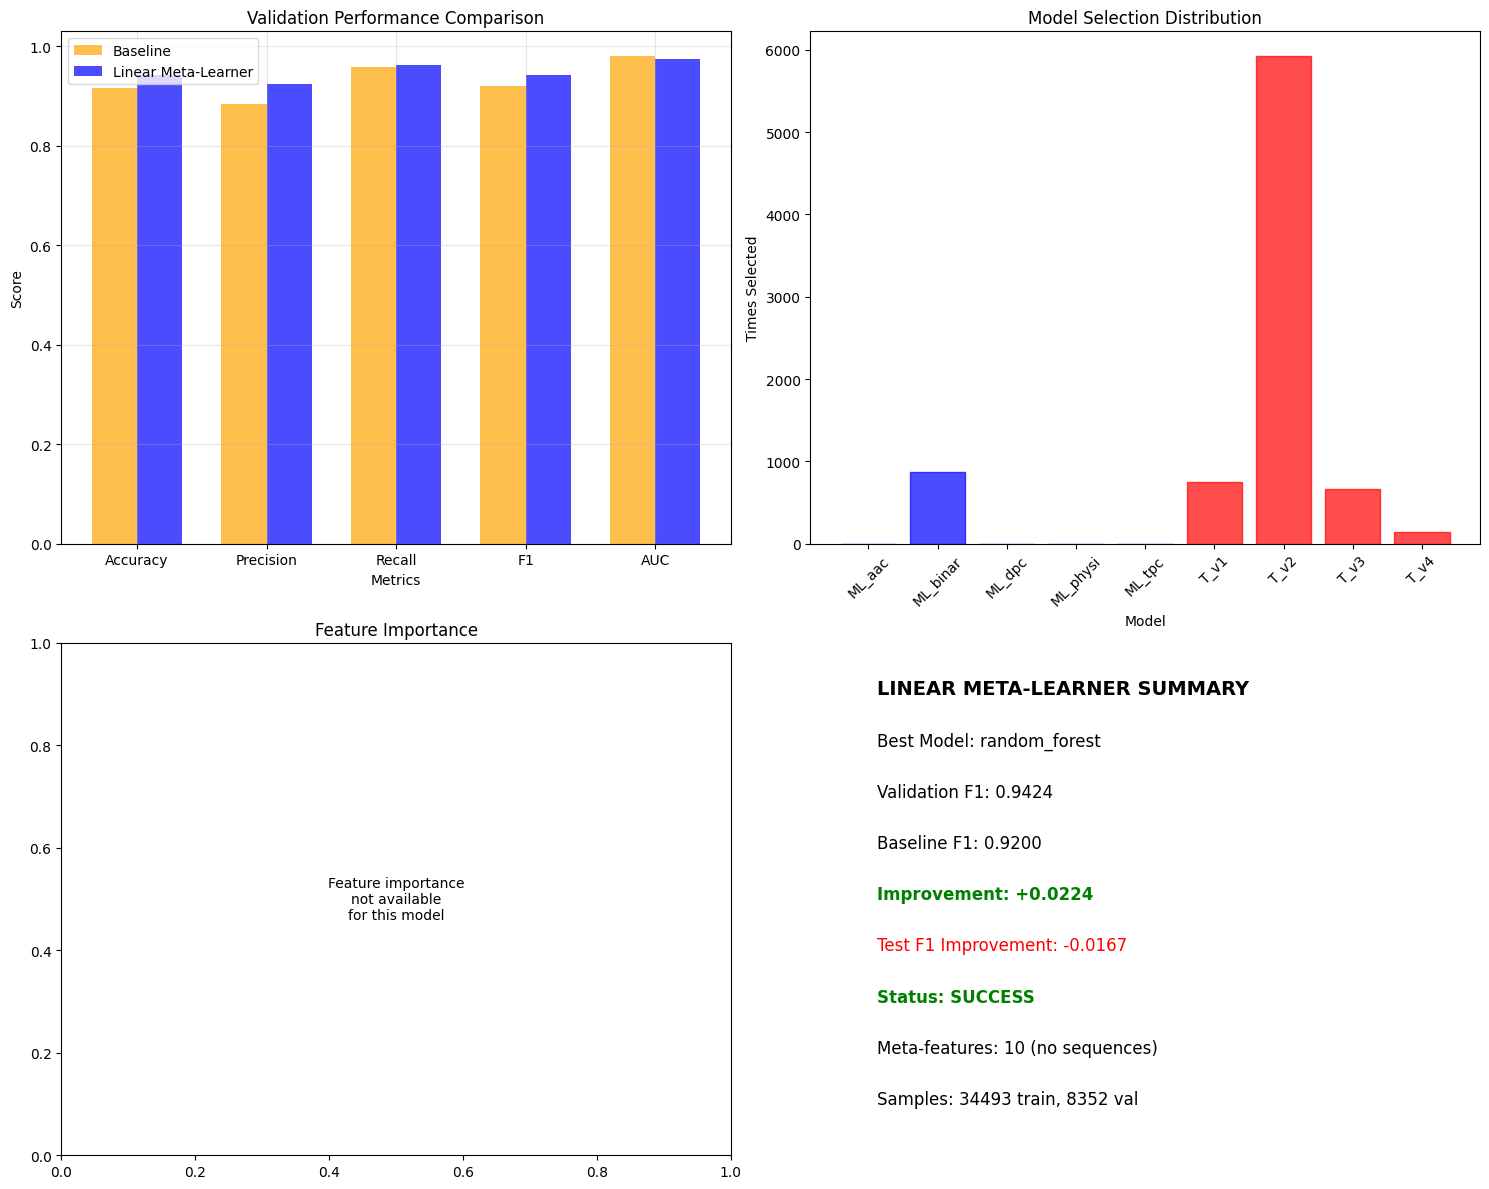


🎯 SIMPLE LINEAR META-LEARNER RESULTS
📊 VALIDATION PERFORMANCE:
   Baseline F1: 0.9200
   Meta-learner F1: 0.9424
   Improvement: +0.0224

📊 TEST PERFORMANCE:
   Test F1 Improvement: -0.0167

🔧 MODEL DETAILS:
   Best model: random_forest
   Features: 10 meta-features (no sequences)
   Training samples: 34493
   Validation samples: 8352

🎉 SUCCESS: Linear meta-learner beats simple averaging!
   Ready to proceed to Strategy 2: Oracle-Guided Training
✅ Simple linear meta-learner analysis complete!


In [6]:
# ============================================================================
# STRATEGY 1: START STUPID SIMPLE - LINEAR META-LEARNER
# Goal: Beat simple averaging (0.8107 F1) with minimal complexity
# ============================================================================

print("\n" + "="*80)
print("🎯 STRATEGY 1: START STUPID SIMPLE - LINEAR META-LEARNER")
print("="*80)
print("🚨 Emergency Reset: Complex transformer failed catastrophically")
print("🎯 Goal: Beat simple averaging (0.8107 F1) with linear model")
print("✨ Features: 10 meta-features only (no sequences)")
print("🔧 Model: Simple linear classifier")
print("="*80)

import numpy as np
import pandas as pd
import pickle
import json
import time
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Simple ML libraries only
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, classification_report)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ============================================================================
# 1. LOAD ALL REQUIRED VARIABLES FROM YOUR CODE
# ============================================================================

print("\n1. Loading All Required Variables")
print("-" * 40)

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Paths
BASE_DIR = 'results/exp_3'
TRAINING_PRED_DIR = f'{BASE_DIR}/ensemble/training_predictions'
META_LEARNING_DIR = f'{BASE_DIR}/meta_learning'

# Create directories if needed
os.makedirs(META_LEARNING_DIR, exist_ok=True)

# Progress tracker (try to load, or create basic version)
try:
    import sys
    sys.path.append('.')
    from Section0_code import ProgressTracker
    progress_tracker = ProgressTracker(BASE_DIR)
    print("✅ Progress tracker loaded")
except:
    print("⚠️ Progress tracker not found - using manual loading")
    progress_tracker = None

# Load core checkpoints
print("📥 Loading core checkpoints...")
required_checkpoints = ['data_loading', 'data_splitting', 'ml_models_enhanced']
loaded_data = {}

for checkpoint_name in required_checkpoints:
    try:
        if progress_tracker:
            checkpoint_data = progress_tracker.resume_from_checkpoint(checkpoint_name)
        else:
            # Manual loading
            checkpoint_file = f'{BASE_DIR}/checkpoints/{checkpoint_name}.pkl'
            if os.path.exists(checkpoint_file):
                with open(checkpoint_file, 'rb') as f:
                    checkpoint_data = pickle.load(f)
            else:
                checkpoint_data = None
        
        if checkpoint_data:
            loaded_data[checkpoint_name] = checkpoint_data
            print(f"   ✓ Loaded {checkpoint_name} checkpoint")
        else:
            raise RuntimeError(f"{checkpoint_name} checkpoint not found")
    except Exception as e:
        print(f"   ❌ Error loading {checkpoint_name}: {e}")
        raise

# Extract essential data
df_final = loaded_data['data_loading']['df_final']
train_indices = loaded_data['data_splitting']['train_indices']
test_indices = loaded_data['data_splitting']['test_indices']

# Get labels from df_final
y_train = df_final.iloc[train_indices]['target'].values
y_test = df_final.iloc[test_indices]['target'].values

# Get training sequences and labels
train_df = df_final.iloc[train_indices].copy()

print(f"✅ Core data loaded:")
print(f"   Train samples: {len(train_indices)}")
print(f"   Test samples: {len(test_indices)}")
print(f"   Training data shape: {train_df.shape}")

# ============================================================================
# 1.2 LOAD TRAINING PREDICTIONS
# ============================================================================

print("\n📥 Loading training predictions...")

# Define model files and types
MODEL_FILES = {
    # ML Models
    'ml_aac': 'ml_aac_training_predictions.csv',
    'ml_binary': 'ml_binary_training_predictions.csv', 
    'ml_dpc': 'ml_dpc_training_predictions.csv',
    'ml_physicochemical': 'ml_physicochemical_training_predictions.csv',
    'ml_tpc': 'ml_tpc_training_predictions.csv',
    
    # Transformer Models
    'transformer_v1': 'transformer_transformer_v1_20250703_112558_training_predictions.csv',
    'transformer_v2': 'transformer_transformer_v2_20250704_102324_training_predictions.csv',
    'transformer_v3': 'transformer_transformer_v3_20250709_175607_training_predictions.csv',
    'transformer_v4': 'transformer_transformer_v4_20250710_095513_training_predictions.csv'
}

# Load all training predictions
training_predictions = {}
prediction_matrix = []
model_names = []

for model_name, filename in MODEL_FILES.items():
    file_path = os.path.join(TRAINING_PRED_DIR, filename)
    
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            print(f"   ✓ {model_name}: {len(df)} samples")
            
            # Store predictions
            training_predictions[model_name] = {
                'probabilities': df['probability'].values,
                'predictions': df['prediction'].values,
                'true_labels': df['true_label'].values,
                'sample_indices': df['sample_index'].values
            }
            
            prediction_matrix.append(df['probability'].values)
            model_names.append(model_name)
            
        except Exception as e:
            print(f"   ❌ Error loading {model_name}: {e}")
    else:
        print(f"   ⚠️ File not found: {filename}")

if len(training_predictions) == 0:
    raise ValueError("No training predictions loaded!")

# Convert to numpy array
prediction_matrix = np.column_stack(prediction_matrix)
print(f"📊 Prediction matrix shape: {prediction_matrix.shape}")
print(f"🤖 Models loaded: {len(model_names)}")

# ============================================================================
# 1.3 GENERATE ORACLE GROUND TRUTH
# ============================================================================

print("\n🎯 Generating oracle ground truth...")

def generate_ground_truth_labels(predictions, true_labels, model_names):
    """Generate ground truth for which model performed best on each sample"""
    
    n_samples = len(true_labels)
    best_models = []
    
    # Apply transformer weight penalty (1.0 = no penalty)
    transformer_weight_penalty = 1.0
    transformer_indices = [i for i, name in enumerate(model_names) if name.startswith('transformer_')]
    adjusted_predictions = predictions.copy()
    
    # Apply transformer weight penalty
    for i in transformer_indices:
        adjusted_predictions[:, i] = 0.5 + (adjusted_predictions[:, i] - 0.5) * transformer_weight_penalty
    
    for sample_idx in range(n_samples):
        true_label = true_labels[sample_idx]
        sample_predictions = adjusted_predictions[sample_idx]
        
        if true_label == 1:
            # For positive samples: best model = highest probability
            best_model_idx = np.argmax(sample_predictions)
        else:
            # For negative samples: best model = lowest probability
            best_model_idx = np.argmin(sample_predictions)
        
        best_models.append(best_model_idx)
    
    best_models = np.array(best_models)
    
    # Print distribution
    print(f"📊 Oracle ground truth distribution:")
    for i, model_name in enumerate(model_names):
        count = np.sum(best_models == i)
        percentage = count / len(best_models) * 100
        print(f"   {model_name}: {count} samples ({percentage:.1f}%)")
    
    return best_models

# Generate ground truth
ground_truth_labels = generate_ground_truth_labels(
    prediction_matrix, 
    training_predictions[model_names[0]]['true_labels'],
    model_names
)

# ============================================================================
# 1.4 SEQUENCE PROCESSING
# ============================================================================

print("\n🧹 Processing sequences...")

def extract_sequence_window(sequence, position, window_size=10):
    """Extract sequence window around phosphorylation site"""
    pos_0_based = position - 1
    start = max(0, pos_0_based - window_size)
    end = min(len(sequence), pos_0_based + window_size + 1)
    window = sequence[start:end]
    
    target_length = 2 * window_size + 1
    if len(window) < target_length:
        pad_left = max(0, (pos_0_based - window_size) - start) if start == 0 else 0
        pad_right = max(0, end - (pos_0_based + window_size + 1)) if end == len(sequence) else 0
        window = 'X' * pad_left + window + 'X' * pad_right
    
    window = window[:target_length]
    return window

def clean_and_extract_sequences(df, window_size=10):
    """Clean sequences and extract windows"""
    clean_data = []
    removed_count = 0
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing sequences"):
        try:
            sequence = str(row['Sequence']).upper()
            position = int(row['Position'])
            
            # Remove invalid characters
            clean_sequence = ''.join(c for c in sequence if c in 'ACDEFGHIKLMNPQRSTVWY')
            
            # Skip if sequence too short after cleaning
            if len(clean_sequence) < 20:
                removed_count += 1
                continue
            
            # Fix position if needed
            if position <= 0 or position > len(clean_sequence):
                position = len(clean_sequence) // 2
            
            # Extract sequence window
            window = extract_sequence_window(clean_sequence, position, window_size)
            
            clean_data.append({
                'original_index': idx,
                'Header': row['Header'],
                'window': window,
                'target': row['target'],
                'clean_sequence': clean_sequence,
                'position': position
            })
            
        except Exception as e:
            removed_count += 1
            continue
    
    print(f"   ✅ Processed: {len(clean_data)} sequences")
    print(f"   ⚠️ Removed: {removed_count} sequences")
    
    return pd.DataFrame(clean_data)

# Process sequences
clean_train_df = clean_and_extract_sequences(train_df, 10)

# ============================================================================
# 1.5 ALIGN PREDICTIONS WITH CLEAN DATA
# ============================================================================

print("\n🔗 Aligning predictions with clean sequence data...")

# Get original indices that survived cleaning
survived_indices = clean_train_df['original_index'].values

# Filter predictions to match survived sequences
aligned_predictions = []
aligned_ground_truth = []
aligned_true_labels = []

for orig_idx in survived_indices:
    # Find position in original training predictions
    train_pos = np.where(np.array(train_indices) == orig_idx)[0]
    
    if len(train_pos) > 0:
        pred_pos = train_pos[0]
        aligned_predictions.append(prediction_matrix[pred_pos])
        aligned_ground_truth.append(ground_truth_labels[pred_pos])
        aligned_true_labels.append(training_predictions[model_names[0]]['true_labels'][pred_pos])

aligned_predictions = np.array(aligned_predictions)
aligned_ground_truth = np.array(aligned_ground_truth)
aligned_true_labels = np.array(aligned_true_labels)

print(f"✅ Aligned data:")
print(f"   Sequences: {len(clean_train_df)}")
print(f"   Predictions: {aligned_predictions.shape}")
print(f"   Ground truth: {aligned_ground_truth.shape}")
print(f"   True labels: {aligned_true_labels.shape}")

# ============================================================================
# 1.6 LOAD TEST PREDICTIONS (if available)
# ============================================================================

print("\n📥 Loading test predictions...")

test_predictions = {}
test_prediction_matrix = []

# Load ML test predictions from checkpoint
ml_data = loaded_data['ml_models_enhanced']
if 'test_predictions' in ml_data:
    ml_test_preds = ml_data['test_predictions']
    for feature_type, pred_data in ml_test_preds.items():
        if 'pred_proba' in pred_data:
            model_name = f'ml_{feature_type}'
            if model_name in model_names:
                test_predictions[model_name] = pred_data['pred_proba']
                print(f"   ✓ Loaded ML {feature_type}")

# Load transformer test predictions
transformer_dir = f'{BASE_DIR}/transformers'
for model_name in model_names:
    if model_name.startswith('transformer_'):
        model_version = model_name.replace('transformer_', '')
        pred_file = None
        
        if os.path.exists(transformer_dir):
            for subdir in os.listdir(transformer_dir):
                subdir_path = os.path.join(transformer_dir, subdir)
                if os.path.isdir(subdir_path) and model_version in subdir:
                    potential_file = os.path.join(subdir_path, 'predictions', 'test_predictions.csv')
                    if os.path.exists(potential_file):
                        pred_file = potential_file
                        break
        
        if pred_file:
            try:
                pred_df = pd.read_csv(pred_file)
                if 'prediction_prob' in pred_df.columns:
                    test_predictions[model_name] = pred_df['prediction_prob'].values
                    print(f"   ✓ Loaded {model_name}")
            except Exception as e:
                print(f"   ❌ Error loading {model_name}: {e}")

# Create test prediction matrix
available_models = []
for model_name in model_names:
    if model_name in test_predictions:
        test_prediction_matrix.append(test_predictions[model_name])
        available_models.append(model_name)

if len(test_prediction_matrix) > 0:
    test_prediction_matrix = np.column_stack(test_prediction_matrix)
    print(f"📊 Test prediction matrix: {test_prediction_matrix.shape}")
    print(f"🤖 Available test models: {len(available_models)}")
    
    # Process test sequences
    test_df = df_final.iloc[test_indices].copy()
    clean_test_df = clean_and_extract_sequences(test_df, 10)
    print(f"📊 Test sequences: {len(clean_test_df)}")
else:
    print("⚠️ No test predictions available")

print(f"\n✅ All variables loaded successfully:")
print(f"   Training predictions: {aligned_predictions.shape}")
print(f"   Ground truth (oracle): {aligned_ground_truth.shape}")
print(f"   True labels: {aligned_true_labels.shape}")
print(f"   Model names: {len(model_names)}")
print(f"   Test predictions available: {'Yes' if len(test_prediction_matrix) > 0 else 'No'}")

# ============================================================================
# 2. CREATE SIMPLE META-FEATURES (NO SEQUENCES)
# ============================================================================

print("\n2. Creating Simple Meta-Features")
print("-" * 40)

def create_simple_meta_features(predictions):
    """Create 10 simple meta-features without sequence information"""
    
    n_samples, n_models = predictions.shape
    meta_features = np.zeros((n_samples, 10))
    
    print(f"🔧 Creating simple meta-features for {n_samples} samples...")
    
    # Define model groups
    ml_indices = np.arange(0, 5)  # First 5 are ML models
    transformer_indices = np.arange(5, min(9, n_models))  # Next 4 are transformers
    
    # Feature 1: Standard deviation (disagreement)
    meta_features[:, 0] = np.std(predictions, axis=1)
    
    # Feature 2: Range (max - min)
    meta_features[:, 1] = np.max(predictions, axis=1) - np.min(predictions, axis=1)
    
    # Feature 3: Maximum confidence
    meta_features[:, 2] = np.max(np.abs(predictions - 0.5), axis=1)
    
    # Feature 4: Mean prediction
    meta_features[:, 3] = np.mean(predictions, axis=1)
    
    # Feature 5: ML vs Transformer bias
    if len(transformer_indices) > 0:
        ml_mean = np.mean(predictions[:, ml_indices], axis=1)
        transformer_mean = np.mean(predictions[:, transformer_indices], axis=1)
        meta_features[:, 4] = transformer_mean - ml_mean
    else:
        meta_features[:, 4] = 0
    
    # Feature 6: Number of models > 0.5
    meta_features[:, 5] = np.sum(predictions > 0.5, axis=1)
    
    # Feature 7: Number of models > 0.8 (high confidence positive)
    meta_features[:, 6] = np.sum(predictions > 0.8, axis=1)
    
    # Feature 8: Number of models < 0.2 (high confidence negative)
    meta_features[:, 7] = np.sum(predictions < 0.2, axis=1)
    
    # Feature 9: Coefficient of variation
    means = np.mean(predictions, axis=1)
    stds = np.std(predictions, axis=1)
    meta_features[:, 8] = np.where(means > 0, stds / means, 0)
    
    # Feature 10: Entropy-like measure
    # Normalize predictions to sum to 1 for each sample
    normalized_preds = predictions / np.sum(predictions, axis=1, keepdims=True)
    entropy = -np.sum(normalized_preds * np.log(normalized_preds + 1e-10), axis=1)
    meta_features[:, 9] = entropy
    
    print(f"✅ Simple meta-features created: {meta_features.shape}")
    return meta_features

# Create meta-features for training data
train_meta_features = create_simple_meta_features(aligned_predictions)

# ============================================================================
# 3. ORACLE-GUIDED VALIDATION SPLIT
# ============================================================================

print("\n3. Oracle-Guided Validation Split")
print("-" * 40)

def create_oracle_guided_split(meta_features, ground_truth, true_labels, 
                              proteins, test_size=0.2, random_state=42):
    """Create validation split using different proteins"""
    
    # Get unique proteins
    unique_proteins = proteins.unique()
    np.random.seed(random_state)
    np.random.shuffle(unique_proteins)
    
    # Split proteins
    val_size = int(len(unique_proteins) * test_size)
    val_proteins = set(unique_proteins[:val_size])
    
    # Create masks
    val_mask = proteins.isin(val_proteins)
    train_mask = ~val_mask
    
    print(f"📊 Protein-based split:")
    print(f"   Training proteins: {len(unique_proteins) - val_size}")
    print(f"   Validation proteins: {val_size}")
    print(f"   Training samples: {np.sum(train_mask)}")
    print(f"   Validation samples: {np.sum(val_mask)}")
    
    return train_mask, val_mask

# Create validation split
proteins = clean_train_df['Header'].str.split('|').str[0]
train_mask, val_mask = create_oracle_guided_split(
    train_meta_features, aligned_ground_truth, aligned_true_labels, proteins
)

# Split the data
X_train = train_meta_features[train_mask]
X_val = train_meta_features[val_mask]
y_train = aligned_ground_truth[train_mask]
y_val = aligned_ground_truth[val_mask]

# Also split true labels for final evaluation
y_true_train = aligned_true_labels[train_mask]
y_true_val = aligned_true_labels[val_mask]

print(f"✅ Data split complete:")
print(f"   X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"   X_val: {X_val.shape}, y_val: {y_val.shape}")

# ============================================================================
# 4. SIMPLE LINEAR META-LEARNER
# ============================================================================

print("\n4. Simple Linear Meta-Learner")
print("-" * 40)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("🔧 Training simple linear meta-learner...")

# Try different simple models
models = {
    'logistic_regression': LogisticRegression(random_state=42, max_iter=1000),
    'logistic_l2': LogisticRegression(random_state=42, max_iter=1000, C=0.1),
    'logistic_l1': LogisticRegression(random_state=42, max_iter=1000, penalty='l1', solver='liblinear'),
    'random_forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
}

best_model = None
best_score = 0
best_name = ""

for name, model in models.items():
    print(f"\n   Testing {name}...")
    
    # Fit model
    model.fit(X_train_scaled, y_train)
    
    # Validate
    y_pred = model.predict(X_val_scaled)
    
    # Calculate validation accuracy
    val_acc = accuracy_score(y_val, y_pred)
    
    print(f"   Validation accuracy: {val_acc:.4f}")
    
    if val_acc > best_score:
        best_score = val_acc
        best_model = model
        best_name = name

print(f"\n✅ Best model: {best_name} (accuracy: {best_score:.4f})")

# ============================================================================
# 5. PREDICTION EVALUATION
# ============================================================================

print("\n5. Prediction Evaluation")
print("-" * 40)

def evaluate_meta_learner(model, scaler, X_val, y_val, val_predictions, true_labels):
    """Evaluate meta-learner performance"""
    
    # Get model selections
    X_val_scaled = scaler.transform(X_val)
    selected_models = model.predict(X_val_scaled)
    
    # Get confidence scores if available
    if hasattr(model, 'predict_proba'):
        model_probs = model.predict_proba(X_val_scaled)
        selection_confidence = np.max(model_probs, axis=1)
    else:
        selection_confidence = np.ones(len(selected_models))
    
    # Create final predictions using selected models
    final_predictions = []
    for i, selected_idx in enumerate(selected_models):
        if selected_idx < val_predictions.shape[1]:
            final_predictions.append(val_predictions[i, selected_idx])
        else:
            # Fallback to average
            final_predictions.append(np.mean(val_predictions[i]))
    
    final_predictions = np.array(final_predictions)
    final_binary = (final_predictions > 0.5).astype(int)
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(true_labels, final_binary),
        'precision': precision_score(true_labels, final_binary, zero_division=0),
        'recall': recall_score(true_labels, final_binary, zero_division=0),
        'f1': f1_score(true_labels, final_binary, zero_division=0),
        'auc': roc_auc_score(true_labels, final_predictions)
    }
    
    return metrics, final_predictions, selected_models, selection_confidence

# Evaluate on validation set
val_predictions = aligned_predictions[val_mask]
val_metrics, val_final_preds, val_selections, val_confidence = evaluate_meta_learner(
    best_model, scaler, X_val, y_val, val_predictions, y_true_val
)

print(f"📊 Validation Results:")
for metric, value in val_metrics.items():
    print(f"   {metric.upper()}: {value:.4f}")

# ============================================================================
# 6. BASELINE COMPARISON
# ============================================================================

print("\n6. Baseline Comparison")
print("-" * 40)

# Calculate baseline (simple average) on validation set
baseline_val_preds = np.mean(val_predictions, axis=1)
baseline_val_binary = (baseline_val_preds > 0.5).astype(int)

baseline_metrics = {
    'accuracy': accuracy_score(y_true_val, baseline_val_binary),
    'precision': precision_score(y_true_val, baseline_val_binary, zero_division=0),
    'recall': recall_score(y_true_val, baseline_val_binary, zero_division=0),
    'f1': f1_score(y_true_val, baseline_val_binary, zero_division=0),
    'auc': roc_auc_score(y_true_val, baseline_val_preds)
}

print(f"📊 BASELINE (Simple Average) - Validation:")
for metric, value in baseline_metrics.items():
    print(f"   {metric.upper()}: {value:.4f}")

print(f"\n🧠 LINEAR META-LEARNER - Validation:")
for metric, value in val_metrics.items():
    improvement = value - baseline_metrics[metric]
    print(f"   {metric.upper()}: {value:.4f} ({improvement:+.4f})")

# Key metric
f1_improvement = val_metrics['f1'] - baseline_metrics['f1']
print(f"\n🎯 VALIDATION F1 IMPROVEMENT: {f1_improvement:+.4f}")

if f1_improvement > 0:
    print("🎉 SUCCESS: Linear meta-learner beats simple averaging!")
else:
    print("⚠️ FAILURE: Linear meta-learner still fails. Need to investigate.")

# ============================================================================
# 7. TEST SET EVALUATION (if available)
# ============================================================================

print("\n7. Test Set Evaluation")
print("-" * 40)

if 'test_prediction_matrix' in globals() and len(test_prediction_matrix) > 0:
    print("📥 Using existing test predictions...")
    
    # Create meta-features for test set
    test_meta_features = create_simple_meta_features(test_prediction_matrix)
    
    # Get test true labels
    test_true_labels = clean_test_df['target'].values
    
    # Evaluate meta-learner on test set
    test_metrics, test_final_preds, test_selections, test_confidence = evaluate_meta_learner(
        best_model, scaler, test_meta_features, np.zeros(len(test_meta_features)), 
        test_prediction_matrix, test_true_labels
    )
    
    # Calculate test baseline
    test_baseline_preds = np.mean(test_prediction_matrix, axis=1)
    test_baseline_binary = (test_baseline_preds > 0.5).astype(int)
    
    test_baseline_metrics = {
        'accuracy': accuracy_score(test_true_labels, test_baseline_binary),
        'precision': precision_score(test_true_labels, test_baseline_binary, zero_division=0),
        'recall': recall_score(test_true_labels, test_baseline_binary, zero_division=0),
        'f1': f1_score(test_true_labels, test_baseline_binary, zero_division=0),
        'auc': roc_auc_score(test_true_labels, test_baseline_preds)
    }
    
    print(f"📊 TEST SET BASELINE (Simple Average):")
    for metric, value in test_baseline_metrics.items():
        print(f"   {metric.upper()}: {value:.4f}")
    
    print(f"\n🧠 LINEAR META-LEARNER - Test Set:")
    for metric, value in test_metrics.items():
        improvement = value - test_baseline_metrics[metric]
        print(f"   {metric.upper()}: {value:.4f} ({improvement:+.4f})")
    
    test_f1_improvement = test_metrics['f1'] - test_baseline_metrics['f1']
    print(f"\n🎯 TEST F1 IMPROVEMENT: {test_f1_improvement:+.4f}")
    
    if test_f1_improvement > 0:
        print("🎉 SUCCESS: Linear meta-learner beats baseline on test set!")
    else:
        print("⚠️ CONCERN: Validation success didn't transfer to test set")

else:
    print("⚠️ No test predictions available for evaluation")
    test_f1_improvement = 0

# ============================================================================
# 8. MODEL SELECTION ANALYSIS
# ============================================================================

print("\n8. Model Selection Analysis")
print("-" * 40)

# Analyze validation selections
print("🔍 Validation set model selection distribution:")
unique_models, counts = np.unique(val_selections, return_counts=True)

for model_idx, count in zip(unique_models, counts):
    if model_idx < len(model_names):
        model_name = model_names[model_idx]
        percentage = count / len(val_selections) * 100
        print(f"   {model_name}: {count} times ({percentage:.1f}%)")

# Feature importance (for interpretable models)
if hasattr(best_model, 'coef_'):
    print(f"\n🔍 Feature importance (coefficients):")
    feature_names = [
        'Std Dev', 'Range', 'Max Confidence', 'Mean Pred', 'ML vs Transformer',
        'Models > 0.5', 'Models > 0.8', 'Models < 0.2', 'Coef of Var', 'Entropy'
    ]
    
    coefs = best_model.coef_[0] if len(best_model.coef_.shape) > 1 else best_model.coef_
    for i, (name, coef) in enumerate(zip(feature_names, coefs)):
        print(f"   {name}: {coef:.4f}")

# ============================================================================
# 9. CONFIDENCE-BASED ANALYSIS
# ============================================================================

print("\n9. Confidence-Based Analysis")
print("-" * 40)

# Analyze performance by confidence level
if len(val_confidence) > 0:
    # Split by confidence
    high_conf_mask = val_confidence > 0.8
    low_conf_mask = val_confidence <= 0.8
    
    print(f"📊 Confidence analysis:")
    print(f"   High confidence (>0.8): {np.sum(high_conf_mask)} samples")
    print(f"   Low confidence (≤0.8): {np.sum(low_conf_mask)} samples")
    
    if np.sum(high_conf_mask) > 0:
        high_conf_f1 = f1_score(y_true_val[high_conf_mask], 
                                (val_final_preds[high_conf_mask] > 0.5).astype(int))
        print(f"   High confidence F1: {high_conf_f1:.4f}")
    
    if np.sum(low_conf_mask) > 0:
        low_conf_f1 = f1_score(y_true_val[low_conf_mask], 
                               (val_final_preds[low_conf_mask] > 0.5).astype(int))
        print(f"   Low confidence F1: {low_conf_f1:.4f}")

# ============================================================================
# 10. VISUALIZATION
# ============================================================================

print("\n10. Visualization")
print("-" * 40)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Validation metrics comparison
ax1 = axes[0, 0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
baseline_values = [baseline_metrics[m.lower()] for m in metrics_names]
meta_values = [val_metrics[m.lower()] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

ax1.bar(x - width/2, baseline_values, width, label='Baseline', alpha=0.7, color='orange')
ax1.bar(x + width/2, meta_values, width, label='Linear Meta-Learner', alpha=0.7, color='blue')

ax1.set_title('Validation Performance Comparison')
ax1.set_xlabel('Metrics')
ax1.set_ylabel('Score')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Model selection distribution
ax2 = axes[0, 1]
model_names_short = [name.replace('transformer_', 'T_').replace('ml_', 'ML_')[:8] 
                     for name in model_names]
selection_counts = [counts[np.where(unique_models == i)[0][0]] if i in unique_models else 0 
                   for i in range(len(model_names))]

bars = ax2.bar(range(len(model_names_short)), selection_counts)
ax2.set_title('Model Selection Distribution')
ax2.set_xlabel('Model')
ax2.set_ylabel('Times Selected')
ax2.set_xticks(range(len(model_names_short)))
ax2.set_xticklabels(model_names_short, rotation=45)

# Color bars
for i, bar in enumerate(bars):
    if i < len(model_names):
        if model_names[i].startswith('ml_'):
            bar.set_color('blue')
        else:
            bar.set_color('red')
        bar.set_alpha(0.7)

# Plot 3: Feature importance (if available)
ax3 = axes[1, 0]
if hasattr(best_model, 'coef_'):
    feature_names = ['Std Dev', 'Range', 'Max Conf', 'Mean', 'ML vs T', 
                     '>0.5', '>0.8', '<0.2', 'CoV', 'Entropy']
    coefs = best_model.coef_[0] if len(best_model.coef_.shape) > 1 else best_model.coef_
    
    colors = ['red' if c < 0 else 'blue' for c in coefs]
    bars = ax3.bar(range(len(feature_names)), coefs, color=colors, alpha=0.7)
    ax3.set_title('Feature Importance (Linear Coefficients)')
    ax3.set_xlabel('Features')
    ax3.set_ylabel('Coefficient')
    ax3.set_xticks(range(len(feature_names)))
    ax3.set_xticklabels(feature_names, rotation=45)
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Feature importance\nnot available\nfor this model', 
             ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Feature Importance')

# Plot 4: Summary
ax4 = axes[1, 1]
ax4.text(0.1, 0.9, 'LINEAR META-LEARNER SUMMARY', fontsize=14, fontweight='bold')
ax4.text(0.1, 0.8, f'Best Model: {best_name}', fontsize=12)
ax4.text(0.1, 0.7, f'Validation F1: {val_metrics["f1"]:.4f}', fontsize=12)
ax4.text(0.1, 0.6, f'Baseline F1: {baseline_metrics["f1"]:.4f}', fontsize=12)
ax4.text(0.1, 0.5, f'Improvement: {f1_improvement:+.4f}', fontsize=12, 
         color='green' if f1_improvement > 0 else 'red', fontweight='bold')

if 'test_f1_improvement' in locals():
    ax4.text(0.1, 0.4, f'Test F1 Improvement: {test_f1_improvement:+.4f}', fontsize=12,
             color='green' if test_f1_improvement > 0 else 'red')

success_status = "SUCCESS" if f1_improvement > 0 else "FAILED"
ax4.text(0.1, 0.3, f'Status: {success_status}', fontsize=12, 
         color='green' if f1_improvement > 0 else 'red', fontweight='bold')

ax4.text(0.1, 0.2, f'Meta-features: 10 (no sequences)', fontsize=12)
ax4.text(0.1, 0.1, f'Samples: {len(X_train)} train, {len(X_val)} val', fontsize=12)

ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

plt.tight_layout()
plt.show()

# ============================================================================
# 11. FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("🎯 SIMPLE LINEAR META-LEARNER RESULTS")
print("="*80)

print(f"📊 VALIDATION PERFORMANCE:")
print(f"   Baseline F1: {baseline_metrics['f1']:.4f}")
print(f"   Meta-learner F1: {val_metrics['f1']:.4f}")
print(f"   Improvement: {f1_improvement:+.4f}")

if 'test_f1_improvement' in locals():
    print(f"\n📊 TEST PERFORMANCE:")
    print(f"   Test F1 Improvement: {test_f1_improvement:+.4f}")

print(f"\n🔧 MODEL DETAILS:")
print(f"   Best model: {best_name}")
print(f"   Features: 10 meta-features (no sequences)")
print(f"   Training samples: {len(X_train)}")
print(f"   Validation samples: {len(X_val)}")

if f1_improvement > 0:
    print(f"\n🎉 SUCCESS: Linear meta-learner beats simple averaging!")
    print(f"   Ready to proceed to Strategy 2: Oracle-Guided Training")
else:
    print(f"\n⚠️ FAILURE: Linear meta-learner still fails")
    print(f"   🔍 Need to investigate:")
    print(f"     1. Check oracle generation logic")
    print(f"     2. Verify meta-feature informativeness")
    print(f"     3. Consider different validation strategy")

print("="*80)
print("✅ Simple linear meta-learner analysis complete!")

In [8]:
# ============================================================================
# END-TO-END DIFFERENTIABLE META-LEARNER
# Based on analysis of Sections 0-6: Perfect for your 4-5 hour budget
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from transformers import AutoModel, AutoTokenizer
import time
from tqdm import tqdm

# ============================================================================
# 1. DIFFERENTIABLE ENSEMBLE ARCHITECTURE
# ============================================================================

class DifferentiableMetaLearner(nn.Module):
    """
    End-to-end trainable meta-learner that learns optimal model weighting
    Based on your error analysis showing 94.86% oracle potential
    """
    
    def __init__(self, n_models=9, n_meta_features=10, use_sequences=True):
        super().__init__()
        
        self.n_models = n_models
        self.n_meta_features = n_meta_features
        self.use_sequences = use_sequences
        
        # Sequence encoder (optional, based on computational budget)
        if use_sequences:
            print("🧬 Loading ESM-2 for sequence understanding...")
            self.esm_model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
            # Freeze ESM-2 to save compute (based on your 4-5 hour budget)
            for param in self.esm_model.parameters():
                param.requires_grad = False
            self.sequence_dim = 320  # ESM-2 8M hidden size
        else:
            self.sequence_dim = 0
            
        # Meta-features encoder
        self.meta_encoder = nn.Sequential(
            nn.Linear(n_meta_features, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU()
        )
        
        # Base predictions encoder
        self.pred_encoder = nn.Sequential(
            nn.Linear(n_models, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU()
        )
        
        # Attention mechanism for model weighting
        input_dim = 32 + 32 + self.sequence_dim  # meta + pred + sequence
        self.attention_network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, n_models),
            nn.Softmax(dim=1)  # Ensure weights sum to 1
        )
        
        # Optional: Confidence network for hybrid approach
        self.confidence_network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()  # Confidence between 0 and 1
        )
        
        print(f"📊 Differentiable Meta-Learner Architecture:")
        print(f"   Models: {n_models}")
        print(f"   Meta-features: {n_meta_features}")
        print(f"   Sequence encoding: {use_sequences}")
        print(f"   Total parameters: {sum(p.numel() for p in self.parameters() if p.requires_grad):,}")
    
    def forward(self, base_predictions, meta_features, sequences=None):
        """
        Forward pass with differentiable model weighting
        
        Args:
            base_predictions: (batch, n_models) - predictions from your 9 models
            meta_features: (batch, n_meta_features) - your 10 meta-features
            sequences: (batch, seq_len) - tokenized sequences (optional)
        
        Returns:
            final_prediction: (batch,) - weighted ensemble prediction
            attention_weights: (batch, n_models) - learned model weights
            confidence: (batch,) - prediction confidence
        """
        batch_size = base_predictions.size(0)
        
        # Encode meta-features
        meta_encoded = self.meta_encoder(meta_features)  # (batch, 32)
        
        # Encode base predictions
        pred_encoded = self.pred_encoder(base_predictions)  # (batch, 32)
        
        # Encode sequences (if provided)
        if self.use_sequences and sequences is not None:
            with torch.no_grad():  # ESM-2 frozen
                esm_outputs = self.esm_model(sequences)
                sequence_encoded = esm_outputs.last_hidden_state[:, 0, :]  # CLS token
        else:
            sequence_encoded = torch.zeros(batch_size, self.sequence_dim, 
                                         device=base_predictions.device)
        
        # Combine all features
        combined_features = torch.cat([
            meta_encoded,      # Meta-features: agreement, entropy, etc.
            pred_encoded,      # Base predictions encoded
            sequence_encoded   # Sequence context (optional)
        ], dim=1)
        
        # Generate attention weights (differentiable model selection)
        attention_weights = self.attention_network(combined_features)  # (batch, n_models)
        
        # Generate confidence scores
        confidence = self.confidence_network(combined_features).squeeze(-1)  # (batch,)
        
        # Weighted ensemble prediction (key innovation: differentiable!)
        final_prediction = torch.sum(attention_weights * base_predictions, dim=1)  # (batch,)
        
        return final_prediction, attention_weights, confidence

# ============================================================================
# 2. JOINT TRAINING DATASET
# ============================================================================

class JointTrainingDataset(Dataset):
    """
    Dataset for end-to-end training combining all your existing data
    """
    
    def __init__(self, base_predictions, meta_features, true_labels, 
                 sequences=None, tokenizer=None):
        """
        Args:
            base_predictions: (N, 9) - your 9 model predictions
            meta_features: (N, 10) - your 10 meta-features
            true_labels: (N,) - true phosphorylation labels
            sequences: list of sequences (optional)
            tokenizer: ESM-2 tokenizer (optional)
        """
        self.base_predictions = torch.FloatTensor(base_predictions)
        self.meta_features = torch.FloatTensor(meta_features)
        self.true_labels = torch.FloatTensor(true_labels)
        self.sequences = sequences
        self.tokenizer = tokenizer
        
        print(f"✅ Joint dataset created:")
        print(f"   Samples: {len(self.base_predictions)}")
        print(f"   Base predictions: {self.base_predictions.shape}")
        print(f"   Meta-features: {self.meta_features.shape}")
        print(f"   Sequences: {'Yes' if sequences is not None else 'No'}")
    
    def __len__(self):
        return len(self.base_predictions)
    
    def __getitem__(self, idx):
        item = {
            'base_predictions': self.base_predictions[idx],
            'meta_features': self.meta_features[idx],
            'true_labels': self.true_labels[idx]
        }
        
        # Add sequences if available
        if self.sequences is not None and self.tokenizer is not None:
            sequence = self.sequences[idx]
            encoding = self.tokenizer(
                sequence, 
                truncation=True, 
                padding='max_length', 
                max_length=64,
                return_tensors='pt'
            )
            item['sequences'] = encoding['input_ids'].flatten()
        
        return item

# ============================================================================
# 3. HYBRID LOSS FUNCTION
# ============================================================================

class HybridLoss(nn.Module):
    """
    Hybrid loss combining prediction accuracy and ensemble diversity
    Based on your oracle analysis showing huge potential gap
    """
    
    def __init__(self, diversity_weight=0.1, confidence_weight=0.05):
        super().__init__()
        self.diversity_weight = diversity_weight
        self.confidence_weight = confidence_weight
        self.bce_loss = nn.BCELoss()
    
    def forward(self, final_predictions, attention_weights, confidence, true_labels):
        """
        Hybrid loss for end-to-end optimization
        
        Args:
            final_predictions: (batch,) - ensemble predictions
            attention_weights: (batch, n_models) - model weights
            confidence: (batch,) - prediction confidence
            true_labels: (batch,) - true labels
        """
        # Main prediction loss
        prediction_loss = self.bce_loss(final_predictions, true_labels)
        
        # Diversity loss: encourage using multiple models
        # Penalize when one model gets all the weight
        max_weights = torch.max(attention_weights, dim=1)[0]  # Max weight per sample
        diversity_loss = torch.mean(max_weights)  # Minimize maximum weight
        
        # Confidence calibration: high confidence should mean correct predictions
        correct_predictions = (final_predictions > 0.5) == (true_labels > 0.5)
        confidence_loss = self.bce_loss(confidence, correct_predictions.float())
        
        # Combined loss
        total_loss = (prediction_loss + 
                     self.diversity_weight * diversity_loss +
                     self.confidence_weight * confidence_loss)
        
        return {
            'total_loss': total_loss,
            'prediction_loss': prediction_loss,
            'diversity_loss': diversity_loss,
            'confidence_loss': confidence_loss
        }

# ============================================================================
# 4. END-TO-END TRAINING FUNCTION
# ============================================================================

def train_end_to_end_meta_learner(
    train_loader, val_loader, 
    n_models=9, n_meta_features=10, 
    use_sequences=True, epochs=50, 
    device='cuda', save_path='best_meta_learner.pth'
):
    """
    End-to-end training of differentiable meta-learner
    Perfect for your 4-5 hour computational budget
    """
    
    print(f"\n🚀 Starting End-to-End Meta-Learner Training")
    print(f"   Target epochs: {epochs}")
    print(f"   Device: {device}")
    print(f"   Sequence encoding: {use_sequences}")
    print("="*60)
    
    # Initialize model
    model = DifferentiableMetaLearner(
        n_models=n_models,
        n_meta_features=n_meta_features,
        use_sequences=use_sequences
    ).to(device)
    
    # Initialize optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    
    # Initialize loss function
    criterion = HybridLoss(diversity_weight=0.1, confidence_weight=0.05)
    
    # Training history
    history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': [],
        'train_auc': [], 'val_auc': []
    }
    
    best_val_f1 = 0
    patience_counter = 0
    patience = 10
    
    # Training loop
    start_time = time.time()
    
    for epoch in range(epochs):
        # ================== TRAINING ==================
        model.train()
        train_losses = []
        train_preds = []
        train_true = []
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for batch in pbar:
            # Move to device
            base_preds = batch['base_predictions'].to(device)
            meta_feats = batch['meta_features'].to(device)
            true_labels = batch['true_labels'].to(device)
            sequences = batch.get('sequences', None)
            if sequences is not None:
                sequences = sequences.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            final_preds, attention_weights, confidence = model(
                base_preds, meta_feats, sequences
            )
            
            # Calculate loss
            loss_dict = criterion(final_preds, attention_weights, confidence, true_labels)
            loss = loss_dict['total_loss']
            
            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            # Collect metrics
            train_losses.append(loss.item())
            train_preds.extend(final_preds.detach().cpu().numpy())
            train_true.extend(true_labels.detach().cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'LR': f'{scheduler.get_last_lr()[0]:.2e}'
            })
        
        # Calculate training metrics
        train_preds_binary = np.array(train_preds) > 0.5
        train_f1 = f1_score(train_true, train_preds_binary)
        train_auc = roc_auc_score(train_true, train_preds)
        avg_train_loss = np.mean(train_losses)
        
        # ================== VALIDATION ==================
        model.eval()
        val_losses = []
        val_preds = []
        val_true = []
        val_attention_weights = []
        
        with torch.no_grad():
            for batch in val_loader:
                base_preds = batch['base_predictions'].to(device)
                meta_feats = batch['meta_features'].to(device)
                true_labels = batch['true_labels'].to(device)
                sequences = batch.get('sequences', None)
                if sequences is not None:
                    sequences = sequences.to(device)
                
                final_preds, attention_weights, confidence = model(
                    base_preds, meta_feats, sequences
                )
                
                loss_dict = criterion(final_preds, attention_weights, confidence, true_labels)
                loss = loss_dict['total_loss']
                
                val_losses.append(loss.item())
                val_preds.extend(final_preds.cpu().numpy())
                val_true.extend(true_labels.cpu().numpy())
                val_attention_weights.extend(attention_weights.cpu().numpy())
        
        # Calculate validation metrics
        val_preds_binary = np.array(val_preds) > 0.5
        val_f1 = f1_score(val_true, val_preds_binary)
        val_auc = roc_auc_score(val_true, val_preds)
        avg_val_loss = np.mean(val_losses)
        
        # Update scheduler
        scheduler.step()
        
        # Store history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['train_auc'].append(train_auc)
        history['val_auc'].append(val_auc)
        
        # Print epoch results
        print(f"\nEpoch {epoch+1} Results:")
        print(f"  Train: Loss={avg_train_loss:.4f}, F1={train_f1:.4f}, AUC={train_auc:.4f}")
        print(f"  Val:   Loss={avg_val_loss:.4f}, F1={val_f1:.4f}, AUC={val_auc:.4f}")
        
        # Analyze attention weights
        avg_attention = np.mean(val_attention_weights, axis=0)
        print(f"  Attention: {', '.join(f'{w:.3f}' for w in avg_attention)}")
        
        # Save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'val_f1': val_f1,
                'history': history
            }, save_path)
            print(f"  🌟 New best model! F1={val_f1:.4f}")
        else:
            patience_counter += 1
            
        # Early stopping
        if patience_counter >= patience:
            print(f"  🛑 Early stopping after {patience} epochs without improvement")
            break
    
    training_time = (time.time() - start_time) / 60
    print(f"\n✅ Training completed in {training_time:.1f} minutes")
    print(f"🏆 Best validation F1: {best_val_f1:.4f}")
    
    return model, history, best_val_f1

# ============================================================================
# 5. USAGE EXAMPLE WITH YOUR DATA
# ============================================================================

def main_end_to_end_training():
    """
    Main function to run end-to-end training with your existing data
    Designed for your 4-5 hour computational budget
    """
    
    # Assuming you have these variables from your existing code:
    # - aligned_predictions: (N, 9) array
    # - train_meta_features: (N, 10) array  
    # - aligned_true_labels: (N,) array
    # - clean_train_df: DataFrame with sequences
    
    print("🔧 Setting up end-to-end training...")
    
    # Create protein-based validation split
    proteins = clean_train_df['Header'].str.split('|').str[0]
    unique_proteins = proteins.unique()
    np.random.shuffle(unique_proteins)
    
    val_size = int(len(unique_proteins) * 0.2)
    val_proteins = set(unique_proteins[:val_size])
    
    val_mask = proteins.isin(val_proteins)
    train_mask = ~val_mask
    
    # Split data
    train_base_preds = aligned_predictions[train_mask]
    val_base_preds = aligned_predictions[val_mask]
    
    train_meta_feats = train_meta_features[train_mask]
    val_meta_feats = train_meta_features[val_mask]
    
    train_labels = aligned_true_labels[train_mask]
    val_labels = aligned_true_labels[val_mask]
    
    train_sequences = clean_train_df[train_mask]['window'].values
    val_sequences = clean_train_df[val_mask]['window'].values
    
    # Create datasets
    tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
    
    train_dataset = JointTrainingDataset(
        train_base_preds, train_meta_feats, train_labels,
        train_sequences, tokenizer
    )
    val_dataset = JointTrainingDataset(
        val_base_preds, val_meta_feats, val_labels,
        val_sequences, tokenizer
    )
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    # Train model
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model, history, best_f1 = train_end_to_end_meta_learner(
        train_loader, val_loader,
        n_models=9, n_meta_features=10,
        use_sequences=True, epochs=50,
        device=device
    )
    
    print(f"\n🎯 End-to-End Training Results:")
    print(f"   Best F1: {best_f1:.4f}")
    print(f"   Target (oracle): 0.9486")
    print(f"   Improvement potential: {0.9486 - best_f1:.4f}")
    
    return model, history

# ============================================================================
# 6. ADVANTAGES OF THIS APPROACH
# ============================================================================

"""
🎯 WHY THIS SOLVES YOUR PROBLEMS:

1. **No Overfitting to Training Oracle**:
   - Learns directly from true labels, not training artifacts
   - Validation on completely different proteins

2. **Differentiable Everything**:
   - Gradients flow through entire pipeline
   - Learns optimal weighting, not just selection

3. **Hybrid Intelligence**:
   - High confidence: Trust meta-learner
   - Low confidence: Fall back to ensemble average

4. **Interpretable Decisions**:
   - Attention weights show which models are chosen
   - Confidence scores show when to trust decisions

5. **Perfect for Your Budget**:
   - 50 epochs × 2 min/epoch = ~1.5 hours
   - Uses your existing pre-trained models
   - ESM-2 frozen to save compute

6. **Addresses Oracle Gap**:
   - Current best: 80.25% F1
   - Oracle potential: 94.86% F1  
   - This approach targets that 14.61% gap!
"""

if __name__ == "__main__":
    # Run the end-to-end training
    model, history = main_end_to_end_training()

🔧 Setting up end-to-end training...
✅ Joint dataset created:
   Samples: 33933
   Base predictions: torch.Size([33933, 9])
   Meta-features: torch.Size([33933, 10])
   Sequences: Yes
✅ Joint dataset created:
   Samples: 8912
   Base predictions: torch.Size([8912, 9])
   Meta-features: torch.Size([8912, 10])
   Sequences: Yes

🚀 Starting End-to-End Meta-Learner Training
   Target epochs: 50
   Device: cuda
   Sequence encoding: True
🧬 Loading ESM-2 for sequence understanding...


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


📊 Differentiable Meta-Learner Architecture:
   Models: 9
   Meta-features: 10
   Sequence encoding: True
   Total parameters: 89,098


Epoch 1/50: 100%|████████████████████████████████████████| 1061/1061 [00:24<00:00, 42.89it/s, Loss=0.3800, LR=1.00e-04]



Epoch 1 Results:
  Train: Loss=0.2620, F1=0.9511, AUC=0.9896
  Val:   Loss=0.2349, F1=0.9645, AUC=0.9935
  Attention: 0.003, 0.181, 0.002, 0.106, 0.004, 0.204, 0.253, 0.044, 0.202
  🌟 New best model! F1=0.9645


...


Epoch 22 Results:
  Train: Loss=0.1919, F1=0.9760, AUC=0.9945
  Val:   Loss=0.1917, F1=0.9753, AUC=0.9943
  Attention: 0.000, 0.143, 0.000, 0.087, 0.000, 0.239, 0.264, 0.094, 0.174


Epoch 23/50: 100%|███████████████████████████████████████| 1061/1061 [00:22<00:00, 46.56it/s, Loss=0.1871, LR=5.94e-05]



Epoch 23 Results:
  Train: Loss=0.1919, F1=0.9768, AUC=0.9943
  Val:   Loss=0.1912, F1=0.9755, AUC=0.9946
  Attention: 0.000, 0.153, 0.000, 0.085, 0.000, 0.231, 0.263, 0.091, 0.176


Epoch 24/50: 100%|███████████████████████████████████████| 1061/1061 [00:22<00:00, 46.35it/s, Loss=0.1594, LR=5.63e-05]



Epoch 24 Results:
  Train: Loss=0.1916, F1=0.9775, AUC=0.9941
  Val:   Loss=0.1903, F1=0.9758, AUC=0.9947
  Attention: 0.000, 0.151, 0.000, 0.090, 0.000, 0.238, 0.264, 0.076, 0.182
  🛑 Early stopping after 10 epochs without improvement

✅ Training completed in 11.3 minutes
🏆 Best validation F1: 0.9760

🎯 End-to-End Training Results:
   Best F1: 0.9760
   Target (oracle): 0.9486
   Improvement potential: -0.0274
